In [17]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function
np.set_printoptions(suppress=True, precision=4) #removes e notation
pd.options.display.float_format = '{:.10f}'.format # To remove e notation

# Global variables

In [763]:
default_n = 100
default_runs = 10
default_test_size = 100

# Algorithms

## Helper functions for algorithms

In [764]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [765]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [766]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset """
    return np.mean(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [767]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    seed_used = seed
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,0.5,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
    if highly_correlated and d == 3:
        x1 = generate_x(n,1, seed = seed_used)
        x2 = x1 + rng.normal(2,1)
        x3 = x1 + x2
        x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [1043]:
def generate_y(n,x, betas, seed = 40, plot = False, method: Literal["sigmoid", "sinusoidal", "quadratic", "sig(1/x)", "only_x1_x2"] | None = None):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            prob_y1 = [(1/2)*np.sin(2*np.inner(x_t,betas))+1/2 for x_t in x]

            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "sig(1/x)":
            prob_y1 = [sig(np.inner((1/x_t),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "only_x1_x2":
            x1_x2 = x[:,0:2]
            prob_y1 = [sig(np.inner(x1_x2_t,betas[0:2])) for x1_x2_t in x1_x2]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "alternating":
             y = np.tile([1,-1],round(n/2))

        case "sign":
            y = [np.sign(np.inner(x_t,betas)) for x_t in x]

        case _: # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i+1}")
            plt.show()

    return np.array(y)

In [1045]:
(1/2)*np.sin(2*np.inner([1,-2,0.83],[2.4,0.8,-1.2]))+1/2

np.float64(0.30898126418345623)

## Generate data

In [1078]:
def generate_data(setting, balanced = True, seed = 30, n = default_n, x_means = None, B = 4, a = 1, b = -1, plot_y = False, X_hazan = 1,d = 3, hyperparameter_analysis = False, betas = None, B_hazan = None):
    # Allocate space for variables
    x = []
    y = []
    betas = [] if betas is None else betas
    # betas = betas
    rng = np.random.default_rng(seed)
    hazan_py1 = 0
    # Define x means based on balanced or unbalanced setting
    x_means_simulation = [1,-2,0.83] if x_means is None else x_means
    # test_size = round(default_test_ratio*n)
    test_size = default_test_size
    full_n = n+test_size
    av_sigma_hidden = None

    # Generate data according to setup
    match setting:
        case "well specified":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [0.4,-0.3,-1.2] if balanced else [-1,-1.7,2.6] # average sigmoid balanced: 0.5, unbalanced : 0.01

            y = generate_y(full_n,x,betas = betas, seed = seed)

        case "high dimensional":
            # Define betas and x means to fit high dimensionality
            betas = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.2]
            x_means_simulation = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]
            if hyperparameter_analysis:
                x_means_simulation = [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 4.5, -1.3, 6.2, 2.3, 1.4, 4, -2, 2] if balanced else [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 5.8, -1.3, 6.2, 2.3, 1.4, 4, -2, 2.6]
            # Generate x again for the high dimensional setting
            x = generate_x(full_n,25, means = x_means_simulation, seed = seed)
            y = generate_y(full_n,x,betas = betas, seed = seed)

        case "quadratic":
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            betas = [-1.44,0.5,-0.8] if balanced else [0.9,-1.1,-1.2]
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "quadratic")
        case "hazan 1-dimensional":
            # B = np.log(full_n) if B_hazan is None else B_hazan
            B = 1 if B_hazan is None else B_hazan
            # B = 300
            # epsilon = (B**(2/3))/(n**(2/3))
            epsilon = 0.01
            theta = np.sqrt(epsilon)/B
            hazan_py1 = theta/2 + X_hazan*epsilon/B
            xy = rng.choice([[1- theta/2,a],[theta,b]], size = full_n, p = [theta/2 + X_hazan*epsilon/B, 1- (theta/2 + X_hazan*epsilon/B)])
            x = xy[:,0]
            y = xy[:,1]
            x = x.reshape(full_n,1)
        case "binomial_x":
            d = 1
            p_i = rng.uniform(0.1,0.9, d)
            n_i = rng.uniform(1,10, d).astype(int)
            x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
            # Just to have the correct d later
            x_means_simulation = np.zeros(d)
            # betas = rng.uniform(size = d,low = -0.5,high = 0.8)
            betas = rng.uniform(-0.8,0.8,d)
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            # Ensure balance levels
            if balanced:
                threshold = 0.4
                while  av_sigma < threshold or av_sigma > threshold +0.2:
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            elif not balanced:
                threshold =  1 - 1 / n - 0.002
                # Sample betas again if its not unbalanced enough
                while  av_sigma < threshold :
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            prob_y1 = [sig(np.inner(xt,betas)) for xt in x]
            y = np.array([rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1])

            if d==1: x = x.reshape(full_n,1)
        case "highly correlated x":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, highly_correlated = True)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002

            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y)
        case "alternating":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "alternating")
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y)
        case "sinusoidal":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [2.4,1.8,-0.7] if balanced else [-1.1,0.5,-0.8] # unbalanced average 0.325 on seed 30
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "sinusoidal")

        case "sign":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, sds = np.array([1,1,1]))
            if None in betas or len(betas) == 0:
                betas = [-0.8,-1.4,-2.6] if balanced else [1.3,-3.7,-1.2] # average
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "sign")

        case "hidden x":
            # Define betas and x means to fit high dimensionality
            betas_hidden = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.2]
            betas = betas_hidden[:3]
            x_means_simulation_hidden = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]

            # Generate x again for the high dimensional setting
            x_hidden = generate_x(full_n,25, means = x_means_simulation_hidden, seed = seed)
            av_sigma_hidden = round(np.mean( [sig(xb) for xb in np.inner(x_hidden,betas_hidden)]),3)
            y = generate_y(full_n,x_hidden,betas = betas_hidden, seed = seed)

            x = x_hidden[:,:3]

    if setting == "hazan 1-dimensional":
        print(f"{n} (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of {hazan_py1}")
    else:
        d = len(x_means_simulation)
        if setting == "sign":

            print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {sum(y == 1)/len(y)}")
        else:
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3) if av_sigma_hidden is None else av_sigma_hidden
            av_sin = round(np.mean( [(1/2)*np.sin(5*xb) +1/2 for xb in np.inner(x,betas)]),3)
            print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {av_sin if setting == "sinusoidal" else av_sigma}")

    # Make train/test split

    x_train = x[test_size:]
    y_train = y[test_size:]
    x_test = x[:test_size]
    y_test = y[:test_size]

    return x_train, y_train, x_test, y_test

In [1172]:
a,b,c,d = generate_data("well specified", n = 100, balanced = False)
# [1,2,3,4][:2]
print(sum(b == 1)/len(b))
print(sum(d == 1)/len(d))

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
0.93
0.93


In [772]:
np.log(20)

np.float64(2.995732273553991)

In [773]:
1/100

0.01

In [774]:
np.inner([1,-2,0.83],[1.2,-0.3,-1.2])

np.float64(0.8039999999999999)

In [775]:
c

array([[-1.6614,  1.7914,  0.4614],
       [-1.5881,  1.7264,  0.6591],
       [-1.5327,  1.9358,  0.3091],
       [-1.5948,  1.7831,  0.4376],
       [-1.5042,  1.6569,  0.6689],
       [-1.6983,  2.2664,  0.3536],
       [-1.7266,  2.4401,  0.765 ],
       [-1.6581,  1.9883,  0.0399],
       [-1.8304,  2.0646,  0.3571],
       [-1.3587,  1.9854,  0.307 ],
       [-1.578 ,  2.1471,  0.4788],
       [-1.3295,  1.9798,  0.1529],
       [-1.5939,  2.1253,  0.4411],
       [-1.7093,  1.8198,  0.0293],
       [-1.759 ,  1.7235,  0.561 ],
       [-1.7565,  2.2189,  0.5324],
       [-1.4005,  2.088 ,  0.3978],
       [-1.7991,  2.0871,  0.6201],
       [-1.5043,  2.2966,  0.4064],
       [-1.7024,  1.9182,  0.4788],
       [-1.2662,  2.0995,  0.5516],
       [-1.4519,  1.6294,  0.3292],
       [-1.4147,  2.2088,  0.2439],
       [-1.6292,  1.9831,  0.4752],
       [-1.3956,  2.2327,  0.4018],
       [-1.9327,  2.287 ,  0.374 ],
       [-1.1924,  2.5988,  0.7026],
       [-1.3677,  2.3519,  0

In [776]:
np.sum(log_loss(np.array([0.4,-0.3,-1.2]),c,d))

np.float64(1.093805147369947)

In [777]:
np.sum(log_loss(np.array([0.4,-0.3,-1.2]),c,d))

np.float64(1.093805147369947)

In [778]:
len(a)
# sns.scatterplot(x = a[:,0], y = a[:,1])

50

In [779]:
a = [None,]
if None in a:
    print("hi")

hi


In [780]:
a,b,c,d = generate_data("hazan 1-dimensional", n =500)


500 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


In [781]:
a = generate_x(100,3, means = [2,2,1])
generate_y(100, x = a, betas = [2,1,0.1],method = "sinusoidal" )


array([-1,  1, -1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1,
       -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1,
        1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1, -1,  1,  1,
        1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1, -1, -1, -1, -1])

### Test functions

In [782]:
hola = generate_x(200,2, means = [0.5,1.2])

In [783]:
adios = generate_y(200,generate_x(200,2, means = [0.5,1.2]),[0.1,0.3], method = "sinusoidal", plot = False)
# adios2 = generate_y(200,generate_x(200,3, means = xs_balanced),bs_balanced, method = "sinusoidal", plot = True)
print(sum(adios == 1))
print(sum(adios == -1))

169
31


## Online Gradient Descent

In [784]:
def online_gd(data_y, data_x, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.

    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0

    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [785]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [786]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : np.mean(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                betas[t] = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # # Project beta onto set
            # betas[t] = project_onto_l2_ball(beta_tilde,B)
            # betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.

            # Dynamic Hyperparameter tuning
            if dynamic_B:
                B = max(B, np.linalg.norm(betas[t]))

        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

AIOLI convergence check

In [787]:
# aioli_model = AIOLI()
# aioli_results_nondynamic = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 1, minimize_method = "l-bfgs-b", dynamic_B = False)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [788]:
# aioli_model = AIOLI()
# aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b", dynamic_B = True)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [789]:
# minimization_methods = ["l-bfgs-b",'bfgs',"CG"]
#
# for method in minimization_methods:
#     aioli_model = AIOLI()
#     aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 5, minimize_method = method)
#     print(f"Method: {method}")
#     print(f"convergence: {aioli_results["convergence"]}")
#     print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
#     print(f"Online loss: {aioli_results["Online_Loss"]}")


In [790]:
# aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

## Ada Grad

In [791]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [792]:
# x = generate_x(150,3, means= [2,2,1])
# betas = [2,20,-4.2]
# y = generate_y(150,x,betas = betas)
#
# x_train = x[:100]
# y_train = y[:100]
# x_test = x[100:]
# y_test = y[100:]
#
# standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [793]:
# ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
# ag_trial
# print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
# ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
# ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
# ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
# print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


In [794]:
# og_trial = online_gd(y_train, x_train, 40)
# og_trial
# log_loss(og_trial["Batch_estimate"],x_test,y_test)

## Logistic Regression

In [795]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    try:
        logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")


    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [796]:
x_train, y_train, x_test, y_test = generate_data(setting = "well specified", balanced = False, seed = 42, n =50)

50 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.979


In [797]:
y_train

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [798]:
b = classic_logistic_regression(x_train,y_train)["Batch_estimate"]
log_loss(b,x_test,y_test)

np.float64(0.5313520617708422)

In [799]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [800]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [801]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [802]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=1.3):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [803]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde)) # Here i have this so that i can actually calculate the loss for both outcomes, in the paper they have it reduced for simplicity, but what they mean is evaluate the density of the observed y, but f_tilde right now is only for y=1, so to calculate both i need to put it in this form instead of simpluy -log (f_tilde)

        # loss_point = np.logaddexp(0,-new_y*np.inner(new_x,beta_hat_y1))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : np.mean(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [804]:
# smp = sample_minmax_predictor(x_train, y_train)
# smp.get_new_loss(x_test, y_test)

## Ridge-regularized SMP

In [805]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.1):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : np.mean(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [912]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S
        self.oneclass = False

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.oneclass = True if prop_y1 == 1 or prop_y1 == 0 else False
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return self.data_x,self.data_y
        if self.oneclass:
            print("Dataset only has one class")
            return self.data_x,self.data_y
        if self.k > self.M:
            print("k must be smaller than the number of trianing samples")
            return self.data_x, self.data_y

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [807]:
# sm = SMOTE(data_x = a, data_y = b,S = 100)
# smote_result_x, smote_result_y = sm.apply_smote()

In [808]:
# smote_result_x.shape

In [809]:
# len(smote_result_y)

In [810]:
# classic_logistic_regression(data_x=smote_result_x, data_y=smote_result_y)

In [811]:
np.concatenate((np.arange(1, 5, 0.5),np.arange(6,60,10)))

array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  6. , 16. , 26. ,
       36. , 46. , 56. ])

 # Hyperparameter selection

In [1173]:
def hyperparameter_analysis(setting, algorithm, evaluated_parameter, balanced=True, seed=30,
                             n=100, x_means=None, X_hazan=1, d=3, betas=None, n_runs=5):

    records = []
    all_losses = []
    values = None

    for run in range(n_runs):
        run_seed = seed + run

        x_train, y_train, x_test, y_test = generate_data(setting, balanced, run_seed, n, x_means,
                                                hyperparameter_analysis = True,
                                                X_hazan = X_hazan,
                                                d = d,
                                                betas = betas
        )
        d_run = x_train.shape[1]

        match evaluated_parameter:
            case "B":
                match algorithm:
                    case "AIOLI":
                        values = np.concatenate((np.arange(1, 5, 1),np.arange(6,50,15)))
                        loss = np.zeros(len(values))
                        for i in range(len(values)):
                            aioli_model = AIOLI()
                            aioli_model.fit(data_y=y_train, data_x=x_train, X=10, B=values[i],
                                             minimize_method="l-bfgs-b", dynamic_B=False)
                            loss[i] = aioli_model.new_data_loss(
                                new_data_x=x_test, new_data_y=y_test, OTB_method="uniform"
                            )["loss"]
                        for v, l in zip(values, loss):
                            records.append({evaluated_parameter: v, "Loss": l, "run": run})

                    case "ADAGRAD":
                        values = np.concatenate((np.arange(1, 5, 1),np.arange(6,50,15)))
                        loss = np.zeros((len(values), 3))
                        for i in range(len(values)):
                            adagrad = online_AdaGrad(data_y=y_train, data_x=x_train,
                                                      B_vector=np.repeat(values[i], d_run))
                            ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                            ag_s = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                            ag_li = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                            loss[i] = [log_loss(ag_u, x_test, y_test),
                                       log_loss(ag_s, x_test, y_test),
                                       log_loss(ag_li, x_test, y_test)]
                        for i, v in enumerate(values):
                            for method, col in zip(["uniform", "suffix", "last_iterate"], range(3)):
                                records.append({evaluated_parameter: v, "Loss": loss[i, col],
                                                 "run": run, "method": method})

            case "X":
                values = [x for x in range(1,60,15)]
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    aioli_model = AIOLI()
                    aioli_model.fit(data_y=y_train, data_x=x_train, X=values[i], B=5,
                                     minimize_method="l-bfgs-b")
                    loss[i] = aioli_model.new_data_loss(
                        new_data_x=x_test, new_data_y=y_test, OTB_method="uniform"
                    )["loss"]
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Loss": l, "run": run})

            case "S":
                values = np.arange(100, 400, 100)
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    sm = SMOTE(data_x=x_train, data_y=y_train, S=values[i])
                    smote_x, smote_y = sm.apply_smote()
                    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                    loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Loss": l, "run": run})

            case "k":
                values = np.arange(1, 10, 1)
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    sm = SMOTE(data_x=x_train, data_y=y_train, k=values[i], S=200)
                    smote_x, smote_y = sm.apply_smote()
                    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                    loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Loss": l, "run": run})

        all_losses.append(loss)

    df = pd.DataFrame.from_records(records)

    # Graph
    match algorithm:
        case "AIOLI" | "SMOTE":
            # sns.lineplot(data=df, x=evaluated_parameter, y="Loss", marker="o", markersize=10,
            #              linewidth=2, color="steelblue", errorbar="sd")
            sns.boxplot(data = df, x=evaluated_parameter, y="Loss", color = "lightsteelblue",fliersize = 0)
            if algorithm == "AIOLI":
                sns.stripplot(data = df, x = evaluated_parameter, y="Loss", color = "black", size = 4, jitter = True, alpha = 0.7)
            plt.title(f"Risk over hyperparameter {evaluated_parameter} for {algorithm} in {setting} setting")
            plt.show()
            plt.close()

        case "ADAGRAD":
            fig, axs = plt.subplots(ncols=3, sharey=True)
            for ax, method in zip(axs, ["uniform", "suffix", "last_iterate"]):
                sub = df[df["method"] == method]
                # sns.lineplot(data=sub, x=evaluated_parameter, y="Loss", marker="o", markersize=10,
                #              linewidth=2, color="steelblue", errorbar="sd", ax=ax)
                sns.boxplot(data=sub, x=evaluated_parameter, y="Loss", ax=ax)

                ax.set_title(method)
                ax.set_xlabel("")
                ax.set_ylabel("")
            fig.supxlabel("B", size=12)
            fig.supylabel("Loss", size=12)
            fig.suptitle(f"Risk over hyperparameter {evaluated_parameter} for {algorithm} in {setting} setting", size=16)
            plt.show()
            plt.close()

    return df, np.array(all_losses)

In [1174]:
settings = ["well specified", "hazan 1-dimensional", "quadratic", "binomial_x"]

## Hyperparameter analysis

In [1175]:
alt_xmeans_balanced_1 = [-2,-0.7,-0.5]
alt_xmeans_balanced_2 = [33,-12,14]
alt_xmeans_unbalanced_1 = [-3,2.7,1.8]
alt_xmeans_unbalanced_2 = [34,20,10]
sig(np.inner([-2],[-0.1]))

np.float64(0.549833997312478)

### AIOLI "B"

In [1176]:
# for setting in settings:
#     hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = [-2], d = 1, betas = [-0.1])

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511


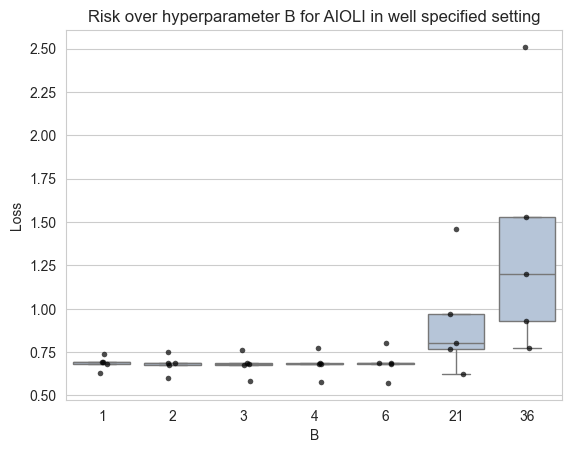

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


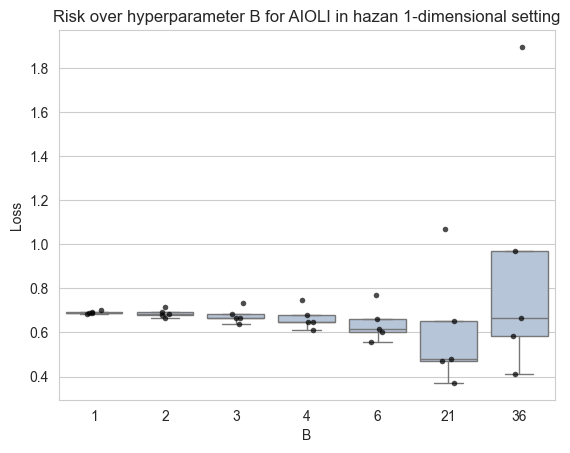

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.948


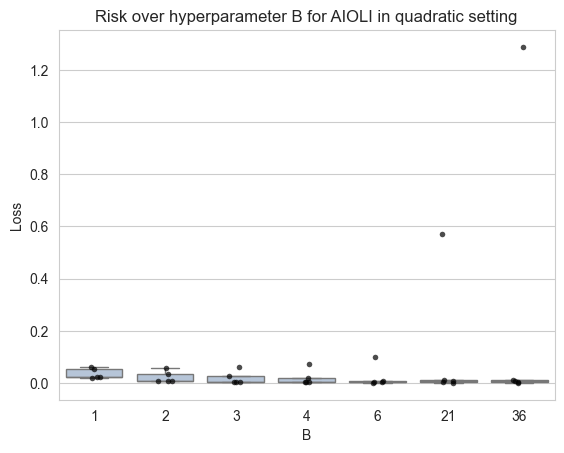

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


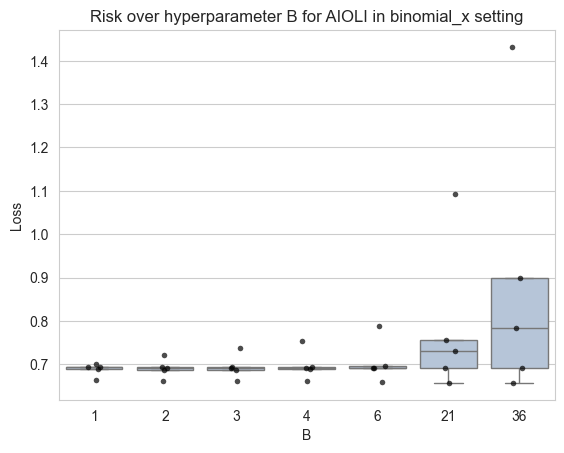

In [1177]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509


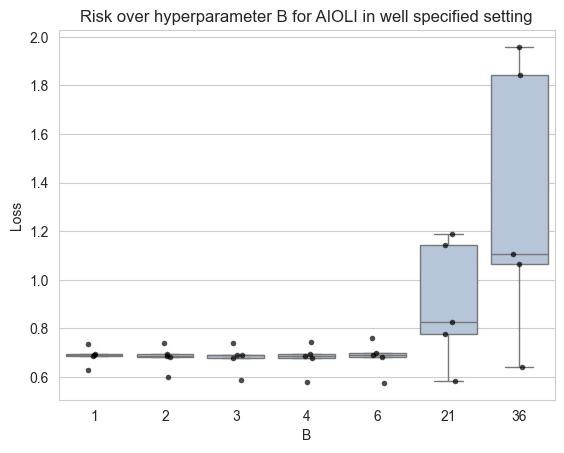

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


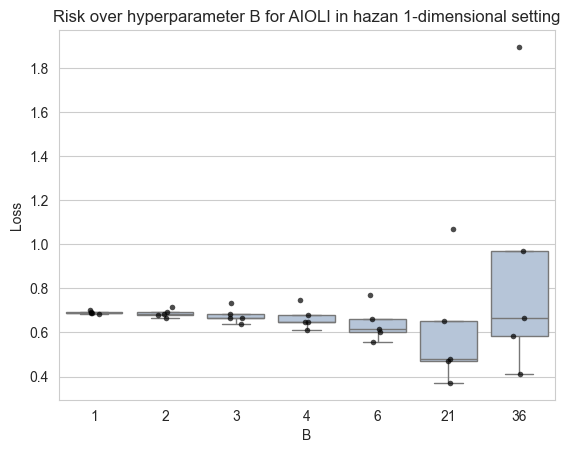

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


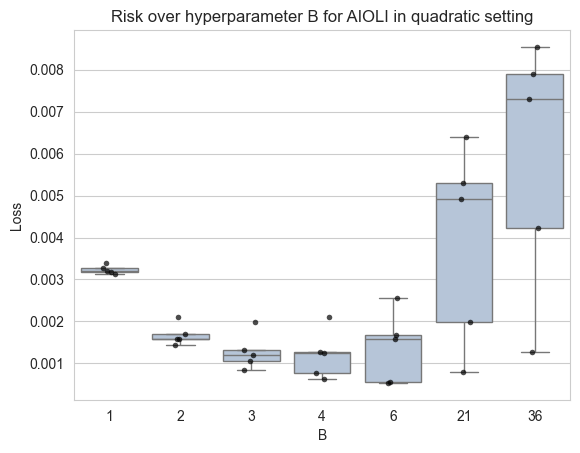

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


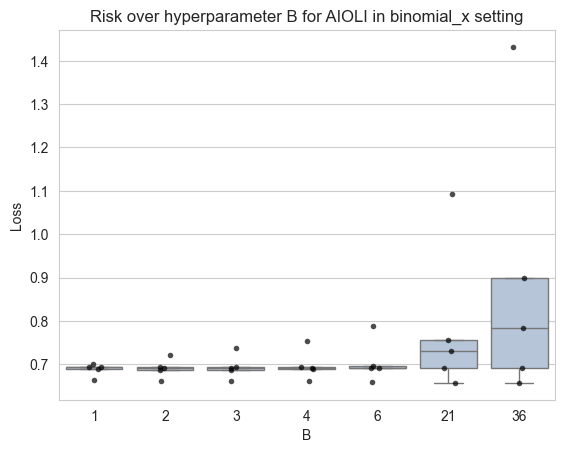

In [1178]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.927
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94


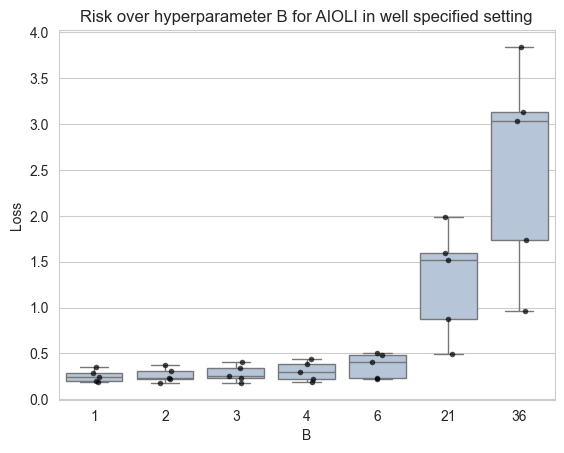

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


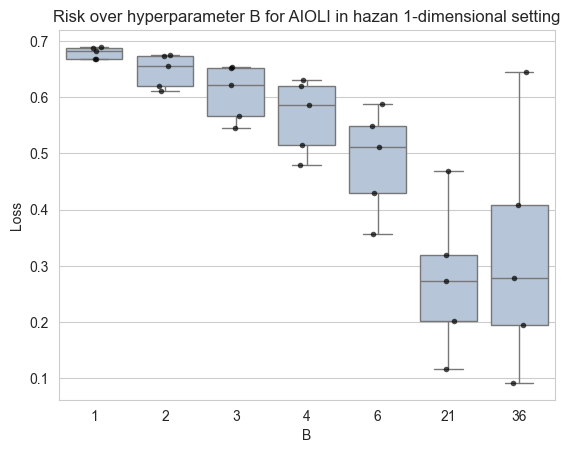

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


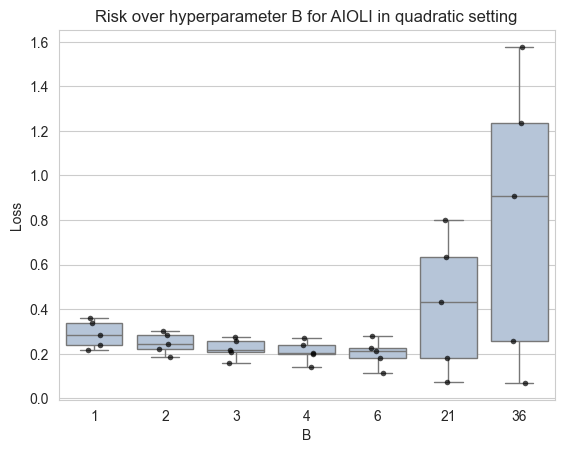

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


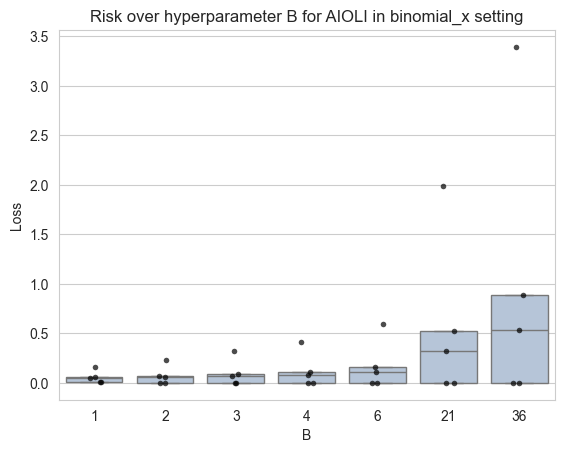

In [1179]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


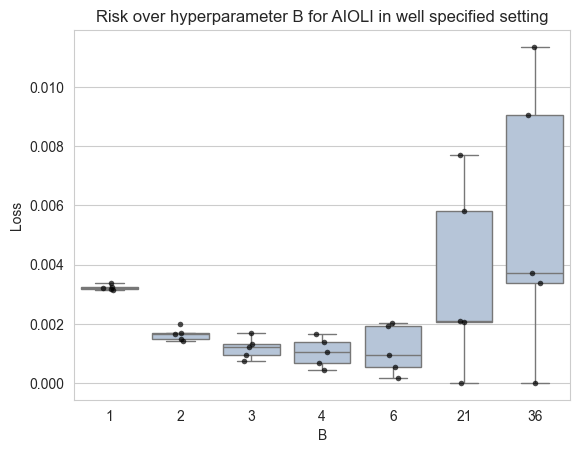

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


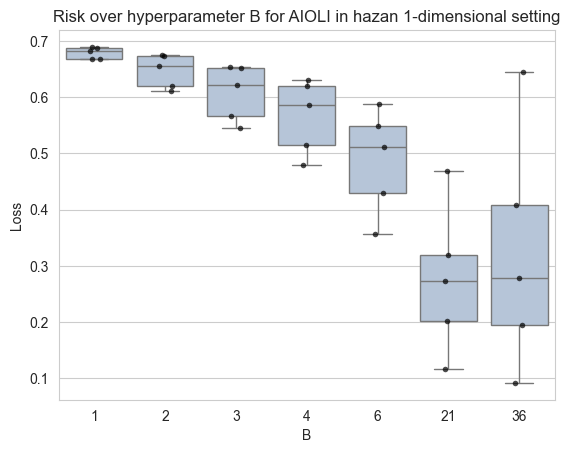

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.037
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038


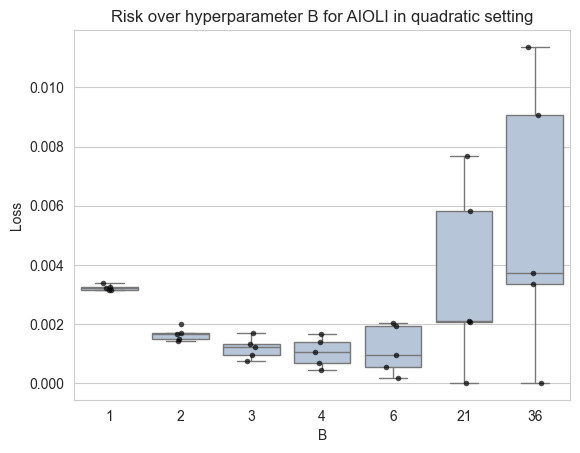

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


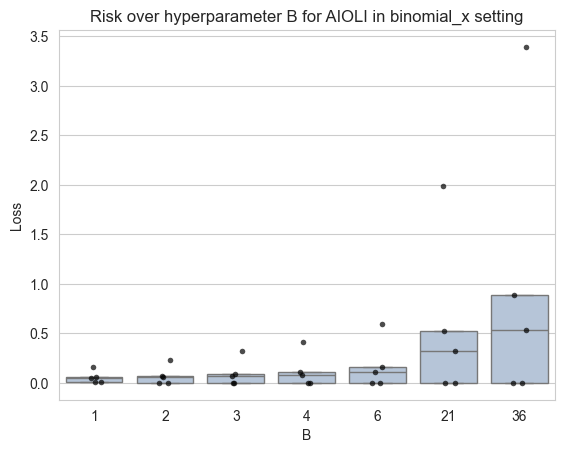

In [1180]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### AIOLI "X"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511


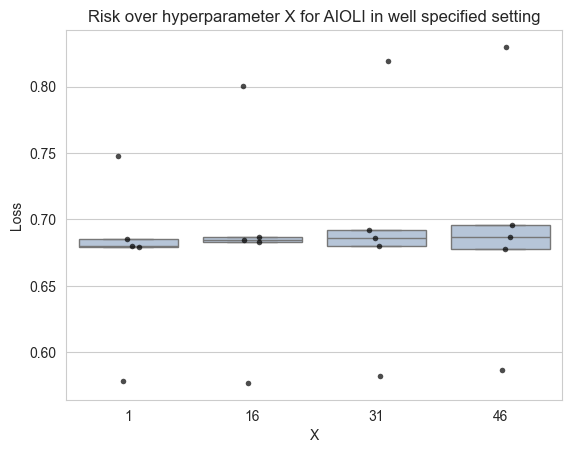

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


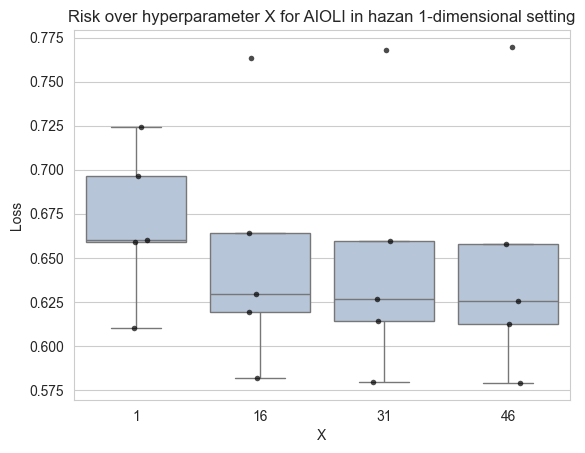

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.948


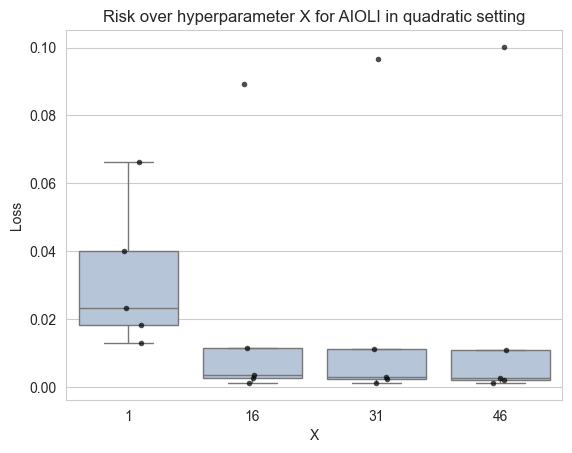

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


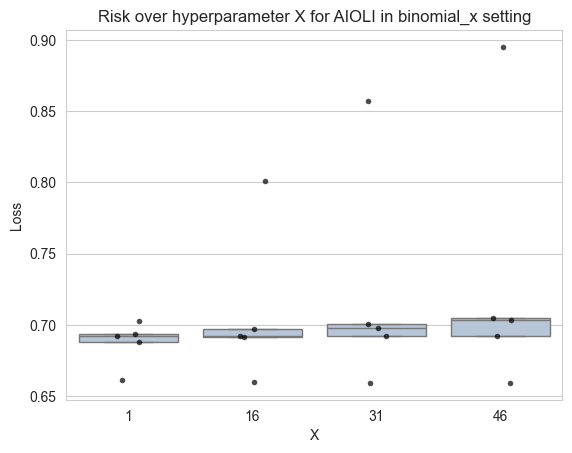

In [1181]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509


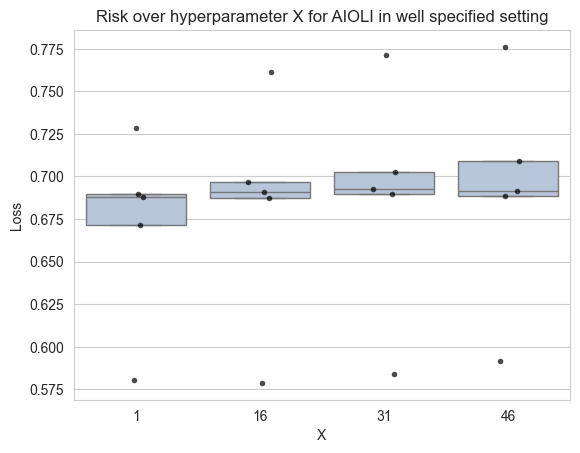

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


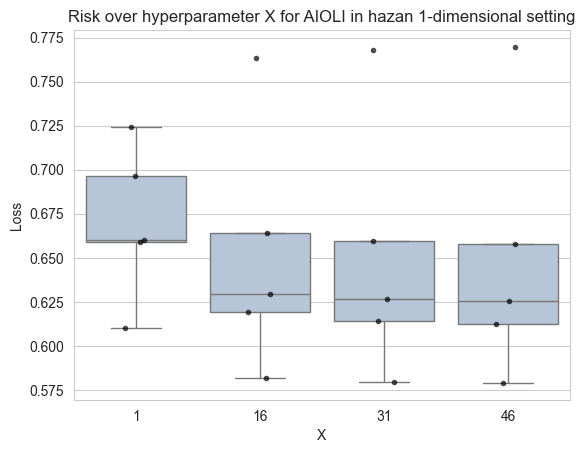

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


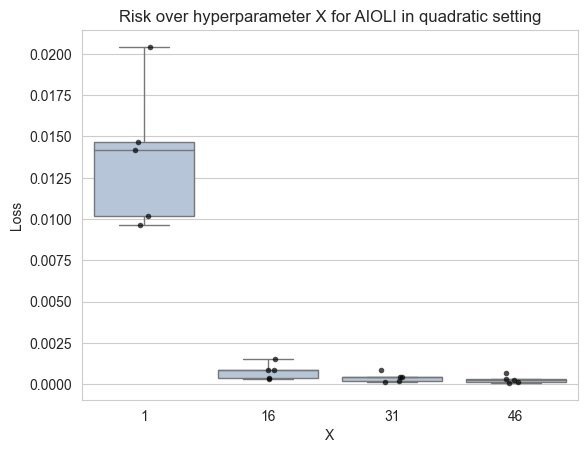

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


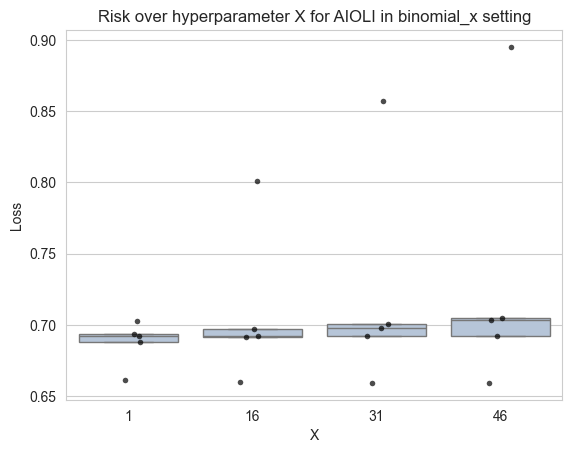

In [1182]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.927
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94


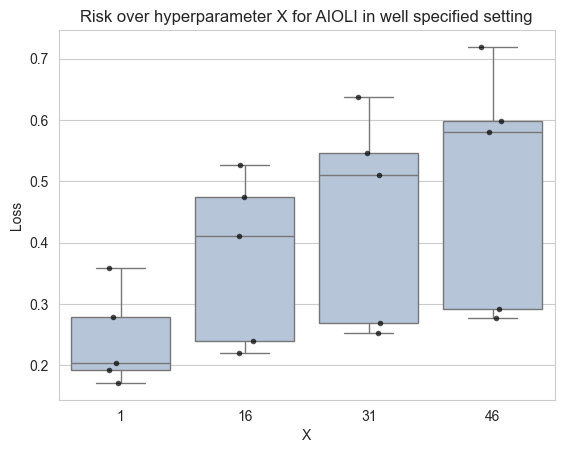

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


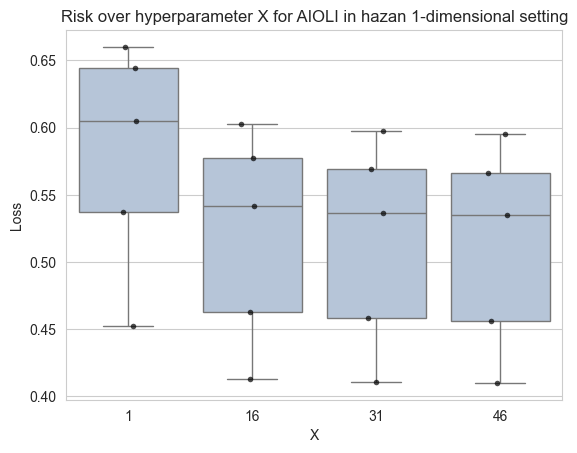

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


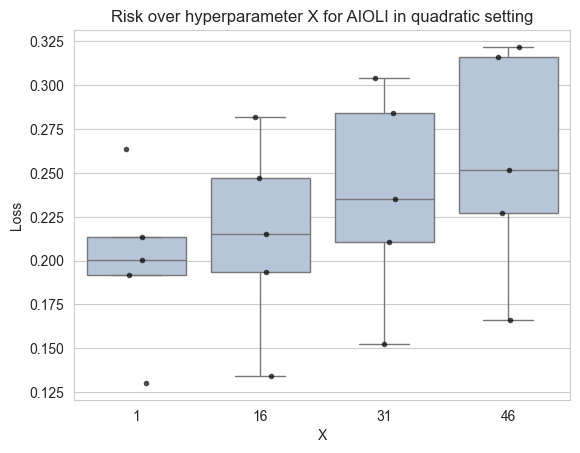

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


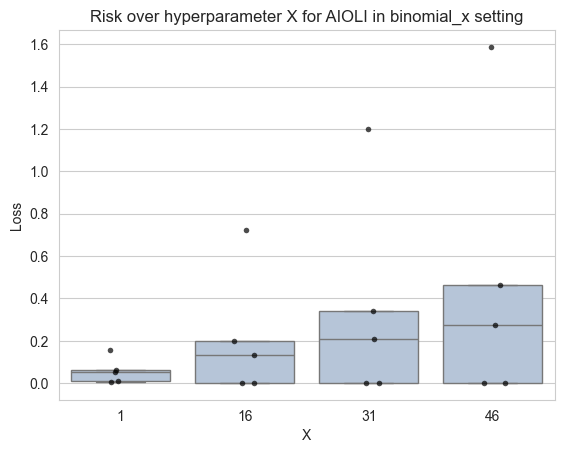

In [1183]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


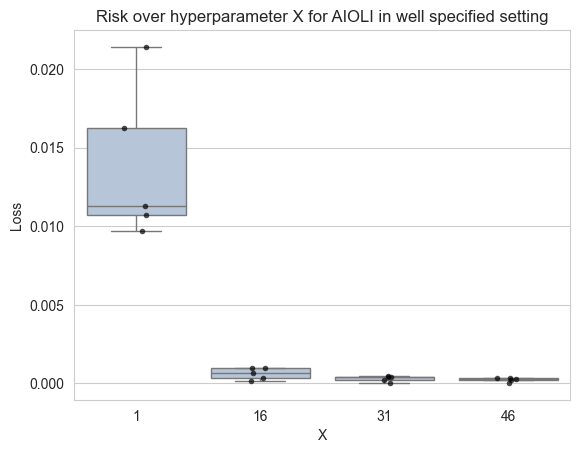

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


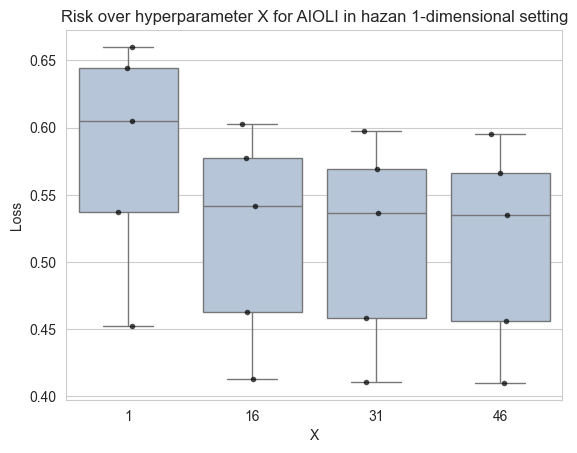

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.037
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038


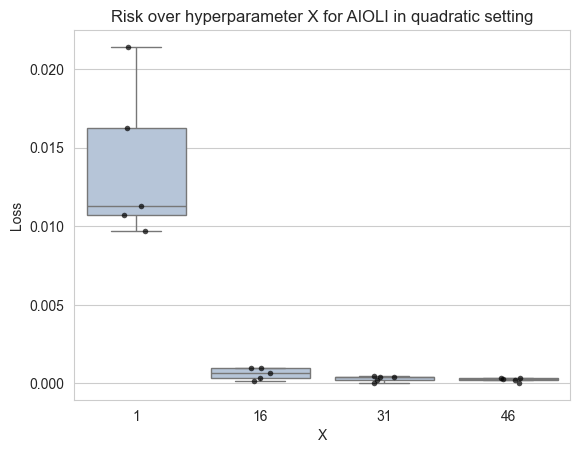

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


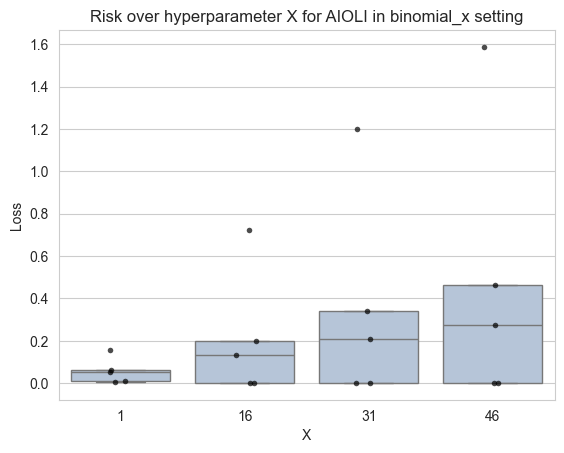

In [1184]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### Ada Grad "B"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511


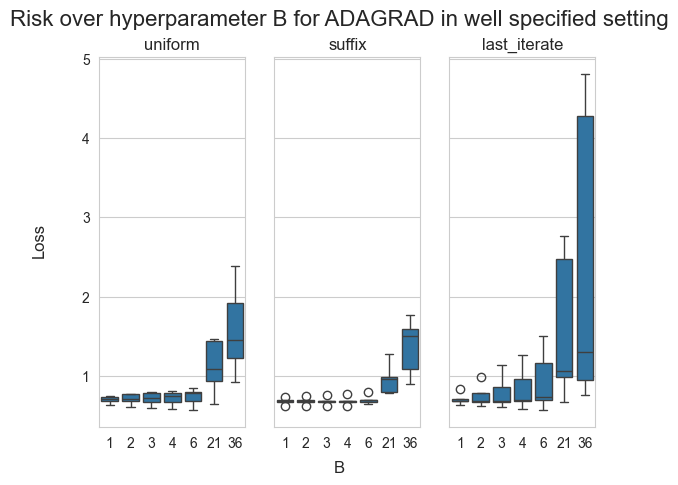

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


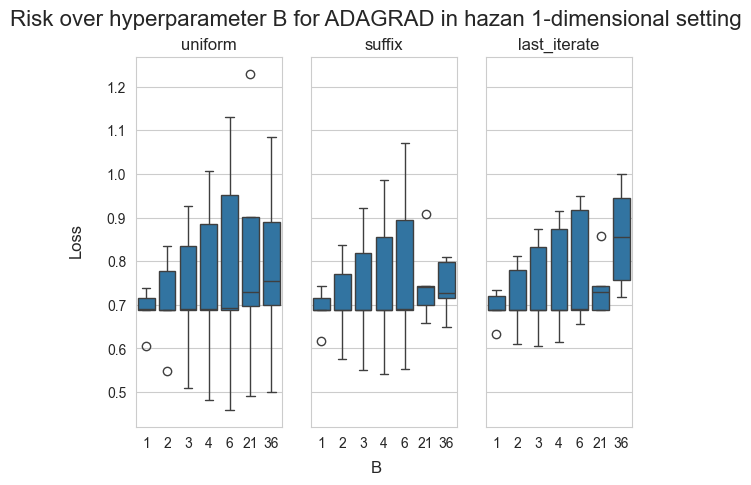

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.948


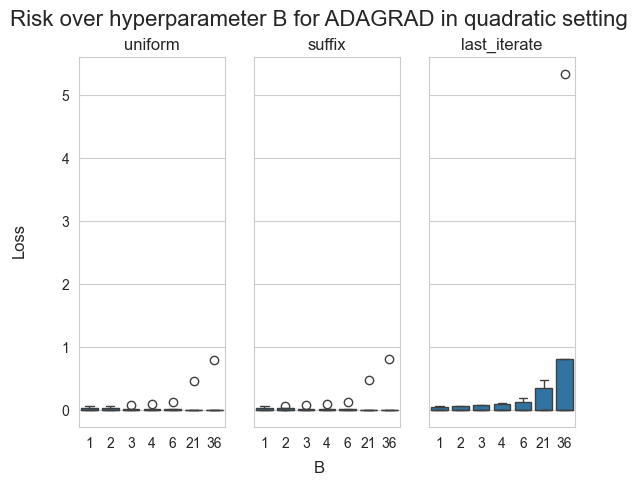

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


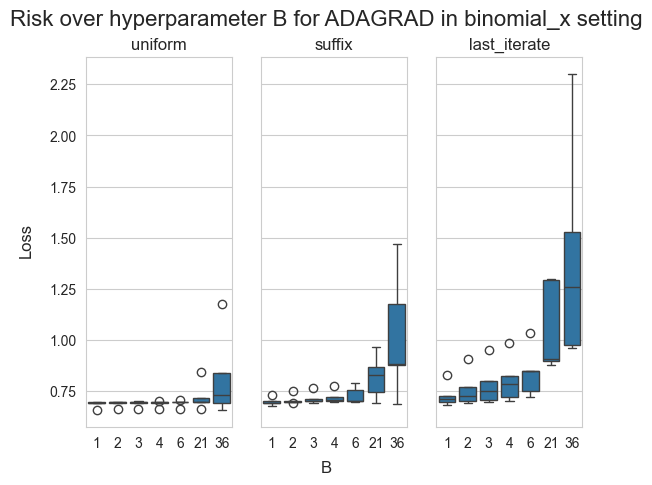

In [1185]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509


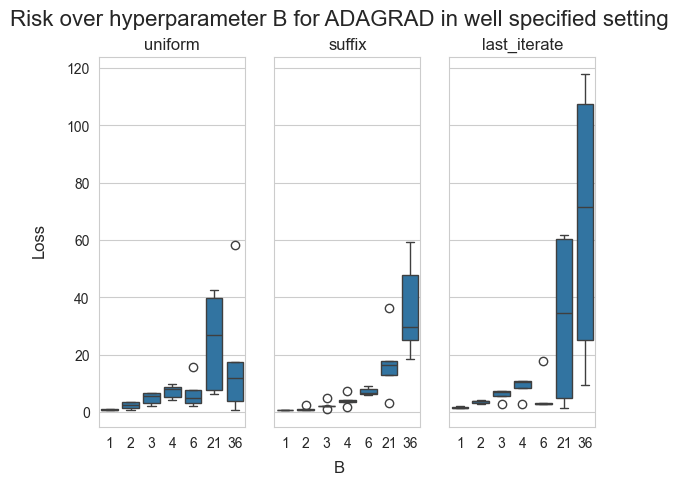

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


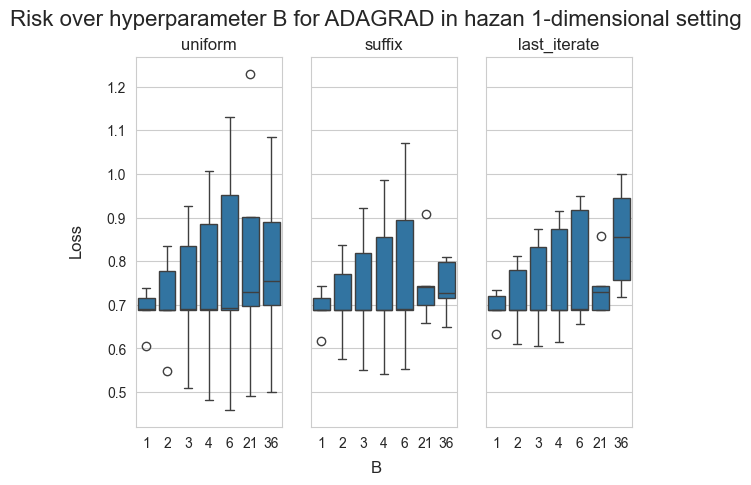

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


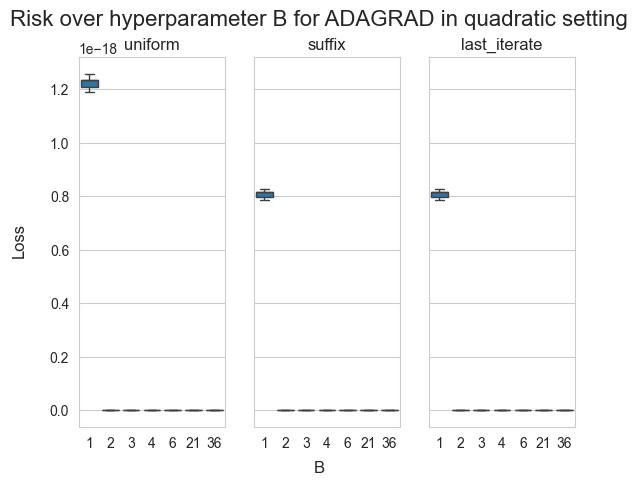

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


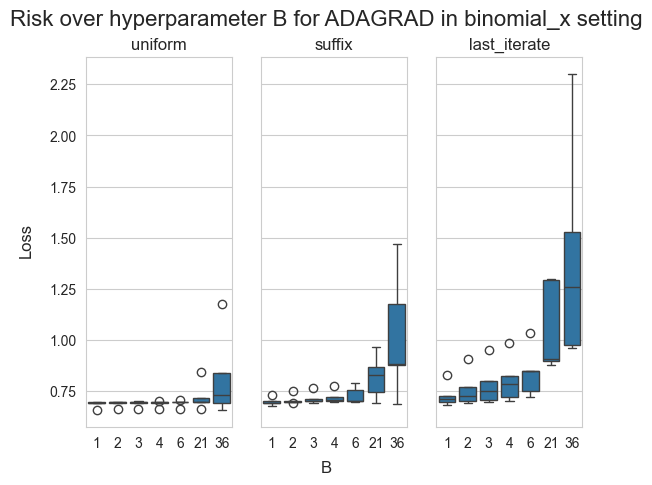

In [1186]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.927
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94


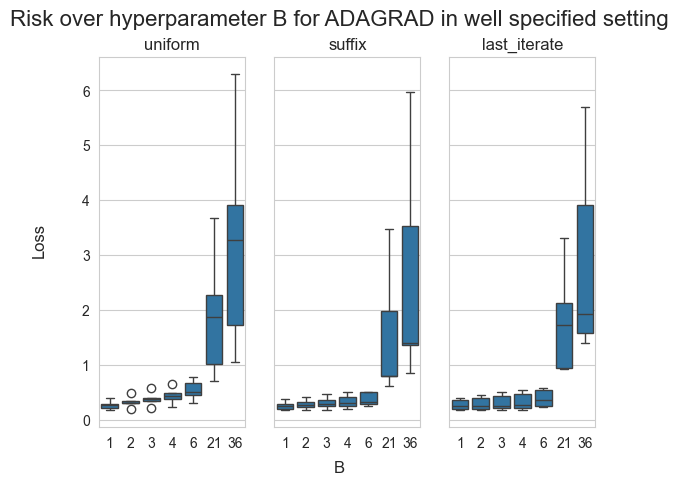

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


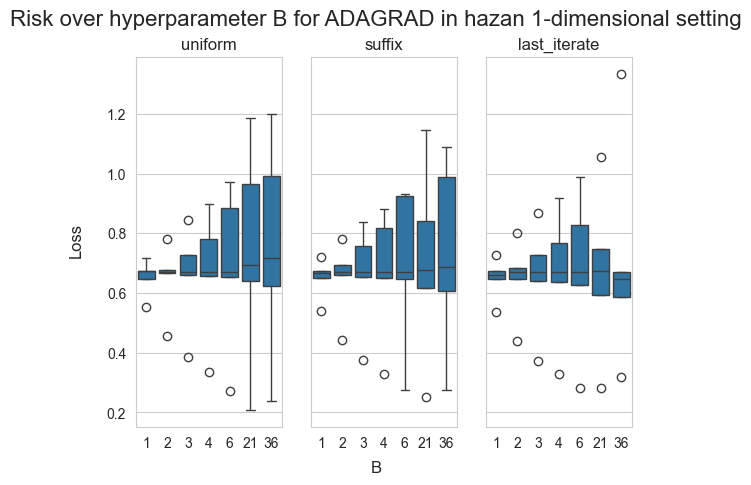

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


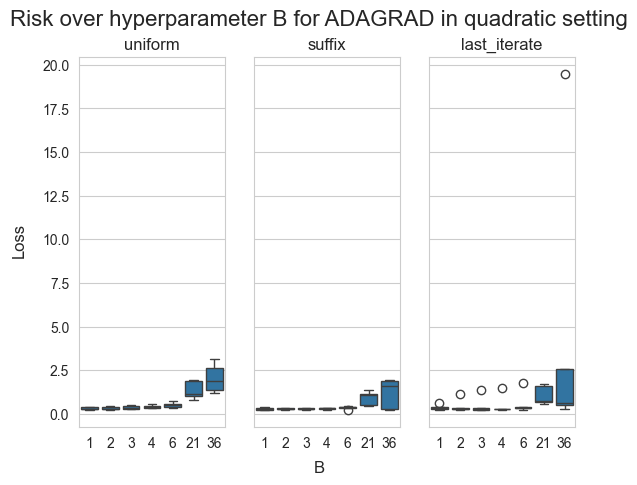

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


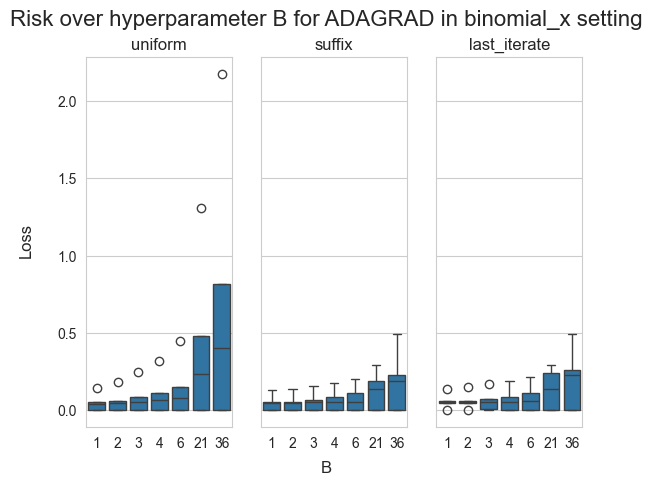

In [1187]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


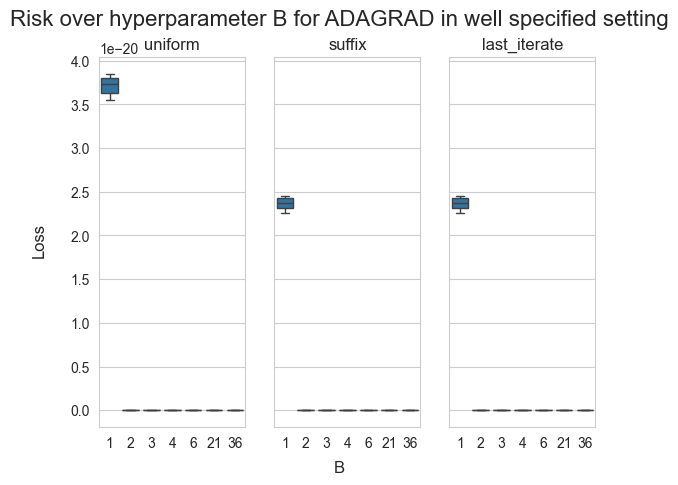

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


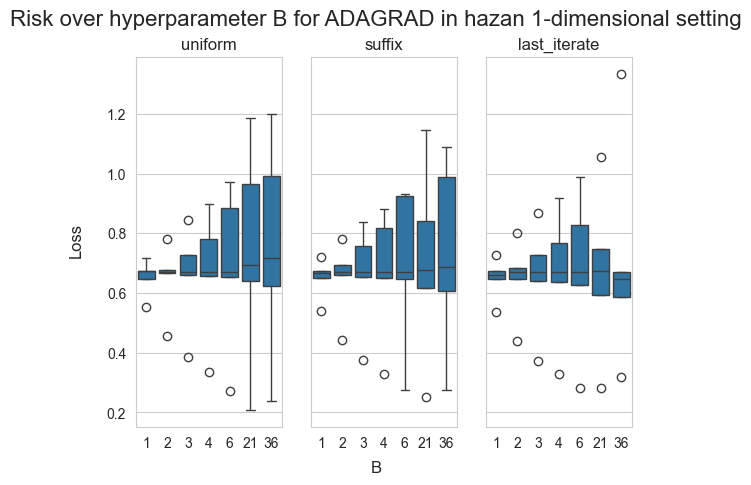

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.037
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038


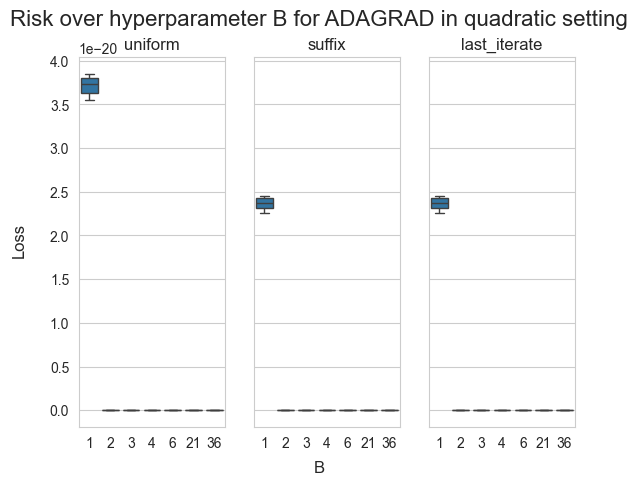

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


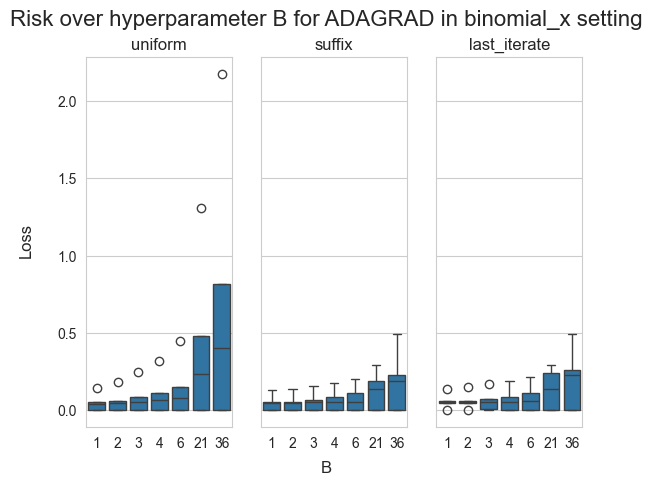

In [1188]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### SMOTE "S"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511


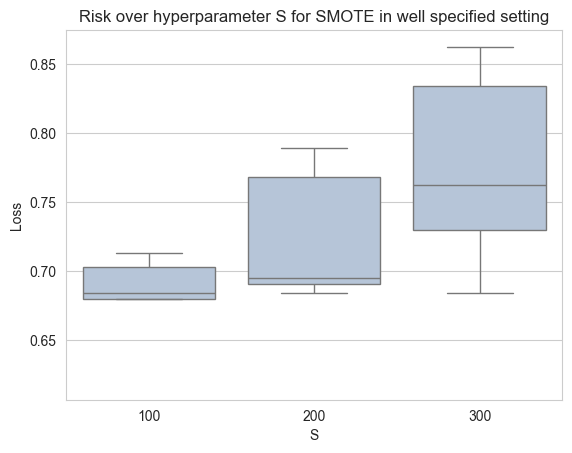

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


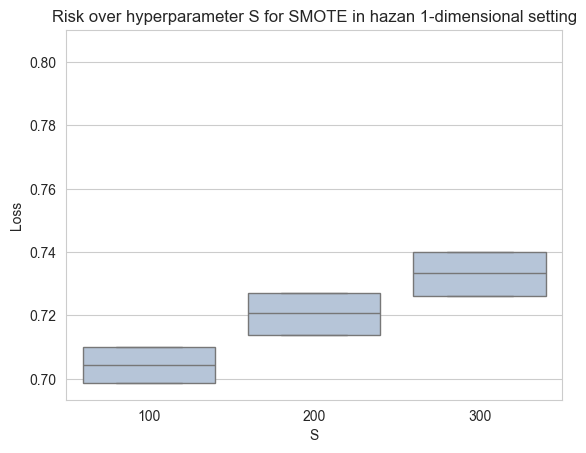

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression w

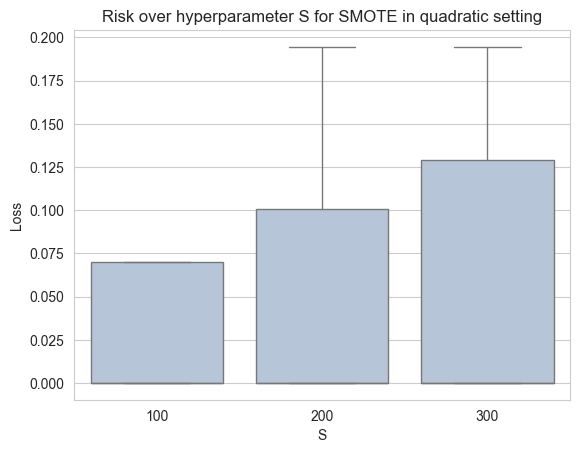

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


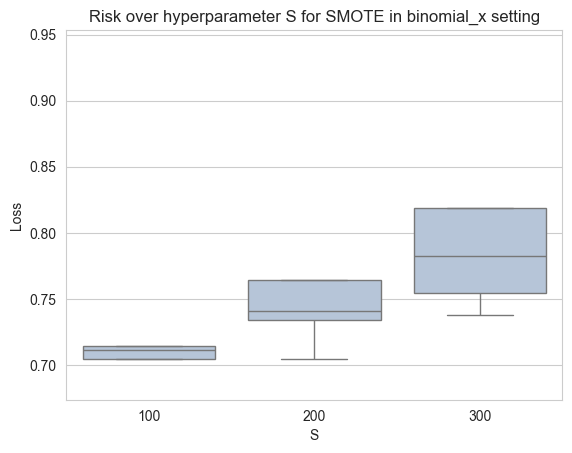

In [1189]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509


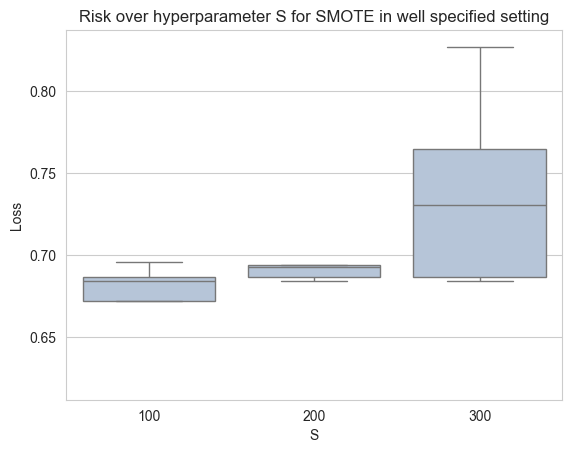

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


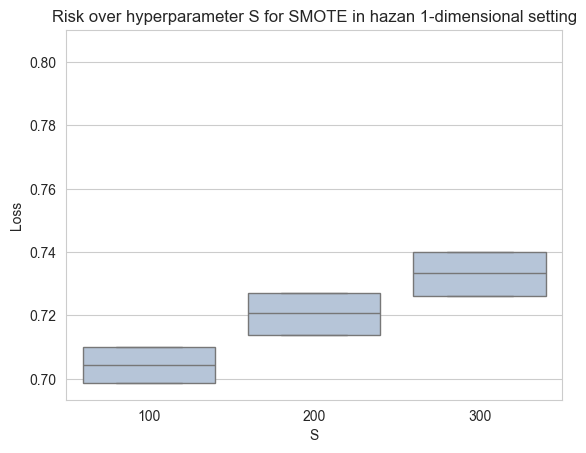

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadrat

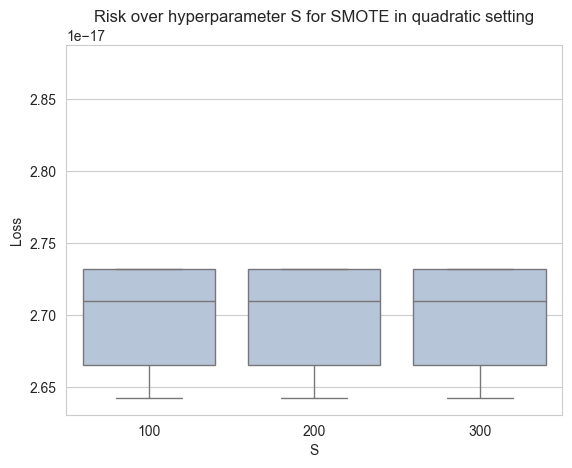

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


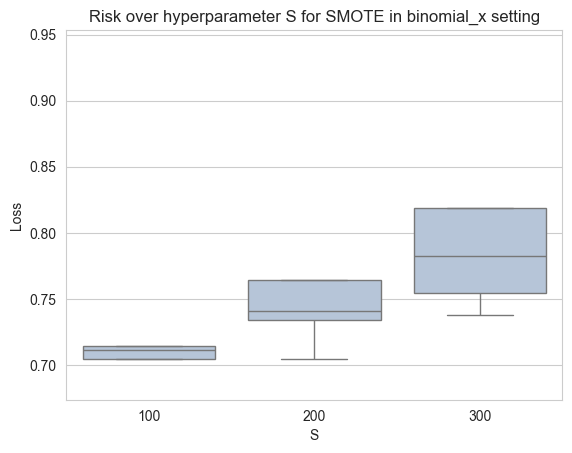

In [1190]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.017
100 (training) samples were generated in the well specified balanced setting. Using 3 variab

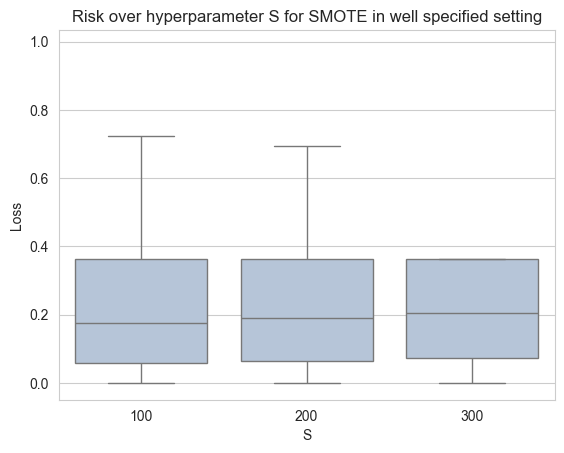

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


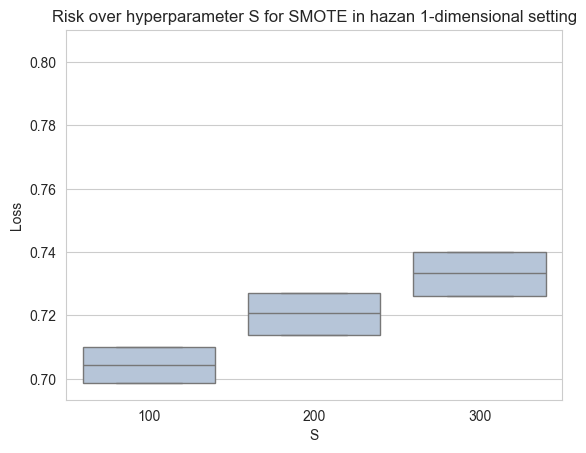

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the q

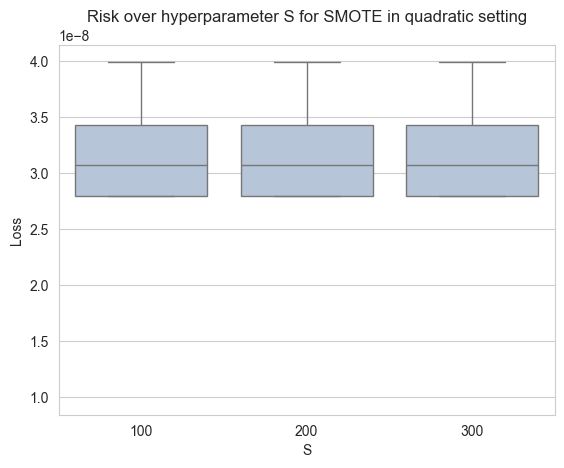

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


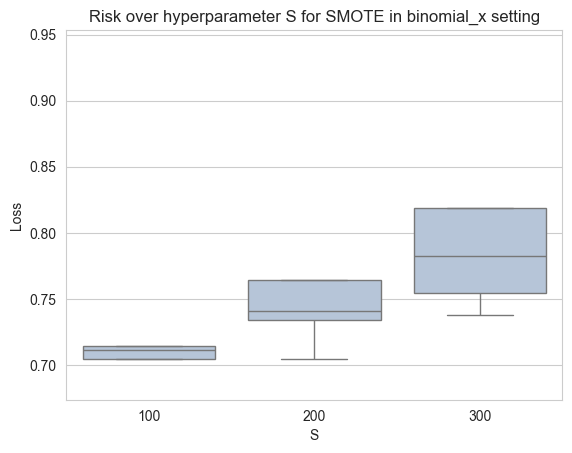

In [1191]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_unbalanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.012
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
100 (training) samples were generated in the well specified balanced setting. Using 3 variab

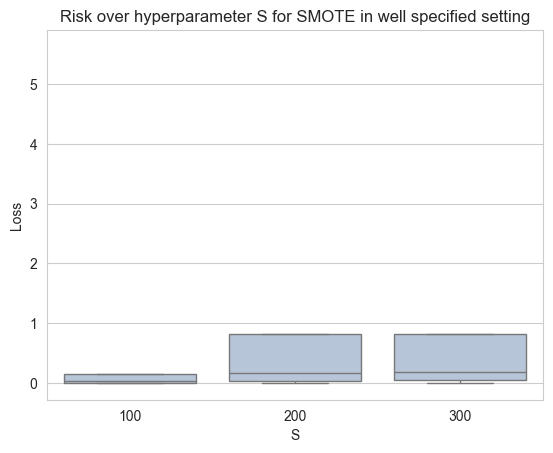

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


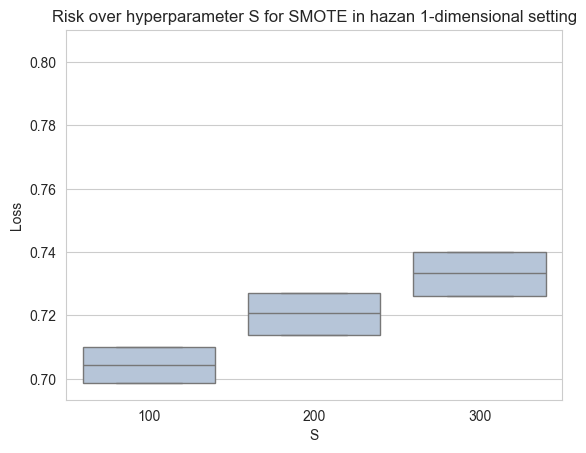

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadrat

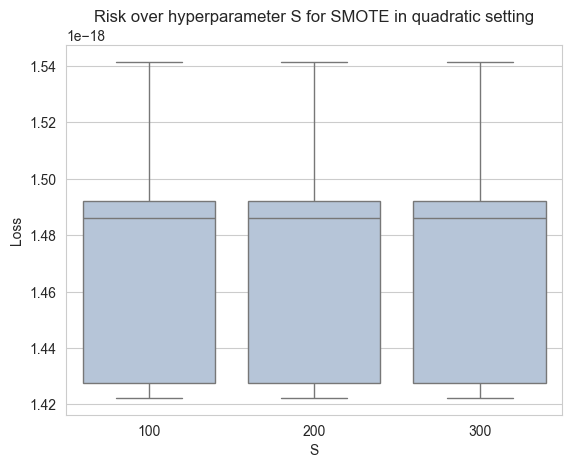

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


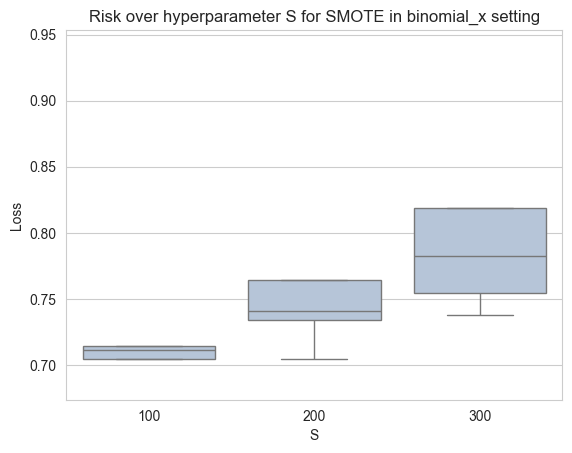

In [1192]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_unbalanced_2)

### SMOTE "k"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493
100 (training) samples were generate

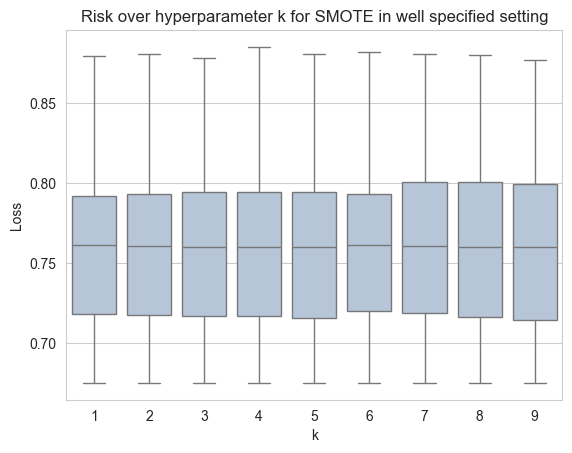

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting de

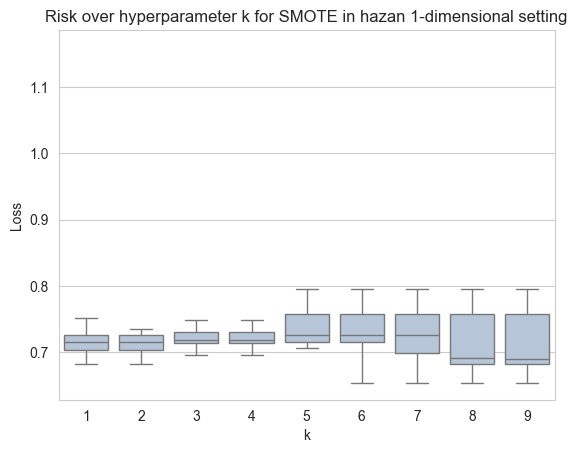

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (train

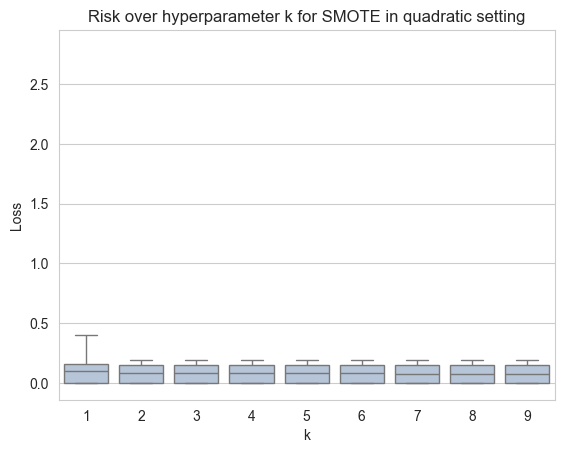

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

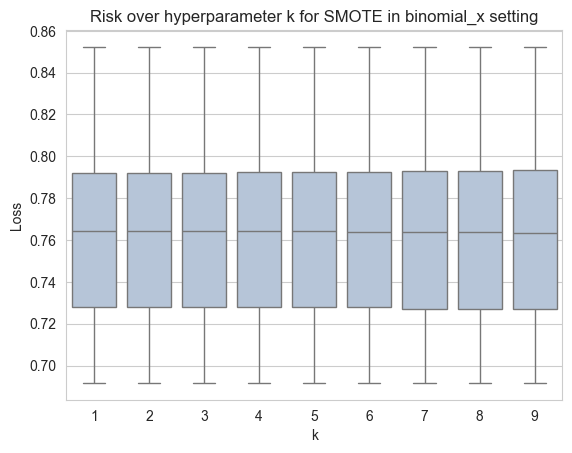

In [1193]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_balanced_1, n_runs = 20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P

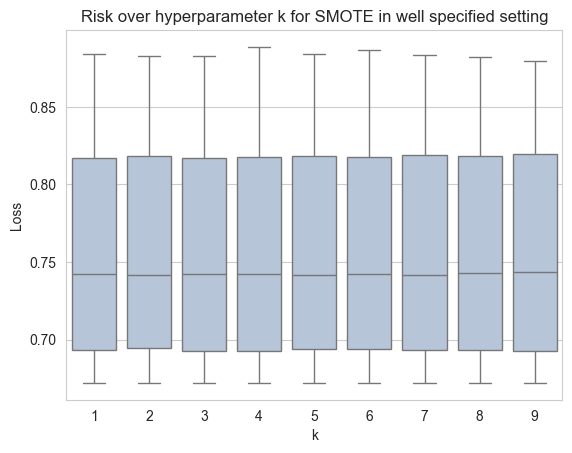

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting de

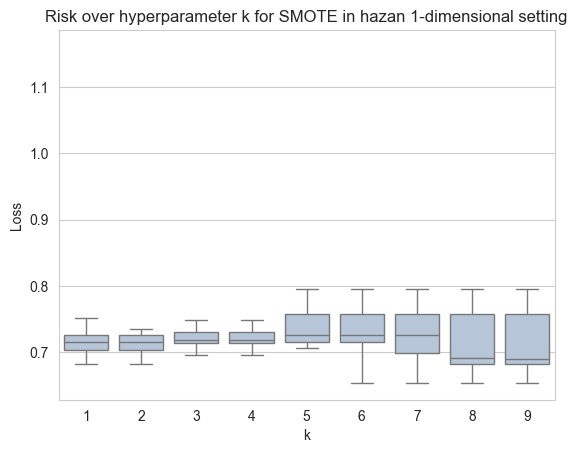

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression w

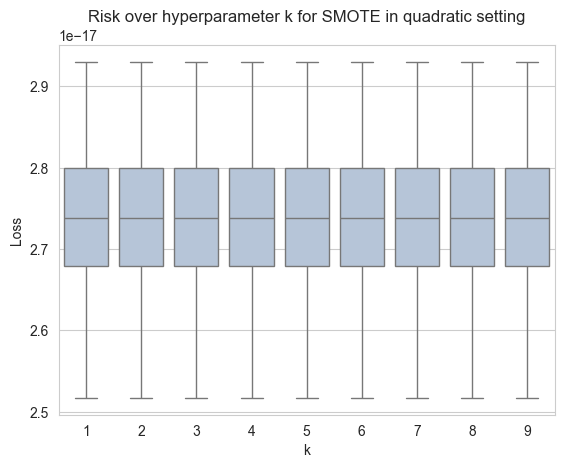

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

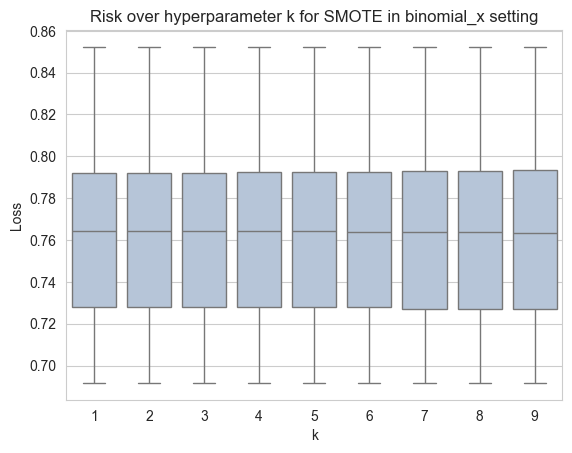

In [1194]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_balanced_2, n_runs = 20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples


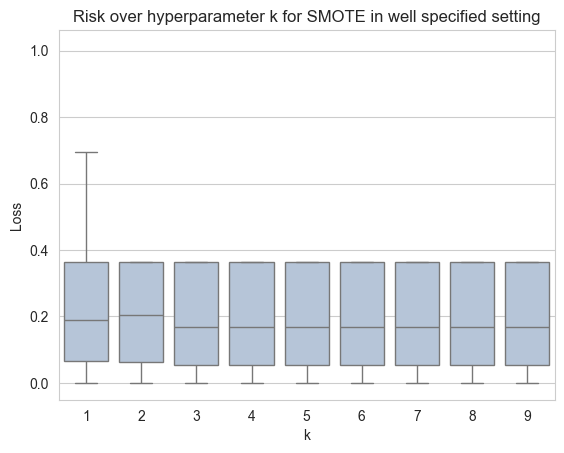

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting de

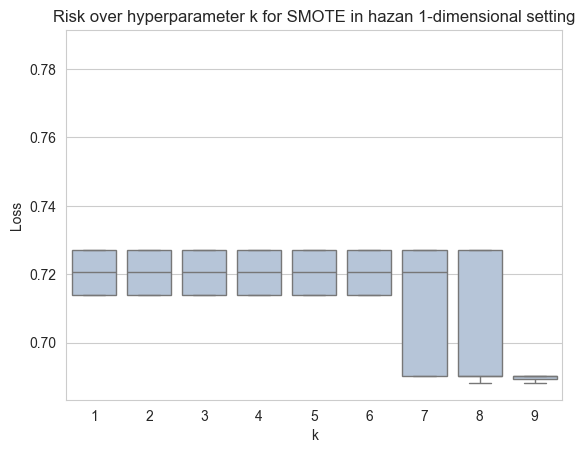

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regressi

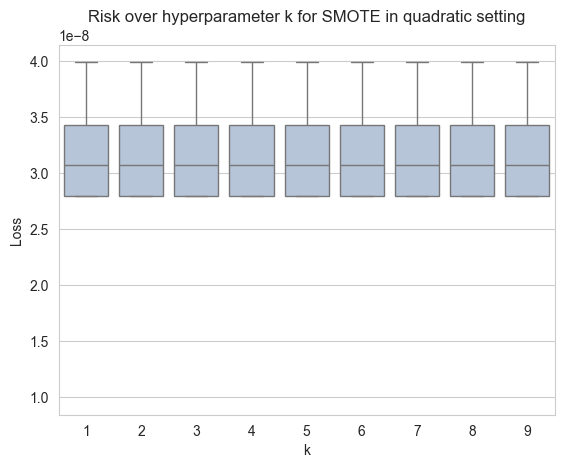

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


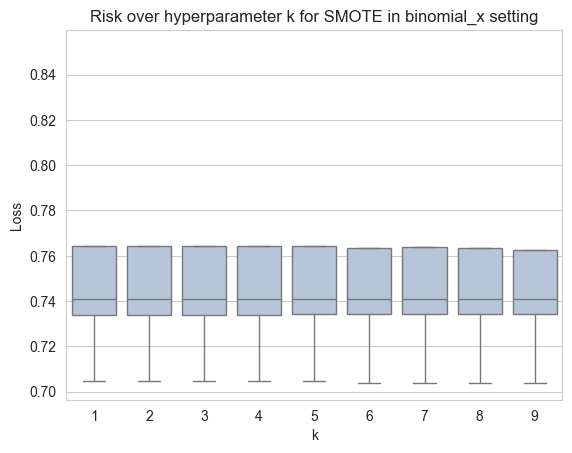

In [1195]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_unbalanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.012
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples


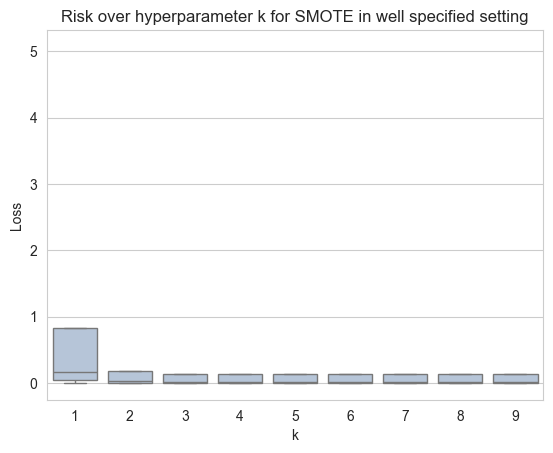

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of trianing samples
k must be smaller than the number of trianing samples
100 (training) samples were generated using the 1-dimensional setting de

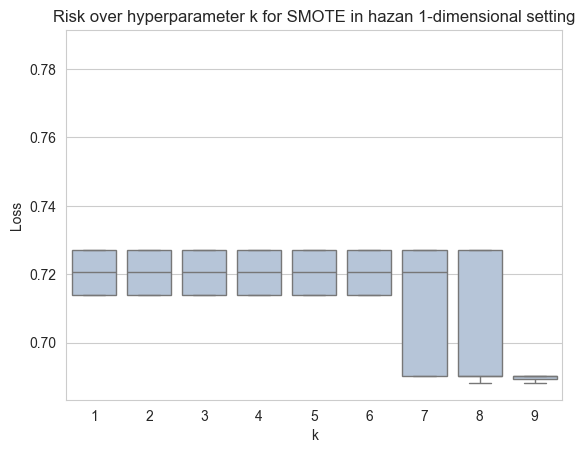

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression w

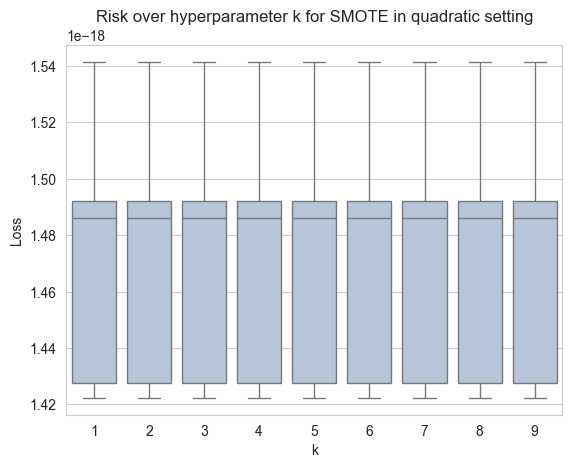

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


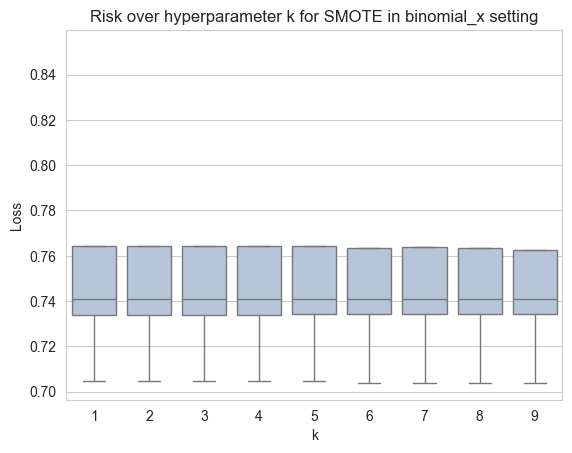

In [1196]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_unbalanced_2)

# Functions for simulations

## Data class for specifying simulation configuration

In [822]:
default_X = 1
default_B_Adagrad = 1.5
@dataclass
class SimulationConfig:
    sim_betas: list =  None,
    # Default is well specified
    sim_setting: str =  "well specified"
    sim_balanced: bool = True
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    # betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    # x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    test_ratio: float = default_test_size
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"
    X_hazan: int = 1

## Function to run simulations and get results

In [823]:
def run_simulation(cfg: SimulationConfig = None, B_hazan = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    minimize_method = cfg.minimize_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    X_hazan = cfg.X_hazan
    sim_betas = cfg.sim_betas

    test_set_results = []
    time_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             X_hazan = X_hazan,
                                                             betas = sim_betas,
                                                            B_hazan = B_hazan)

        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()

        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        def time_it(fn):
            """Runs fn(), returns (result, elapsed_seconds)."""
            t0 = datetime.datetime.now()
            result = fn()
            return result, (datetime.datetime.now() - t0).total_seconds()

        # ── Fit ──────────────────────────────────────────────────────────────
        ogd,           t_ogd_fit        = time_it(lambda: online_gd(data_y=y_train, data_x=x_train))
        adagrad,       t_adagrad_fit    = time_it(lambda: online_AdaGrad(data_y=y_train, data_x=x_train, B_vector=np.repeat(default_B_Adagrad, d)))
        aioli_model                     = AIOLI()
        ai,            t_aioli_fit      = time_it(lambda: aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=np.log(n), minimize_method=minimize_method))
        classic_LR,    t_clr_fit        = time_it(lambda: classic_logistic_regression(data_x=x_train, data_y=y_train))
        ridge_LR,      t_ridge_fit      = time_it(lambda: ridge_logistic_regression(data_x=x_train, data_y=y_train))
        lasso_LR,      t_lasso_fit      = time_it(lambda: lasso_logistic_regression(data_x=x_train, data_y=y_train))
        smp,           t_smp_fit        = time_it(lambda: sample_minmax_predictor(x_train, y_train))
        ridge_smp,     t_ridge_smp_fit  = time_it(lambda: ridge_sample_minmax_predictor(x_train, y_train))
        classic_LR_smote, t_smote_fit   = time_it(lambda: classic_logistic_regression(data_x=smote_x, data_y=smote_y))

        # ── OTB averaging (counts toward OGD / AdaGrad time) ─────────────────
        OGD_OTB_uniform, t_ogd_u   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "uniform"))
        OGD_OTB_Suffix,  t_ogd_s   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "suffix_averaging"))
        OGD_OTB_lastit,  t_ogd_l   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "last_iterate"))

        adagrad_OTB_uniform, t_ada_u = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "uniform"))
        adagrad_OTB_Suffix,  t_ada_s = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "suffix_averaging"))
        adagrad_OTB_lastit,  t_ada_l = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "last_iterate"))

        # ── Loss on test set ──────────────────────────────────────────────────
        loss_OGD_uniform_test,  t_ogd_u_loss  = time_it(lambda: log_loss(OGD_OTB_uniform, x_test, y_test))
        loss_OGD_Suffix_test,   t_ogd_s_loss  = time_it(lambda: log_loss(OGD_OTB_Suffix,  x_test, y_test))
        loss_OGD_lastit_test,   t_ogd_l_loss  = time_it(lambda: log_loss(OGD_OTB_lastit,  x_test, y_test))

        loss_adagrad_uniform_test, t_ada_u_loss = time_it(lambda: log_loss(adagrad_OTB_uniform, x_test, y_test))
        loss_adagrad_Suffix_test,  t_ada_s_loss = time_it(lambda: log_loss(adagrad_OTB_Suffix,  x_test, y_test))
        loss_adagrad_lastit_test,  t_ada_l_loss = time_it(lambda: log_loss(adagrad_OTB_lastit,  x_test, y_test))

        loss_AIOLI_uniform_test, t_aioli_u_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"])
        loss_AIOLI_Suffix_test,  t_aioli_s_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"])
        loss_AIOLI_lastit_test,  t_aioli_l_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"])

        loss_LR_test,       t_clr_loss       = time_it(lambda: log_loss(classic_LR["Batch_estimate"],       x_test, y_test))
        loss_LR_smote_test, t_smote_loss     = time_it(lambda: log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test))
        loss_LR_Ridge_test, t_ridge_loss     = time_it(lambda: log_loss(ridge_LR["Batch_estimate"],         x_test, y_test))
        loss_LR_Lasso_test, t_lasso_loss     = time_it(lambda: log_loss(lasso_LR["Batch_estimate"],         x_test, y_test))

        smp_result,       t_smp_loss      = time_it(lambda: smp.get_new_loss(x_test, y_test))
        ridge_smp_result, t_ridge_smp_loss = time_it(lambda: ridge_smp.get_new_loss(x_test, y_test))

        # ── Collate results ───────────────────────────────────────────────────
        algorithms_test = {
            "Classical_LR":         {"loss": loss_LR_test,              "time_fit": t_clr_fit,       "time_loss": t_clr_loss},
            "Classical_LR_SMOTE":   {"loss": loss_LR_smote_test,        "time_fit": t_smote_fit,     "time_loss": t_smote_loss},
            "Ridge_LR":             {"loss": loss_LR_Ridge_test,         "time_fit": t_ridge_fit,     "time_loss": t_ridge_loss},
            "Lasso_LR":             {"loss": loss_LR_Lasso_test,         "time_fit": t_lasso_fit,     "time_loss": t_lasso_loss},
            "OGD_uniform":          {"loss": loss_OGD_uniform_test,      "time_fit": t_ogd_fit,       "time_loss": t_ogd_u + t_ogd_u_loss},
            "OGD_Suffix":           {"loss": loss_OGD_Suffix_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_s + t_ogd_s_loss},
            "OGD_Last_iterate":     {"loss": loss_OGD_lastit_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_l + t_ogd_l_loss},
            "AdaGrad_uniform":      {"loss": loss_adagrad_uniform_test,  "time_fit": t_adagrad_fit,   "time_loss": t_ada_u + t_ada_u_loss},
            "AdaGrad_Suffix":       {"loss": loss_adagrad_Suffix_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_s + t_ada_s_loss},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_l + t_ada_l_loss},
            "AIOLI_uniform":        {"loss": loss_AIOLI_uniform_test,    "time_fit": t_aioli_fit,     "time_loss": t_aioli_u_loss},
            "AIOLI_Suffix":         {"loss": loss_AIOLI_Suffix_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_s_loss},
            "AIOLI_lastit":         {"loss": loss_AIOLI_lastit_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_l_loss},
            "SMP":                  {"loss": smp_result["loss"],         "time_fit": t_smp_fit,       "time_loss": t_smp_loss},
            "Ridge_SMP":            {"loss": ridge_smp_result["loss"],   "time_fit": t_ridge_smp_fit, "time_loss": t_ridge_smp_loss},
        }

        for name, metrics in algorithms_test.items():
            row = {"run": i + 1, "algorithm": name, **metrics}
            row["time_total"] = row["time_fit"] + row["time_loss"]
            test_set_results.append(row)

        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    total_time = (endtime - start_time).total_seconds()

    results_df = pd.DataFrame(test_set_results)

    return {
        "test_results":    results_df[["run", "algorithm", "loss"]],
        "time_results":    results_df[["run", "algorithm", "time_fit", "time_loss", "time_total"]],
        "y_counts_train":  pd.DataFrame(y_counts),
        "y_train_df":      pd.DataFrame(all_y_trains),
        "y_test_df":       pd.DataFrame(all_y_tests),
        "total_time":      total_time,
    }

## Simulations changing n

In [824]:
def simulations_changing_n(n_values: list, base_config: SimulationConfig, filename, B_hazan = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run simulations for multiple sample sizes and aggregate results.

    Args:
        n_values: List of sample sizes to simulate
        base_config: Base SimulationConfig object (will copy and modify n for each run)

    Returns:
        summary_df: DataFrame with columns: n, algorithm, avg_loss, std_loss, num_runs
        raw_df: DataFrame with columns: n, algorithm, loss (one row per run)
    """
    all_summaries = []
    all_raw = []
    total_time = 0

    for n in n_values:
        print(f"="*50)
        print(f"Running simulations for n = {n}\n")
        print(f"="*50)
        # Create a copy of the config with the new n value
        config = base_config
        config.n = n  # Modify n in place

        # Run the simulation
        results_dict = run_simulation(config, B_hazan = B_hazan)

        # Extract test results
        test_results_df = results_dict["test_results"]
        total_time += results_dict["total_time"]

        # Add n column to raw data
        raw_with_n = test_results_df.copy()
        raw_with_n['n'] = n
        all_raw.append(raw_with_n)

        # Calculate average loss and standard deviation for each algorithm
        summary = test_results_df.groupby('algorithm').agg({
            'loss': ['mean', 'std', 'count']
        }).reset_index()


        # Flatten column names
        summary.columns = ['algorithm', 'avg_loss', 'std_loss', 'num_runs']

        summary['se_loss'] = summary['std_loss'] / np.sqrt(summary['num_runs'])
        summary = summary.drop(columns=["std_loss"])

        # Add n value
        summary['n'] = n

        # Reorder columns
        summary = summary[['n', 'algorithm', 'avg_loss', 'se_loss', 'num_runs']]

        all_summaries.append(summary)

        print(f"Completed simulations for n = {n}")

        # Save to csv
        temp_summary_df = pd.concat(all_summaries, ignore_index=True)
        temp_summary_df.to_csv(f"{filename}.csv")

    # Combine all results
    summary_df = pd.concat(all_summaries, ignore_index=True)
    raw_df = pd.concat(all_raw, ignore_index=True)
    print(f"Total time: {total_time} seconds")
    return summary_df, raw_df

In [825]:
def plot_simulation_results(
    raw_data: pd.DataFrame,
    algorithms: list = None,
    figsize: tuple = (12, 8),
    title: str = 'Algorithm Performance vs Sample Size',
    xlabel: str = 'Sample Size (n)',
    ylabel: str = 'Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True
) -> plt.Figure:
    """
    Plot box plots of loss distributions per algorithm across different sample sizes.

    Args:
        raw_data: DataFrame with columns: algorithm, n, loss (one row per run)
        algorithms: List of algorithm names to plot (None = all)
        figsize: Figure size (width, height)
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        box_alpha: Transparency of box fill (0 = transparent, 1 = opaque)
        show_plot: Whether to display the plot

    Returns:
        None
    """
    # Filter algorithms if specified
    raw_plot = raw_data.copy()
    if algorithms is not None:
        raw_plot = raw_plot[raw_plot['algorithm'].isin(algorithms)]

    if raw_plot.empty:
        print("No data to plot.")
        return None

    # Ensure n is treated as a categorical axis so boxes are evenly spaced
    raw_plot["n"] = raw_plot["n"].astype(str)

    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_plot,
        x="n",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.legend(title="Algorithm", loc='best', prop={'size': 10})
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if show_plot:
        plt.show()

    return None

In [826]:
def get_variable_name(var, namespace=None):
    if namespace is None:
        namespace = globals()
    for name, value in namespace.items():
        if value is var:
            return name
    return None

## Function for printing results

In [917]:
def print_results(results, n=default_n, plot=False, selected_algorithms=None, runs=default_runs, box_alpha=0.6, summary_object = False):
    # Save to csv
    df_name = get_variable_name(results)
    results["test_results"].to_csv(f"{df_name}.csv")

    # ── Loss summary ──────────────────────────────────────────────────────────
    summary_test_average = results["test_results"].groupby("algorithm")[["loss"]].mean()
    summary_test_se      = results["test_results"].groupby("algorithm")[["loss"]].std() / np.sqrt(runs)

    summary = pd.concat([summary_test_average, summary_test_se], axis=1)
    summary.columns = ["Average_Loss", "SE_Loss"]

    # ── Time summary ──────────────────────────────────────────────────────────
    time_avg = results["time_results"].groupby("algorithm")[["time_fit", "time_loss", "time_total"]].mean()
    time_se  = results["time_results"].groupby("algorithm")[["time_total"]].std() / np.sqrt(runs)

    time_summary = pd.concat([time_avg, time_se], axis=1)
    time_summary.columns = [
        "Avg_Time_Fit", "Avg_Time_Loss", "Avg_Time_Total", "SE_Time_Total"
    ]

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"Total time: {str(datetime.timedelta(seconds=results['total_time']))}")

    print("\n── Loss Results ──")
    display(summary)

    print("\n── Time Results (seconds) ──")
    display(time_summary)

    if not summary_object:
        return
    else:
        return summary

    # ── Boxplot ───────────────────────────────────────────────────────────────
    if not plot:
        return

    raw_data = results["test_results"].copy()
    if selected_algorithms is not None:
        raw_data = raw_data[raw_data["algorithm"].isin(selected_algorithms)]

    if raw_data.empty:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_data,
        x="algorithm",
        y="loss",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Aesthetics
    ax.set_xlabel("Algorithm", fontsize=12, fontweight="bold")
    ax.set_ylabel("Risk", fontsize=12, fontweight="bold")
    ax.set_title("Risk distribution across runs", fontsize=14, fontweight="bold")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()



## Plot results (Function for graphing loss and Y=1 counts over runs)

In [829]:
def plot_results(results, n = default_n, plot = False):
    test_results = results["test_results"]

    # Boxplots of y counts
    if plot:
        sns.boxplot(data=results["y_counts_train"][["count_1", "count_minus1"]])
        plt.title("Distribution of Y counts across runs")
        plt.ylim(-10, n)
        plt.show()
    else:
        pass

    # Distribution of y values
    print("Train set")
    print(results["y_train_df"].apply(pd.Series.value_counts))
    print("Test set")
    print(results["y_test_df"].apply(pd.Series.value_counts))

    # Line plot of Loss over rounds
    sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
    plt.show()


## Compare settings

In [831]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    x_labels: dict = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a box plot of loss
    per algorithm across runs.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        x_labels : dict, optional
            Mapping from setting key to display label on the x-axis.
            e.g. {"s1": "Well Specified", "s2": "High Dimensional"}
            If None, the setting keys are used as-is.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        box_alpha : float
            Transparency of the box fill (0 = transparent, 1 = opaque).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Remap setting keys to display labels if provided
    if x_labels is not None:
        combined_raw["setting"] = combined_raw["setting"].map(x_labels).fillna(combined_raw["setting"])

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(title="Algorithm", loc="best", prop={'size': 10})

    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

# Experiments

## Hazan setting

In [1036]:
hazan = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10
)

hazan_result = run_simulation(hazan)
print_results(hazan_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated us

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5964771036,0.0225941708
AIOLI_lastit,0.5906071409,0.0210860819
AIOLI_uniform,0.5718082808,0.0229947635
AdaGrad_Last_iterate,0.7562952367,0.0320879699
AdaGrad_Suffix,0.7587139108,0.0332013649
AdaGrad_uniform,0.7362285771,0.0249979148
Classical_LR,0.7834200539,0.0530786716
Classical_LR_SMOTE,0.7117610531,0.0202761150
Lasso_LR,0.7072489159,0.0170719818



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0795306000,8.7667843000,8.8463149000,1.1984806207
AIOLI_lastit,0.0795306000,7.6657134000,7.7452440000,1.0525860871
AIOLI_uniform,0.0795306000,7.4568134000,7.5363440000,0.8267806137
AdaGrad_Last_iterate,0.0017449000,0.0000130000,0.0017579000,0.0004147984
AdaGrad_Suffix,0.0017449000,0.0000209000,0.0017658000,0.0004169344
AdaGrad_uniform,0.0017449000,0.0000245000,0.0017694000,0.0004179170
Classical_LR,0.0053046000,0.0000258000,0.0053304000,0.0029747738
Classical_LR_SMOTE,0.0018628000,0.0000196000,0.0018824000,0.0004170200
Lasso_LR,0.0036249000,0.0007134000,0.0043383000,0.0014743729


In [837]:
hazan_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,1.1600614018
1,1,Classical_LR_SMOTE,0.8852520801
2,1,Ridge_LR,0.6731823489
3,1,Lasso_LR,0.8262324912
4,1,OGD_uniform,0.6834887022
...,...,...,...
145,10,AIOLI_uniform,0.6856214313
146,10,AIOLI_Suffix,0.6911336125
147,10,AIOLI_lastit,0.6336485945
148,10,SMP,0.6813405000


Train set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1.0000000000     99     98     95     96     95     98     94     96     95   
1.0000000000       1      2      5      4      5      2      6      4      5   

               run_10  
-1.0000000000      93  
1.0000000000        7  
Test set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1.0000000000     95     96     95     93     96     94     94     93     93   
1.0000000000       5      4      5      7      4      6      6      7      7   

               run_10  
-1.0000000000      93  
1.0000000000        7  


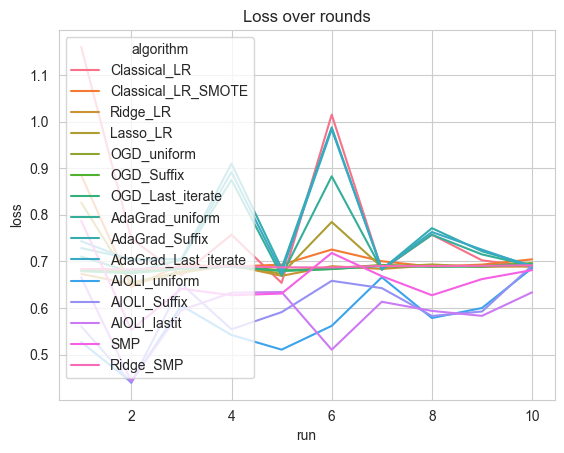

In [1037]:
plot_results(hazan_result)

In [839]:
hazan_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,1.1600614018
1,1,Classical_LR_SMOTE,0.8852520801
2,1,Ridge_LR,0.6731823489
3,1,Lasso_LR,0.8262324912
4,1,OGD_uniform,0.6834887022
...,...,...,...
145,10,AIOLI_uniform,0.6856214313
146,10,AIOLI_Suffix,0.6911336125
147,10,AIOLI_lastit,0.6336485945
148,10,SMP,0.6813405000


Train set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1.0000000000     99     98     95     96     95     98     94     96     95   
1.0000000000       1      2      5      4      5      2      6      4      5   

               run_10  
-1.0000000000      93  
1.0000000000        7  
Test set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1.0000000000     95     96     95     93     96     94     94     93     93   
1.0000000000       5      4      5      7      4      6      6      7      7   

               run_10  
-1.0000000000      93  
1.0000000000        7  


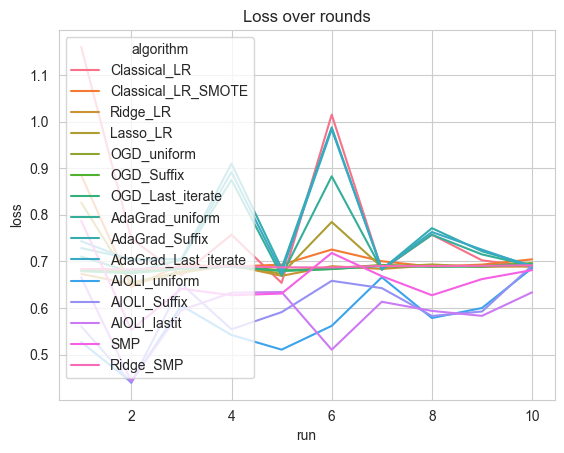

In [1038]:
plot_results(hazan_result, n = 100)

In [1039]:
hazan_Xminus1 = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10,
    X_hazan = -1
)

hazan_Xminus1_result = run_simulation(hazan_Xminus1)
print_results(hazan_Xminus1_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.4755984881,0.0337782751
AIOLI_lastit,0.4658019609,0.0292914546
AIOLI_uniform,0.4750523647,0.0283514632
AdaGrad_Last_iterate,0.5720147815,0.0405668339
AdaGrad_Suffix,0.5729222649,0.0404346574
AdaGrad_uniform,0.5763133746,0.0349197402
Classical_LR,0.5897954270,0.0532790941
Classical_LR_SMOTE,0.6112524301,0.0333833104
Lasso_LR,0.5949700933,0.0331999985



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0847338000,7.3674170000,7.4521508000,1.1567436492
AIOLI_lastit,0.0847338000,6.4214841000,6.5062179000,1.1735352012
AIOLI_uniform,0.0847338000,9.0850096000,9.1697434000,1.7507766984
AdaGrad_Last_iterate,0.0010748000,0.0000130000,0.0010878000,0.0002034439
AdaGrad_Suffix,0.0010748000,0.0000202000,0.0010950000,0.0002042640
AdaGrad_uniform,0.0010748000,0.0000210000,0.0010958000,0.0002042609
Classical_LR,0.0018726000,0.0000232000,0.0018958000,0.0001513842
Classical_LR_SMOTE,0.0022222000,0.0000138000,0.0022360000,0.0011489698
Lasso_LR,0.0018631000,0.0000124000,0.0018755000,0.0003476543


In [1040]:
print_results(hazan_Xminus1_result, selected_algorithms = ["Classical_LR","SMP","AIOLI_uniform", "Ridge_LR","OGD_uniform","AdaGrad_uniform"], plot = True)

Total time: 0:03:53.983264

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.4755984881,0.0337782751
AIOLI_lastit,0.4658019609,0.0292914546
AIOLI_uniform,0.4750523647,0.0283514632
AdaGrad_Last_iterate,0.5720147815,0.0405668339
AdaGrad_Suffix,0.5729222649,0.0404346574
AdaGrad_uniform,0.5763133746,0.0349197402
Classical_LR,0.5897954270,0.0532790941
Classical_LR_SMOTE,0.6112524301,0.0333833104
Lasso_LR,0.5949700933,0.0331999985



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0847338000,7.3674170000,7.4521508000,1.1567436492
AIOLI_lastit,0.0847338000,6.4214841000,6.5062179000,1.1735352012
AIOLI_uniform,0.0847338000,9.0850096000,9.1697434000,1.7507766984
AdaGrad_Last_iterate,0.0010748000,0.0000130000,0.0010878000,0.0002034439
AdaGrad_Suffix,0.0010748000,0.0000202000,0.0010950000,0.0002042640
AdaGrad_uniform,0.0010748000,0.0000210000,0.0010958000,0.0002042609
Classical_LR,0.0018726000,0.0000232000,0.0018958000,0.0001513842
Classical_LR_SMOTE,0.0022222000,0.0000138000,0.0022360000,0.0011489698
Lasso_LR,0.0018631000,0.0000124000,0.0018755000,0.0003476543


In [1200]:
settings_results_hazan = {
    "Hazan": hazan_result,
    "Hazan_Xminus1": hazan_Xminus1_result
}

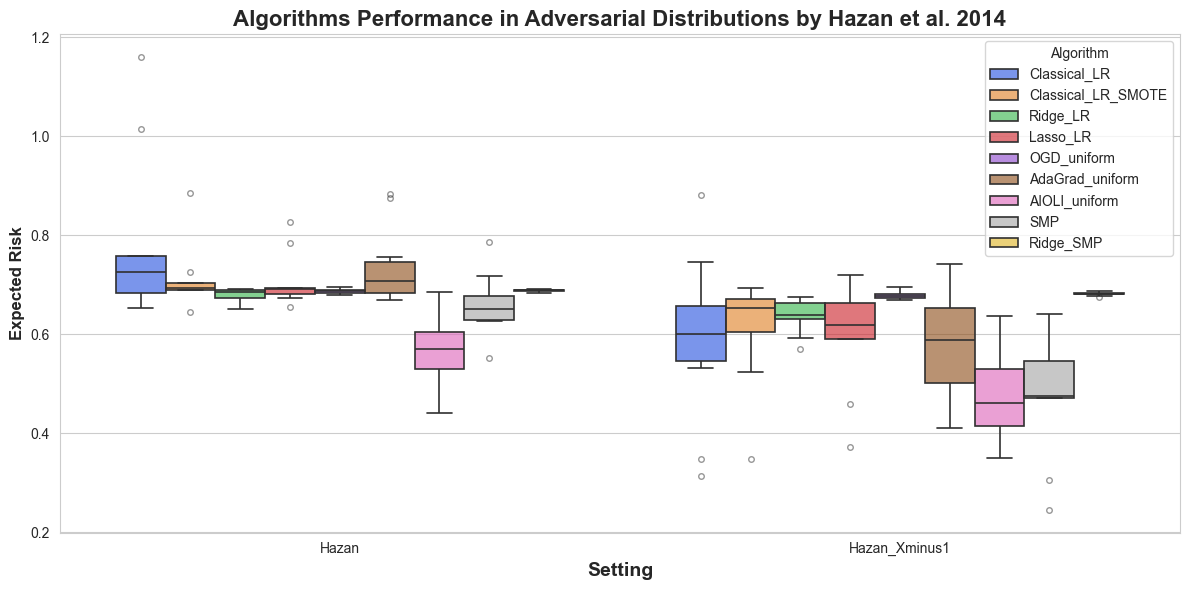

In [1203]:
compare_settings(settings_results_hazan, title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"])

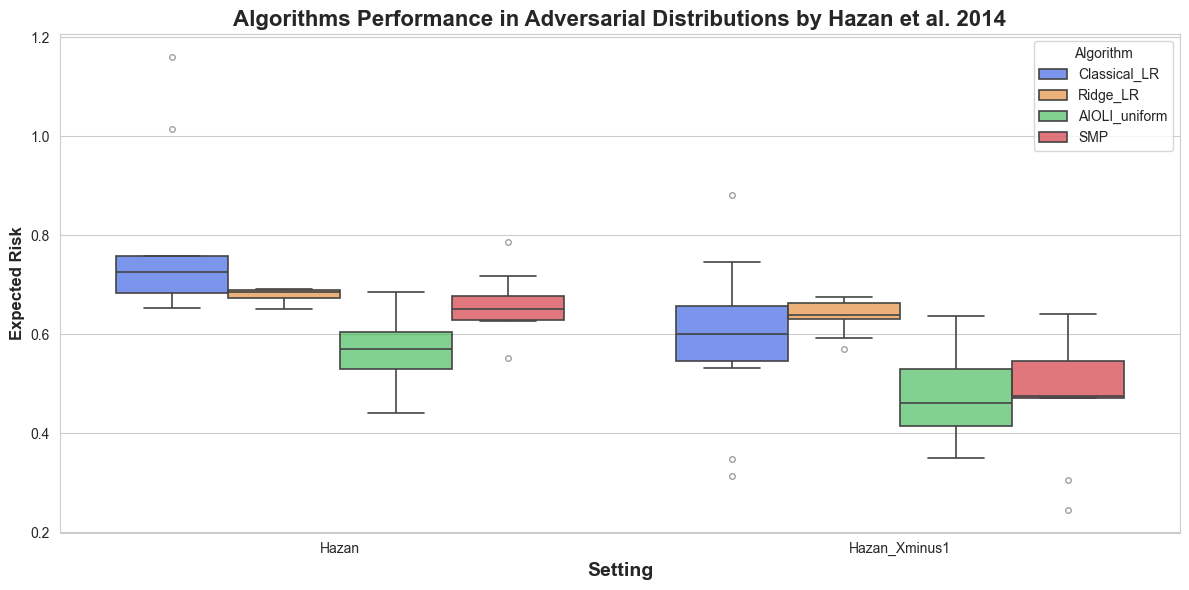

In [1204]:

compare_settings(
    settings_results_hazan,
    selected_algorithms=["Classical_LR", "SMP", "AIOLI_uniform", "Ridge_LR"], title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014"
)

## Balanced

In [846]:
#Binomial
binomial = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100
)

binomial_result = run_simulation(binomial)
print_results(binomial_result)

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.439
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.41
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.556
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.427
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.47
Lasso LR was fit manually
Run 6 fin

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6867137510,0.0077397541
AIOLI_lastit,0.6971249054,0.0082929884
AIOLI_uniform,0.6790550925,0.0067657082
AdaGrad_Last_iterate,0.6983823593,0.0082280424
AdaGrad_Suffix,0.6861410445,0.0075877872
AdaGrad_uniform,0.6810297017,0.0072791320
Classical_LR,0.6820079885,0.0065612336
Classical_LR_SMOTE,0.7130283602,0.0078268950
Lasso_LR,0.6830662142,0.0058170758



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0387797000,3.5402482000,3.5790279000,0.1839261483
AIOLI_lastit,0.0387797000,3.5186894000,3.5574691000,0.1951078304
AIOLI_uniform,0.0387797000,3.7625540000,3.8013337000,0.2204121648
AdaGrad_Last_iterate,0.0008804000,0.0000068000,0.0008872000,0.0000969232
AdaGrad_Suffix,0.0008804000,0.0000101000,0.0008905000,0.0000968543
AdaGrad_uniform,0.0008804000,0.0000109000,0.0008913000,0.0000969472
Classical_LR,0.0009146000,0.0000167000,0.0009313000,0.0001023421
Classical_LR_SMOTE,0.0013443000,0.0000084000,0.0013527000,0.0006840659
Lasso_LR,0.0015867000,0.0000073000,0.0015940000,0.0006485184


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     58     60     53     48     57     49     45     55     43      53
 1     42     40     47     52     43     51     55     45     57      47
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     56     66     48     35     43     55     49     60     41      58
 1     44     34     52     65     57     45     51     40     59      42


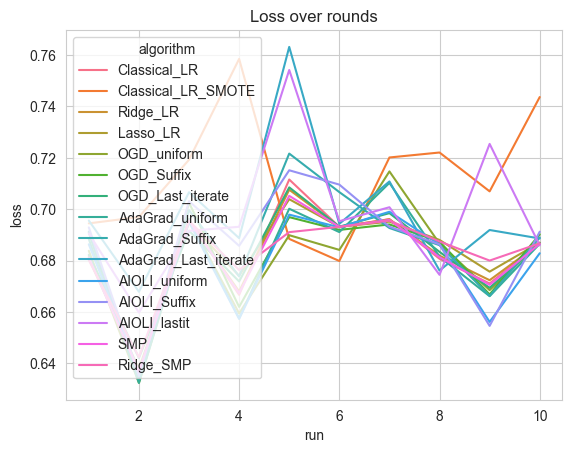

In [847]:
plot_results(binomial_result, n = 100)

In [848]:
# Sinusoidal
sinusoidal = SimulationConfig(
    sim_setting = "sinusoidal",
    n = 100
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.524
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
Lasso LR was 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.7121510427,0.0099564462
AIOLI_lastit,0.7415738087,0.0116419818
AIOLI_uniform,0.7051748039,0.0058870013
AdaGrad_Last_iterate,0.7865582943,0.0251260251
AdaGrad_Suffix,0.7066970804,0.0064646230
AdaGrad_uniform,0.6997084753,0.0031935512
Classical_LR,0.7144883658,0.0086827577
Classical_LR_SMOTE,0.7534133986,0.0111338392
Lasso_LR,0.6972836204,0.0030827968



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1913356000,18.1829381000,18.3742737000,0.6473587776
AIOLI_lastit,0.1913356000,17.9587055000,18.1500411000,0.5283566517
AIOLI_uniform,0.1913356000,17.9801276000,18.1714632000,0.5454493885
AdaGrad_Last_iterate,0.0010691000,0.0000117000,0.0010808000,0.0000958835
AdaGrad_Suffix,0.0010691000,0.0000174000,0.0010865000,0.0000956151
AdaGrad_uniform,0.0010691000,0.0000869000,0.0011560000,0.0001079236
Classical_LR,0.0016755000,0.0000188000,0.0016943000,0.0001353414
Classical_LR_SMOTE,0.0021590000,0.0000118000,0.0021708000,0.0002563554
Lasso_LR,0.0152574000,0.0000102000,0.0152676000,0.0026101896


In [850]:
# Well Specified
well_specified = SimulationConfig(
    sim_setting = "well specified",
    d = 3
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.508
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6966828027,0.0161585573
AIOLI_lastit,0.7169512368,0.0240517513
AIOLI_uniform,0.6890127583,0.0093574560
AdaGrad_Last_iterate,0.7598296449,0.0416223200
AdaGrad_Suffix,0.6966091651,0.0106876652
AdaGrad_uniform,0.6865098233,0.0046868987
Classical_LR,0.6895696220,0.0124809952
Classical_LR_SMOTE,0.7232430684,0.0121094913
Lasso_LR,0.6900579755,0.0061196758



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1880367000,17.3241574000,17.5121941000,0.3046310937
AIOLI_lastit,0.1880367000,17.3951913000,17.5832280000,0.2739085629
AIOLI_uniform,0.1880367000,17.4314037000,17.6194404000,0.2466305607
AdaGrad_Last_iterate,0.0011494000,0.0000078000,0.0011572000,0.0001485815
AdaGrad_Suffix,0.0011494000,0.0000130000,0.0011624000,0.0001487169
AdaGrad_uniform,0.0011494000,0.0000120000,0.0011614000,0.0001487276
Classical_LR,0.0018401000,0.0000173000,0.0018574000,0.0001733599
Classical_LR_SMOTE,0.0021530000,0.0000095000,0.0021625000,0.0003680871
Lasso_LR,0.0119155000,0.0000084000,0.0119239000,0.0024662505


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     47     53     48     51     50     56     45     46     50      46
 1     53     47     52     49     50     44     55     54     50      54
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     45     55     48     51     53     53     50     55     46      53
 1     55     45     52     49     47     47     50     45     54      47


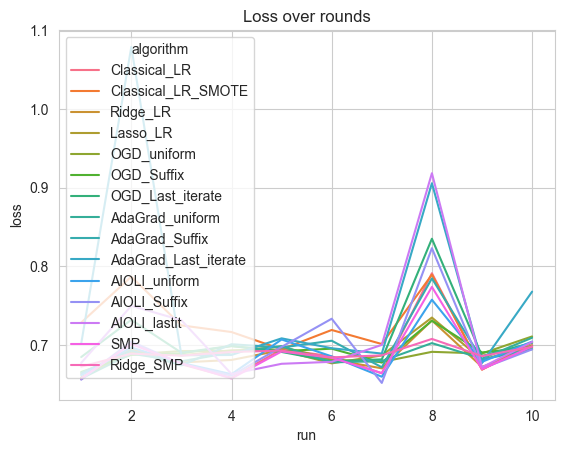

In [851]:
plot_results(well_specified_result)

In [854]:
# High Dimensional
high_dimensional = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25
)

In [855]:

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.517
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.572
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551
Lasso LR was fit manually
Run 5 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an a

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6535173456,0.0115709599
AIOLI_lastit,0.6346128716,0.0143011276
AIOLI_uniform,0.6632080271,0.0079492300
AdaGrad_Last_iterate,5.3800235423,1.1172384281
AdaGrad_Suffix,3.7353933054,0.8282394462
AdaGrad_uniform,3.9471693553,1.0110655662
Classical_LR,7.9199538214,2.7383673233
Classical_LR_SMOTE,4.3613438617,0.4817987004
Lasso_LR,0.7243269278,0.0269266629



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3915519000,38.0244653000,38.4160172000,0.5566174178
AIOLI_lastit,0.3915519000,36.8386150000,37.2301669000,0.5318999737
AIOLI_uniform,0.3915519000,37.2973677000,37.6889196000,0.4544371866
AdaGrad_Last_iterate,0.0009134000,0.0000076000,0.0009210000,0.0001574267
AdaGrad_Suffix,0.0009134000,0.0000111000,0.0009245000,0.0001579426
AdaGrad_uniform,0.0009134000,0.0000124000,0.0009258000,0.0001574524
Classical_LR,0.0034484000,0.0000155000,0.0034639000,0.0002339076
Classical_LR_SMOTE,0.0042258000,0.0000081000,0.0042339000,0.0007456723
Lasso_LR,0.1062706000,0.0000069000,0.1062775000,0.0152313289


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     11      7     12     10      8      9      6     14      6      13
 1      9     13      8     10     12     11     14      6     14       7
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     51     47     44     49     54     56     55     56      46
 1     52     49     53     56     51     46     44     45     44      54


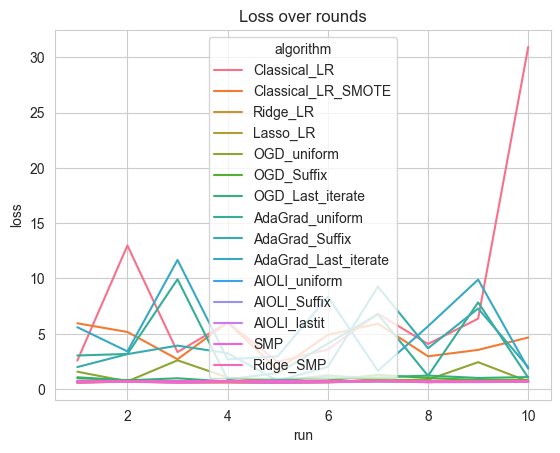

In [856]:
plot_results(high_dimensional_result, n = 20)

In [857]:
# High Dimensionality
high_dimensionality = SimulationConfig(
    sim_setting = "high dimensional",
    n = 50,
    d = 25
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.485
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.512
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.52
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.568
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.43

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5400186026,0.0112122790
AIOLI_lastit,0.5158575158,0.0128875715
AIOLI_uniform,0.5817330910,0.0091465575
AdaGrad_Last_iterate,3.0219255099,0.3138449305
AdaGrad_Suffix,1.6018677196,0.2457785577
AdaGrad_uniform,2.4815826558,0.5349362511
Classical_LR,20.8518652308,6.0816508373
Classical_LR_SMOTE,36.9109960728,12.7494638123
Lasso_LR,0.5729264707,0.0219770282



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,1.6920316000,153.6063824000,155.2984140000,1.8580509462
AIOLI_lastit,1.6920316000,154.5057874000,156.1978190000,1.7863122950
AIOLI_uniform,1.6920316000,154.0769144000,155.7689460000,1.9014482705
AdaGrad_Last_iterate,0.0022060000,0.0000091000,0.0022151000,0.0003017108
AdaGrad_Suffix,0.0022060000,0.0000146000,0.0022206000,0.0003018767
AdaGrad_uniform,0.0022060000,0.0000161000,0.0022221000,0.0003016879
Classical_LR,0.0043324000,0.0000172000,0.0043496000,0.0005497712
Classical_LR_SMOTE,0.0071938000,0.0000083000,0.0072021000,0.0007845236
Lasso_LR,0.1069669000,0.0000067000,0.1069736000,0.0103934426


In [922]:
# hd50_result_object = print_results(high_dimensionality_result, summary_object = True)
# hd50_result_object.to_csv(f"high_dimensional_n50.csv")

Total time: 1:18:31.005803

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5400186026,0.0112122790
AIOLI_lastit,0.5158575158,0.0128875715
AIOLI_uniform,0.5817330910,0.0091465575
AdaGrad_Last_iterate,3.0219255099,0.3138449305
AdaGrad_Suffix,1.6018677196,0.2457785577
AdaGrad_uniform,2.4815826558,0.5349362511
Classical_LR,20.8518652308,6.0816508373
Classical_LR_SMOTE,36.9109960728,12.7494638123
Lasso_LR,0.5729264707,0.0219770282



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,1.6920316000,153.6063824000,155.2984140000,1.8580509462
AIOLI_lastit,1.6920316000,154.5057874000,156.1978190000,1.7863122950
AIOLI_uniform,1.6920316000,154.0769144000,155.7689460000,1.9014482705
AdaGrad_Last_iterate,0.0022060000,0.0000091000,0.0022151000,0.0003017108
AdaGrad_Suffix,0.0022060000,0.0000146000,0.0022206000,0.0003018767
AdaGrad_uniform,0.0022060000,0.0000161000,0.0022221000,0.0003016879
Classical_LR,0.0043324000,0.0000172000,0.0043496000,0.0005497712
Classical_LR_SMOTE,0.0071938000,0.0000083000,0.0072021000,0.0007845236
Lasso_LR,0.1069669000,0.0000067000,0.1069736000,0.0103934426


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     29     23     23     23     23     28     19     31     17      26
 1     21     27     27     27     27     22     31     19     33      24
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     51     47     44     49     54     56     55     56      46
 1     52     49     53     56     51     46     44     45     44      54


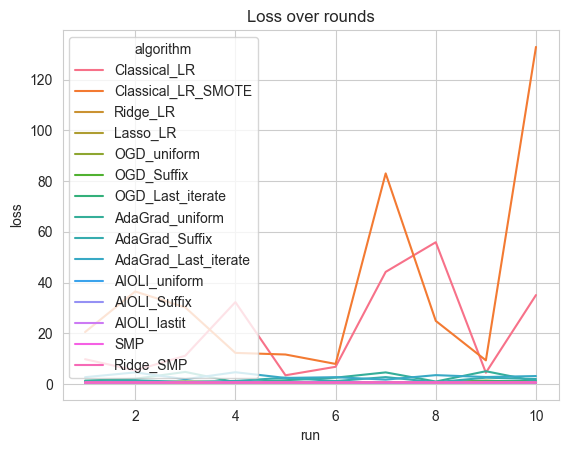

In [858]:
plot_results(high_dimensionality_result, n = 50)

In [859]:
#HD n75
high_dimensionality_higher_n = SimulationConfig(
    sim_setting = "high dimensional",
    n = 75,
    d = 25
)

high_dimensionality_higher_n_result = run_simulation(high_dimensionality_higher_n)
print_results(high_dimensionality_higher_n_result)

75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.483
Lasso LR was fit manually
Run 1 finished
75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.515
Lasso LR was fit manually
Run 2 finished
75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.517
Lasso LR was fit manually
Run 3 finished
75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551
Lasso LR was fit manually
Run 4 finished
75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.546
Lasso LR was fit manually
Run 5 finished
75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.4

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.4976708804,0.0128022103
AIOLI_lastit,0.4870991704,0.0182382665
AIOLI_uniform,0.5329791456,0.0098310253
AdaGrad_Last_iterate,2.8061216021,0.1633401168
AdaGrad_Suffix,0.8584853034,0.0885383669
AdaGrad_uniform,1.7517982382,0.3673139289
Classical_LR,116.7747227992,101.6710858127
Classical_LR_SMOTE,93.0273481030,53.0842706088
Lasso_LR,0.5171988730,0.0241745325



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,2.9360858000,294.3578651000,297.2939509000,10.5830618713
AIOLI_lastit,2.9360858000,291.1403841000,294.0764699000,8.2005080207
AIOLI_uniform,2.9360858000,285.2376518000,288.1737376000,7.7982142103
AdaGrad_Last_iterate,0.0030545000,0.0000168000,0.0030713000,0.0001171794
AdaGrad_Suffix,0.0030545000,0.0000255000,0.0030800000,0.0001164849
AdaGrad_uniform,0.0030545000,0.0000279000,0.0030824000,0.0001163394
Classical_LR,0.0166786000,0.0000227000,0.0167013000,0.0060259572
Classical_LR_SMOTE,0.0247905000,0.0000180000,0.0248085000,0.0077162662
Lasso_LR,0.1482132000,0.0000091000,0.1482223000,0.0113919340


In [1079]:
# Sinusoidal
sinusoidal = SimulationConfig(
    sim_setting = "sinusoidal",
    n = 100,
    d = 3
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.452
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.473
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.539
Lasso LR was fit manually
Run 6 f

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6581136968,0.0178963154
AIOLI_lastit,0.6690431896,0.0226542712
AIOLI_uniform,0.6501836130,0.0165314314
AdaGrad_Last_iterate,0.7153813519,0.0143688478
AdaGrad_Suffix,0.6873637134,0.0089494209
AdaGrad_uniform,0.6825889337,0.0067737673
Classical_LR,0.6584923182,0.0154409620
Classical_LR_SMOTE,0.7056998088,0.0219590324
Lasso_LR,0.6604870590,0.0134005016



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2393057000,24.9892134000,25.2285191000,2.9364795338
AIOLI_lastit,0.2393057000,23.8933553000,24.1326610000,3.5353779570
AIOLI_uniform,0.2393057000,24.9720821000,25.2113878000,3.5883455901
AdaGrad_Last_iterate,0.0021346000,0.0000425000,0.0021771000,0.0007324626
AdaGrad_Suffix,0.0021346000,0.0000189000,0.0021535000,0.0007385081
AdaGrad_uniform,0.0021346000,0.0000175000,0.0021521000,0.0007377410
Classical_LR,0.0023251000,0.0000220000,0.0023471000,0.0001665474
Classical_LR_SMOTE,0.0031596000,0.0000133000,0.0031729000,0.0008601437
Lasso_LR,0.0168326000,0.0000115000,0.0168441000,0.0036918934


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     53     49     53     45     33     48     47     57     46      48
 1     47     51     47     55     67     52     53     43     54      52
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     43     54     52     36     45     43     47     55     50      46
 1     57     46     48     64     55     57     53     45     50      54


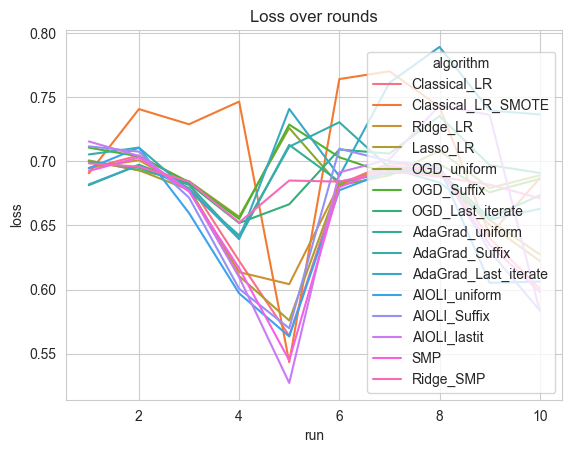

In [1080]:
plot_results(sinusoidal_result)

In [862]:
quadratic = SimulationConfig(
    sim_setting = "quadratic",
    d = 3
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.051
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.052
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.054
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.048
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.045
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.047
Lasso LR was fit ma

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5998395036,0.0138678476
AIOLI_lastit,0.6177084853,0.0126403412
AIOLI_uniform,0.5900692148,0.0138373402
AdaGrad_Last_iterate,0.6708072757,0.0320647112
AdaGrad_Suffix,0.6426171154,0.0158294032
AdaGrad_uniform,0.6481312149,0.0103228117
Classical_LR,0.5826225886,0.0127730806
Classical_LR_SMOTE,0.5977584484,0.0146489241
Lasso_LR,0.5951871491,0.0153678646



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2588523000,23.7655056000,24.0243579000,1.0124742219
AIOLI_lastit,0.2588523000,22.9643446000,23.2231969000,0.9032175667
AIOLI_uniform,0.2588523000,25.5008243000,25.7596766000,1.9316260432
AdaGrad_Last_iterate,0.0013288000,0.0000169000,0.0013457000,0.0002267675
AdaGrad_Suffix,0.0013288000,0.0000505000,0.0013793000,0.0002234177
AdaGrad_uniform,0.0013288000,0.0000258000,0.0013546000,0.0002267760
Classical_LR,0.0019918000,0.0000168000,0.0020086000,0.0002401862
Classical_LR_SMOTE,0.0020066000,0.0000096000,0.0020162000,0.0001643145
Lasso_LR,0.0089176000,0.0000084000,0.0089260000,0.0028157391


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     54     54     54     57     50     59     43     49     55      50
 1     46     46     46     43     50     41     57     51     45      50
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     61     49     52     59     51     51     57     51      57
 1     52     39     51     48     41     49     49     43     49      43


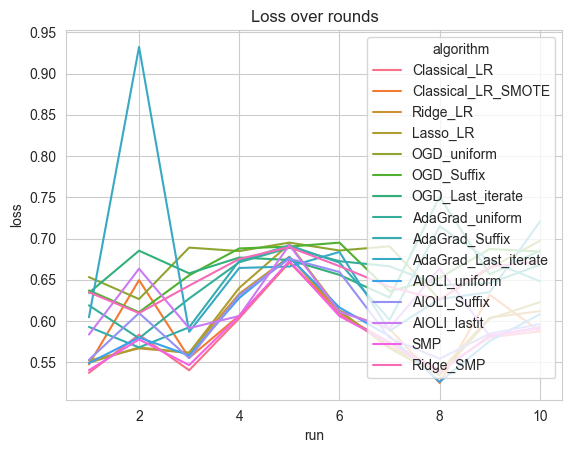

In [863]:
plot_results(quadratic_result)

In [871]:
# Sign
sign = SimulationConfig(
    sim_setting = "sign",
    n = 100,
    d = 3
)

sign_result = run_simulation(sign)
print_results(sign_result)

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
Lasso LR was fit manually
Run 6 finished
100 (training) samples were gen

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.1154084456,0.0038356623
AIOLI_lastit,0.0999358704,0.0031689566
AIOLI_uniform,0.1402210239,0.0038511061
AdaGrad_Last_iterate,0.1784275760,0.0110943224
AdaGrad_Suffix,0.1855152790,0.0075123991
AdaGrad_uniform,0.2233662064,0.0118377941
Classical_LR,0.0638942176,0.0312220150
Classical_LR_SMOTE,0.0812250824,0.0358645537
Lasso_LR,0.1230132152,0.0056139158



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2134622000,19.6781992000,19.8916614000,0.2006149366
AIOLI_lastit,0.2134622000,19.9848402000,20.1983024000,0.2739831860
AIOLI_uniform,0.2134622000,20.8399950000,21.0534572000,0.5781491983
AdaGrad_Last_iterate,0.0009418000,0.0000184000,0.0009602000,0.0000422566
AdaGrad_Suffix,0.0009418000,0.0000296000,0.0009714000,0.0000419617
AdaGrad_uniform,0.0009418000,0.0000315000,0.0009733000,0.0000424361
Classical_LR,0.0039396000,0.0000172000,0.0039568000,0.0003680520
Classical_LR_SMOTE,0.0041309000,0.0000116000,0.0041425000,0.0005454664
Lasso_LR,0.0047142000,0.0000086000,0.0047228000,0.0008018829


In [870]:
# Alternating
alternating = SimulationConfig(
    sim_setting = "alternating",
    n = 100,
    d = 3
)

alternating_result = run_simulation(alternating)
print_results(alternating_result)

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.475
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.465
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.451
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.444
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.46
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
Lasso LR was fit manually
Ru

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6257061018,0.0128643225
AIOLI_lastit,0.6356429644,0.0142026856
AIOLI_uniform,0.6175150408,0.0127534141
AdaGrad_Last_iterate,0.6776319354,0.0207987782
AdaGrad_Suffix,0.6439842887,0.0158767050
AdaGrad_uniform,0.6531494430,0.0138852419
Classical_LR,0.6198823412,0.0124296825
Classical_LR_SMOTE,0.6547056714,0.0162958740
Lasso_LR,0.6214314224,0.0132639203



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2460707000,22.2056432000,22.4517139000,1.1104368253
AIOLI_lastit,0.2460707000,21.5549650000,21.8010357000,0.9807842810
AIOLI_uniform,0.2460707000,23.4339325000,23.6800032000,1.6634360781
AdaGrad_Last_iterate,0.0016783000,0.0000156000,0.0016939000,0.0002893050
AdaGrad_Suffix,0.0016783000,0.0000228000,0.0017011000,0.0002898134
AdaGrad_uniform,0.0016783000,0.0000240000,0.0017023000,0.0002897348
Classical_LR,0.0023588000,0.0000213000,0.0023801000,0.0002183413
Classical_LR_SMOTE,0.0025241000,0.0000146000,0.0025387000,0.0002212311
Lasso_LR,0.0121002000,0.0000126000,0.0121128000,0.0022701857


In [872]:
# Hidden X
hidden_x = SimulationConfig(
    sim_setting = "hidden x",
    n = 100,
    d = 3
)

hidden_x_result = run_simulation(hidden_x)
print_results(hidden_x_result)

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.481
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.506
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.543
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.544
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489
Datas

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6552973326,0.0115094243
AIOLI_lastit,0.6575955334,0.0127731467
AIOLI_uniform,0.6506715172,0.0132035823
AdaGrad_Last_iterate,0.6734620625,0.0229869006
AdaGrad_Suffix,0.6652779292,0.0149663820
AdaGrad_uniform,0.6635586861,0.0135487394
Classical_LR,0.6441239065,0.0128827965
Classical_LR_SMOTE,0.6477642680,0.0171841137
Lasso_LR,0.6517908672,0.0130030466



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2456601000,20.5494962000,20.7951563000,0.4238348946
AIOLI_lastit,0.2456601000,20.8167520000,21.0624121000,0.3816049903
AIOLI_uniform,0.2456601000,21.4738201000,21.7194802000,0.6711039408
AdaGrad_Last_iterate,0.0011168000,0.0000149000,0.0011317000,0.0001066690
AdaGrad_Suffix,0.0011168000,0.0000276000,0.0011444000,0.0001061196
AdaGrad_uniform,0.0011168000,0.0000272000,0.0011440000,0.0001062430
Classical_LR,0.0018958000,0.0000258000,0.0019216000,0.0001906381
Classical_LR_SMOTE,0.0024544000,0.0000159000,0.0024703000,0.0002894971
Lasso_LR,0.0097647000,0.0000142000,0.0097789000,0.0028189687


In [1205]:
# Graph groups
settings_results1 = {
    # "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result,

}

settings_results2 = {
    "Sinusoidal" : sinusoidal_result,
    "Sign" : sign_result,
    "Hidden X" : hidden_x_result,
    "Alternating" : alternating_result,
}

settings_results = {
    "Well specified": well_specified_result,
    # "High Dimensional": high_dimensional_result,
    # "High Dimensionality": high_dimensionality_result,
    "Quadratic": quadratic_result,
    "Binomial X": binomial_result
}

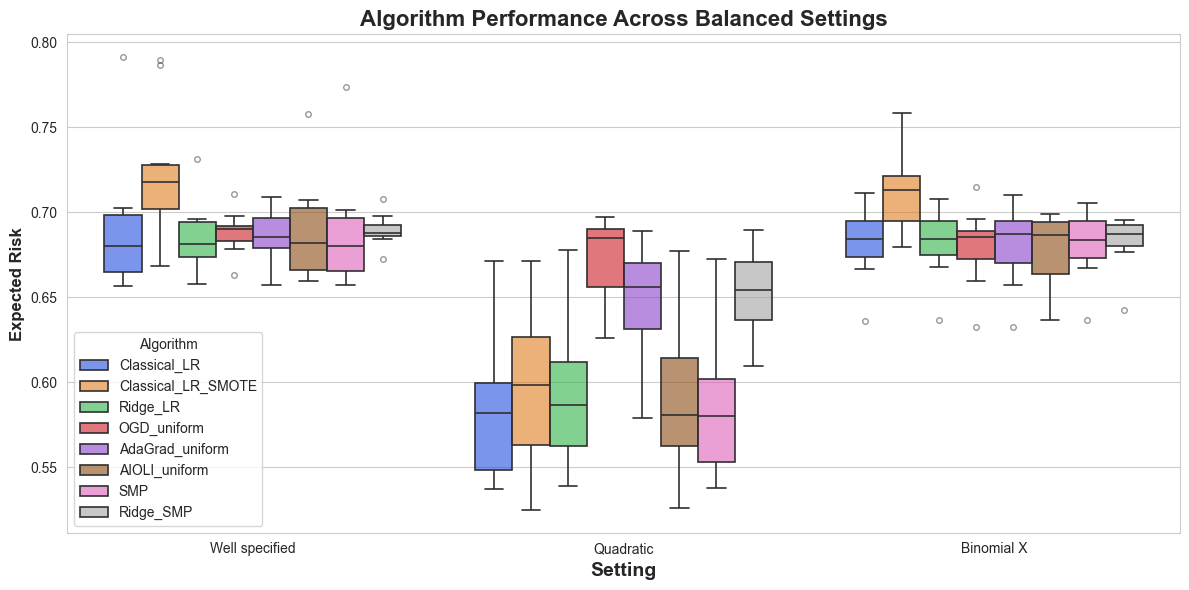

In [1206]:
compare_settings(
    settings_results, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

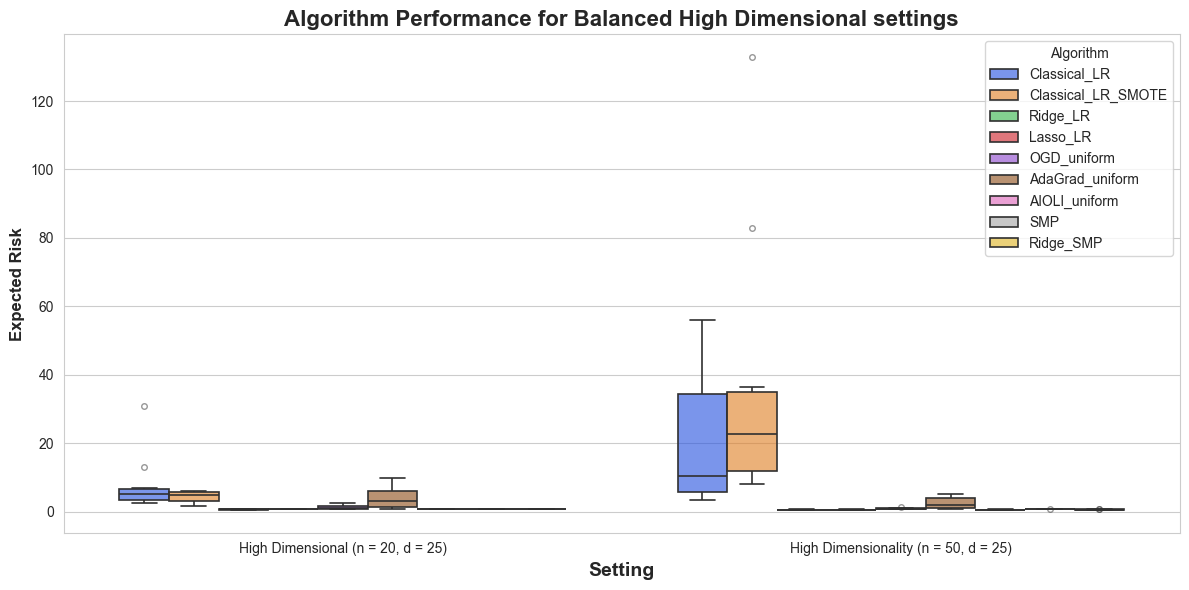

In [1207]:
compare_settings(
    settings_results1,
    title = "Algorithm Performance for Balanced High Dimensional settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

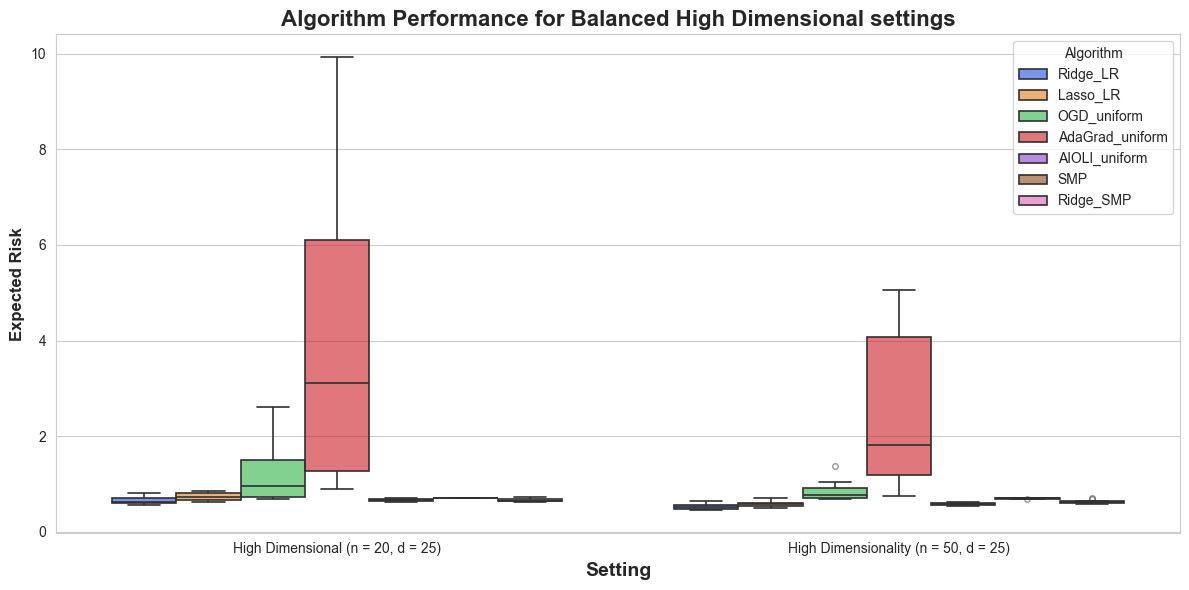

In [1209]:
compare_settings(
    settings_results1,
    title="Algorithm Performance for Balanced High Dimensional settings",
    selected_algorithms=["Ridge_LR", "Lasso_LR", "OGD_uniform", "AdaGrad_uniform",
                         "AIOLI_uniform", "SMP", "Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)",
              "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

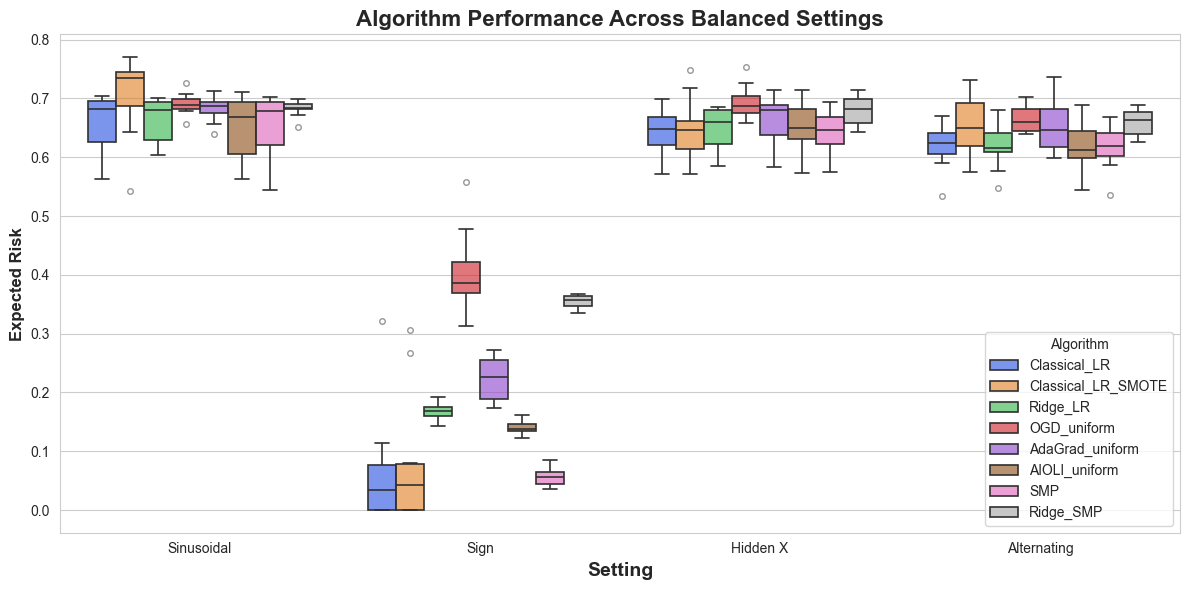

In [1208]:
compare_settings(
    settings_results2, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

In [867]:
# FOR AVERAGING STRATEGIES PART

settings_results_HD = {
    # "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}

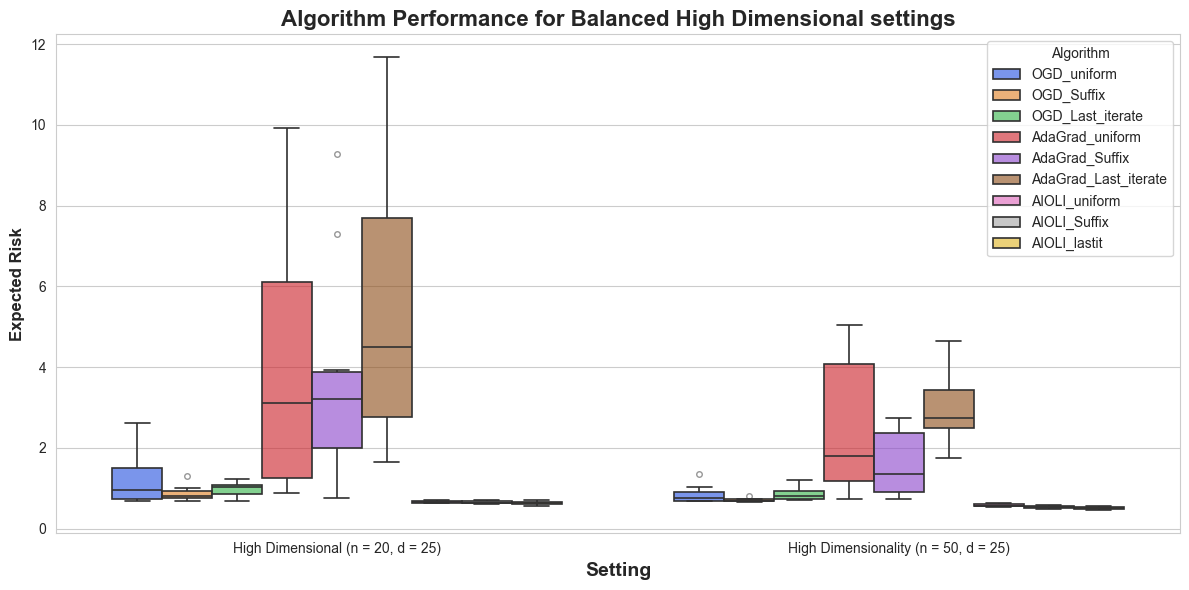

In [1210]:
compare_settings(
    settings_results_HD,
    title = "Algorithm Performance for Balanced High Dimensional settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

In [1106]:
print_results(high_dimensional_result)

Total time: 0:19:42.552341

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6535173456,0.0115709599
AIOLI_lastit,0.6346128716,0.0143011276
AIOLI_uniform,0.6632080271,0.0079492300
AdaGrad_Last_iterate,5.3800235423,1.1172384281
AdaGrad_Suffix,3.7353933054,0.8282394462
AdaGrad_uniform,3.9471693553,1.0110655662
Classical_LR,7.9199538214,2.7383673233
Classical_LR_SMOTE,4.3613438617,0.4817987004
Lasso_LR,0.7243269278,0.0269266629



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3915519000,38.0244653000,38.4160172000,0.5566174178
AIOLI_lastit,0.3915519000,36.8386150000,37.2301669000,0.5318999737
AIOLI_uniform,0.3915519000,37.2973677000,37.6889196000,0.4544371866
AdaGrad_Last_iterate,0.0009134000,0.0000076000,0.0009210000,0.0001574267
AdaGrad_Suffix,0.0009134000,0.0000111000,0.0009245000,0.0001579426
AdaGrad_uniform,0.0009134000,0.0000124000,0.0009258000,0.0001574524
Classical_LR,0.0034484000,0.0000155000,0.0034639000,0.0002339076
Classical_LR_SMOTE,0.0042258000,0.0000081000,0.0042339000,0.0007456723
Lasso_LR,0.1062706000,0.0000069000,0.1062775000,0.0152313289


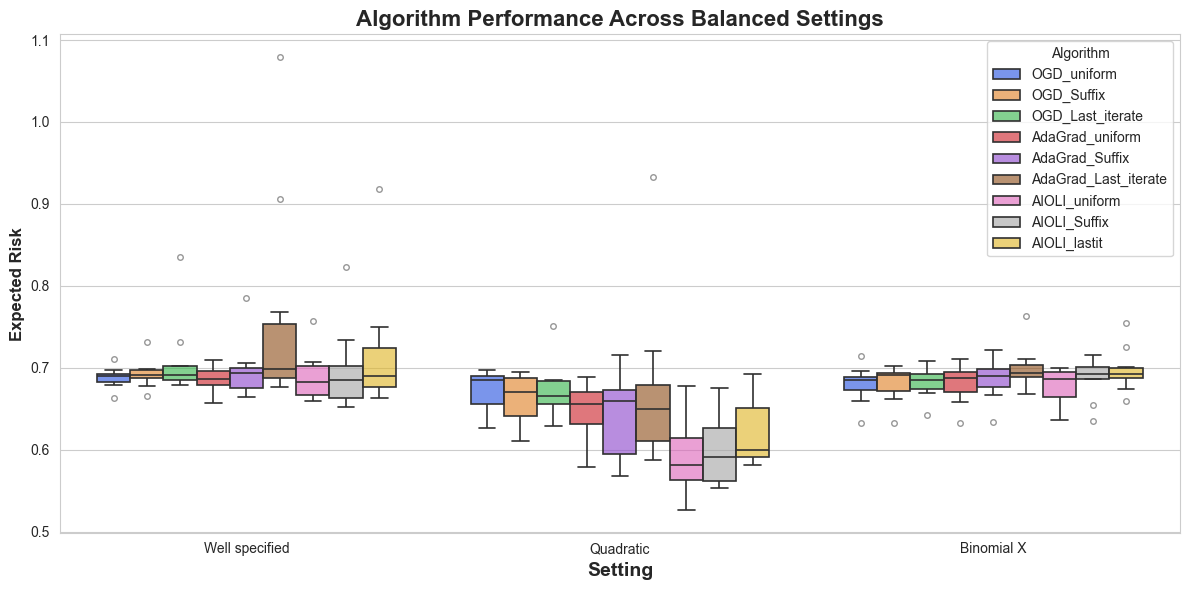

In [1214]:
compare_settings(
    settings_results, selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

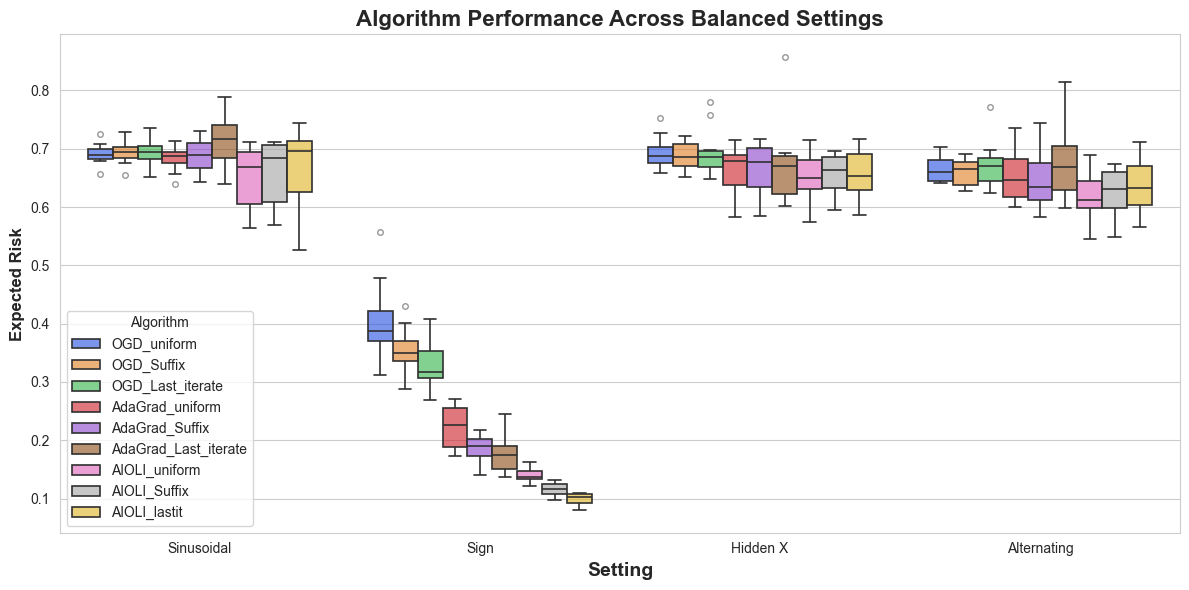

In [1213]:
compare_settings(
    settings_results2, selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

In [1150]:
print_results(sign_result)

Total time: 0:10:22.860731

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.1154084456,0.0038356623
AIOLI_lastit,0.0999358704,0.0031689566
AIOLI_uniform,0.1402210239,0.0038511061
AdaGrad_Last_iterate,0.1784275760,0.0110943224
AdaGrad_Suffix,0.1855152790,0.0075123991
AdaGrad_uniform,0.2233662064,0.0118377941
Classical_LR,0.0638942176,0.0312220150
Classical_LR_SMOTE,0.0812250824,0.0358645537
Lasso_LR,0.1230132152,0.0056139158



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2134622000,19.6781992000,19.8916614000,0.2006149366
AIOLI_lastit,0.2134622000,19.9848402000,20.1983024000,0.2739831860
AIOLI_uniform,0.2134622000,20.8399950000,21.0534572000,0.5781491983
AdaGrad_Last_iterate,0.0009418000,0.0000184000,0.0009602000,0.0000422566
AdaGrad_Suffix,0.0009418000,0.0000296000,0.0009714000,0.0000419617
AdaGrad_uniform,0.0009418000,0.0000315000,0.0009733000,0.0000424361
Classical_LR,0.0039396000,0.0000172000,0.0039568000,0.0003680520
Classical_LR_SMOTE,0.0041309000,0.0000116000,0.0041425000,0.0005454664
Lasso_LR,0.0047142000,0.0000086000,0.0047228000,0.0008018829


In [869]:
highly_correlated_x = SimulationConfig(
    sim_setting = "highly correlated x",
    n = 100,
    d = 3
)

highly_correlated_x_result = run_simulation(highly_correlated_x)
print_results(highly_correlated_x_result)

100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.435
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.476
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.731
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.418
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an ave

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6589140603,0.0152463567
AIOLI_lastit,0.6702685906,0.0173243969
AIOLI_uniform,0.6547192028,0.0140634538
AdaGrad_Last_iterate,0.7797776388,0.0511636201
AdaGrad_Suffix,0.6738883578,0.0194022303
AdaGrad_uniform,0.6591506949,0.0159229694
Classical_LR,0.6555832252,0.0135681120
Classical_LR_SMOTE,0.7032910397,0.0116497224
Lasso_LR,0.6548355377,0.0143671899



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2702827000,26.5145301000,26.7848128000,2.3669123519
AIOLI_lastit,0.2702827000,25.9107864000,26.1810691000,2.2743102616
AIOLI_uniform,0.2702827000,27.0865087000,27.3567914000,2.0372397281
AdaGrad_Last_iterate,0.0012759000,0.0000101000,0.0012860000,0.0001987987
AdaGrad_Suffix,0.0012759000,0.0000148000,0.0012907000,0.0001995997
AdaGrad_uniform,0.0012759000,0.0000180000,0.0012939000,0.0002001990
Classical_LR,0.0021970000,0.0000202000,0.0022172000,0.0002952581
Classical_LR_SMOTE,0.0039573000,0.0000140000,0.0039713000,0.0010127614
Lasso_LR,0.0167265000,0.0000136000,0.0167401000,0.0018233981


## Unbalanced

### Experiments

In [874]:
# Binomial
binomial_unbalanced = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100,
    d = 1,
    sim_balanced= False
)

binomial_unbalanced_result = run_simulation(binomial_unbalanced)
print_results(binomial_unbalanced_result)

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.991
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.993
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.993
Dataset only has one class
Logistic regression was fit manually


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0601180068,0.0238328641
AIOLI_lastit,0.0617171035,0.0247552342
AIOLI_uniform,0.0599822723,0.0215215287
AdaGrad_Last_iterate,0.0730466860,0.0311139052
AdaGrad_Suffix,0.0670897041,0.0301713142
AdaGrad_uniform,0.0660907958,0.0291035393
Classical_LR,0.1619030294,0.1051424864
Classical_LR_SMOTE,0.1655825936,0.1045460884
Lasso_LR,0.0610576599,0.0241844917



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0939936000,9.0559942000,9.1499878000,0.5020197662
AIOLI_lastit,0.0939936000,8.4650866000,8.5590802000,0.1286370612
AIOLI_uniform,0.0939936000,8.5152818000,8.6092754000,0.0776134898
AdaGrad_Last_iterate,0.0012011000,0.0000097000,0.0012108000,0.0002736655
AdaGrad_Suffix,0.0012011000,0.0000148000,0.0012159000,0.0002740937
AdaGrad_uniform,0.0012011000,0.0000155000,0.0012166000,0.0002739617
Classical_LR,0.0019570000,0.0000221000,0.0019791000,0.0004715651
Classical_LR_SMOTE,0.0014349000,0.0000140000,0.0014489000,0.0002069253
Lasso_LR,0.0014784000,0.0000125000,0.0014909000,0.0001750582


Train set
    run_1  run_2  run_3          run_4          run_5  run_6  run_7  run_8  \
-1      1      1      1            NaN            NaN      1      1      2   
 1     99     99     99 100.0000000000 100.0000000000     99     99     98   

            run_9  run_10  
-1            NaN       1  
 1 100.0000000000      99  
Test set
            run_1          run_2          run_3  run_4  run_5          run_6  \
-1            NaN            NaN            NaN      5      1            NaN   
 1 100.0000000000 100.0000000000 100.0000000000     95     99 100.0000000000   

    run_7  run_8          run_9  run_10  
-1      1      2            NaN       2  
 1     99     98 100.0000000000      98  


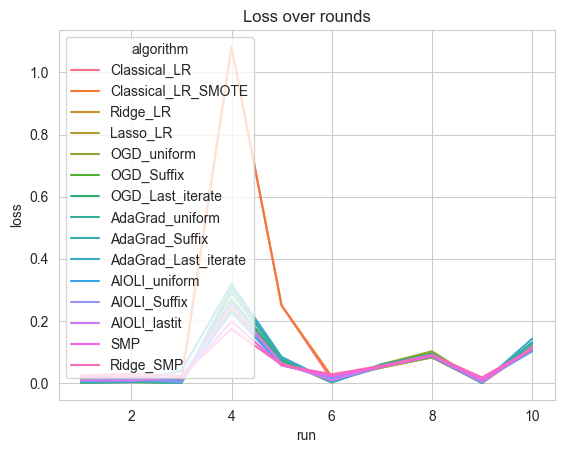

In [875]:
plot_results(binomial_unbalanced_result, n = 100)

In [876]:
# Well specified
well_specified_unbalanced = SimulationConfig(
    sim_setting = "well specified",
    sim_balanced= False
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.984
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 4 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.986
Lasso LR was fit manually
Run 5 finished
100

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0778745028,0.0096481768
AIOLI_lastit,0.0913966895,0.0150569310
AIOLI_uniform,0.0784823495,0.0086273263
AdaGrad_Last_iterate,0.1090602422,0.0264928703
AdaGrad_Suffix,0.0866160580,0.0127733833
AdaGrad_uniform,0.0849797623,0.0136303319
Classical_LR,0.1169532572,0.0305573171
Classical_LR_SMOTE,0.1356259599,0.0311252824
Lasso_LR,0.0806260077,0.0094500287



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3101330000,30.3562325000,30.6663655000,0.3908618333
AIOLI_lastit,0.3101330000,30.4364114000,30.7465444000,0.4238944872
AIOLI_uniform,0.3101330000,30.7835234000,31.0936564000,0.4567701692
AdaGrad_Last_iterate,0.0012421000,0.0000114000,0.0012535000,0.0001695412
AdaGrad_Suffix,0.0012421000,0.0000172000,0.0012593000,0.0001702331
AdaGrad_uniform,0.0012421000,0.0000188000,0.0012609000,0.0001703990
Classical_LR,0.0031945000,0.0000193000,0.0032138000,0.0001863398
Classical_LR_SMOTE,0.0032866000,0.0000126000,0.0032992000,0.0002909192
Lasso_LR,0.0171534000,0.0000110000,0.0171644000,0.0020439088


In [877]:
well_specified_unbalanced_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.1051624900
1,1,Classical_LR_SMOTE,0.1384755422
2,1,Ridge_LR,0.1116797324
3,1,Lasso_LR,0.1116339501
4,1,OGD_uniform,0.1033088531
...,...,...,...
145,10,AIOLI_uniform,0.0496767135
146,10,AIOLI_Suffix,0.0481050004
147,10,AIOLI_lastit,0.0452037232
148,10,SMP,0.1107122774


Train set
    run_1  run_2  run_3          run_4  run_5  run_6  run_7  run_8  run_9  \
-1      5      1      4            NaN      2      3      2      2      3   
 1     95     99     96 100.0000000000     98     97     98     98     97   

    run_10  
-1       1  
 1      99  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1      2      2      1      2      2      1            NaN      2      3   
 1     98     98     99     98     98     99 100.0000000000     98     97   

    run_10  
-1       1  
 1      99  


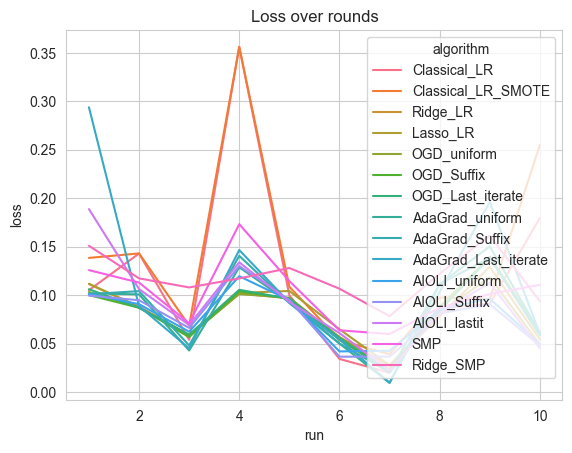

In [878]:
plot_results(well_specified_unbalanced_result)

In [880]:
# High Dimensional
high_dimensional_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    sim_balanced= False
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.902
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.913
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.866
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.912
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.931
Lasso LR was fit manually
Run 5 fi

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3875794382,0.0193950260
AIOLI_lastit,0.3758780229,0.0217508768
AIOLI_uniform,0.4286917149,0.0168416026
AdaGrad_Last_iterate,1.7896901657,0.8320043284
AdaGrad_Suffix,2.3812475105,0.8884940203
AdaGrad_uniform,3.0750628780,0.8397712388
Classical_LR,0.9491646781,0.2254649658
Classical_LR_SMOTE,0.8877084542,0.2082382857
Lasso_LR,0.3188703402,0.0498278233



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.5014864000,43.4803907000,43.9818771000,1.0621386149
AIOLI_lastit,0.5014864000,43.2150662000,43.7165526000,1.0015972401
AIOLI_uniform,0.5014864000,43.9965587000,44.4980451000,0.9249317804
AdaGrad_Last_iterate,0.0010065000,0.0000166000,0.0010231000,0.0001806678
AdaGrad_Suffix,0.0010065000,0.0000257000,0.0010322000,0.0001804609
AdaGrad_uniform,0.0010065000,0.0000268000,0.0010333000,0.0001804339
Classical_LR,0.0035725000,0.0000180000,0.0035905000,0.0004124287
Classical_LR_SMOTE,0.0052496000,0.0000093000,0.0052589000,0.0009035078
Lasso_LR,0.1520780000,0.0000084000,0.1520864000,0.0144889108


In [881]:
print_results(high_dimensional_unbalanced_result)

Total time: 0:22:54.262320

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3875794382,0.0193950260
AIOLI_lastit,0.3758780229,0.0217508768
AIOLI_uniform,0.4286917149,0.0168416026
AdaGrad_Last_iterate,1.7896901657,0.8320043284
AdaGrad_Suffix,2.3812475105,0.8884940203
AdaGrad_uniform,3.0750628780,0.8397712388
Classical_LR,0.9491646781,0.2254649658
Classical_LR_SMOTE,0.8877084542,0.2082382857
Lasso_LR,0.3188703402,0.0498278233



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.5014864000,43.4803907000,43.9818771000,1.0621386149
AIOLI_lastit,0.5014864000,43.2150662000,43.7165526000,1.0015972401
AIOLI_uniform,0.5014864000,43.9965587000,44.4980451000,0.9249317804
AdaGrad_Last_iterate,0.0010065000,0.0000166000,0.0010231000,0.0001806678
AdaGrad_Suffix,0.0010065000,0.0000257000,0.0010322000,0.0001804609
AdaGrad_uniform,0.0010065000,0.0000268000,0.0010333000,0.0001804339
Classical_LR,0.0035725000,0.0000180000,0.0035905000,0.0004124287
Classical_LR_SMOTE,0.0052496000,0.0000093000,0.0052589000,0.0009035078
Lasso_LR,0.1520780000,0.0000084000,0.1520864000,0.0144889108


Train set
    run_1         run_2  run_3  run_4  run_5  run_6         run_7  run_8  \
-1      1           NaN      1      3      1      1           NaN      4   
 1     19 20.0000000000     19     17     19     19 20.0000000000     16   

    run_9  run_10  
-1      1       2  
 1     19      18  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1     12     12     14      9      6      8            NaN     10      8   
 1     88     88     86     91     94     92 100.0000000000     90     92   

    run_10  
-1       7  
 1      93  


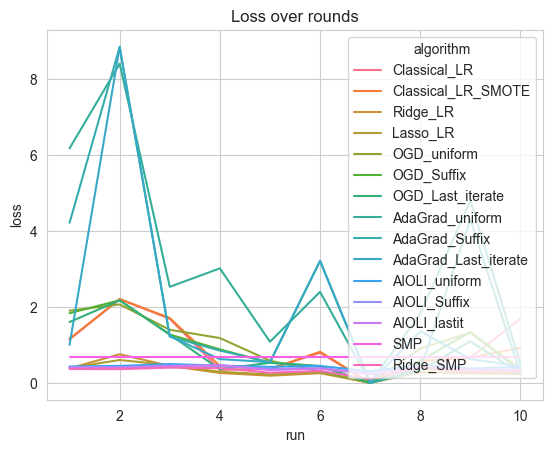

In [882]:
plot_results(high_dimensional_unbalanced_result, n = 20)

In [883]:
# High dimensionality
high_dimensionality_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 50,
    d = 25,
    sim_balanced = False
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.899
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.921
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.876
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.913
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.935
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3426943649,0.0220487457
AIOLI_lastit,0.3258013127,0.0224213329
AIOLI_uniform,0.3821415433,0.0186199939
AdaGrad_Last_iterate,1.3980023456,0.3511909800
AdaGrad_Suffix,1.0577960221,0.3141760454
AdaGrad_uniform,1.8760621018,0.4736502365
Classical_LR,2.5615144443,0.6048961895
Classical_LR_SMOTE,3.4876835744,0.9904816103
Lasso_LR,0.2901299499,0.0372188158



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,2.0663103000,155.3692288000,157.4355391000,4.5881651316
AIOLI_lastit,2.0663103000,155.3606052000,157.4269155000,4.2820649605
AIOLI_uniform,2.0663103000,156.8349087000,158.9012190000,5.0990699199
AdaGrad_Last_iterate,0.0034972000,0.0000144000,0.0035116000,0.0005924459
AdaGrad_Suffix,0.0034972000,0.0000260000,0.0035232000,0.0005955398
AdaGrad_uniform,0.0034972000,0.0000203000,0.0035175000,0.0005905709
Classical_LR,0.0051184000,0.0000183000,0.0051367000,0.0005116253
Classical_LR_SMOTE,0.0052611000,0.0000098000,0.0052709000,0.0003186430
Lasso_LR,0.1156537000,0.0000085000,0.1156622000,0.0070671936


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1     44     48     47     44     48     49     49     40     48      47
-1      6      2      3      6      2      1      1     10      2       3
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1     12     12     14      9      6      8            NaN     10      8   
 1     88     88     86     91     94     92 100.0000000000     90     92   

    run_10  
-1       7  
 1      93  


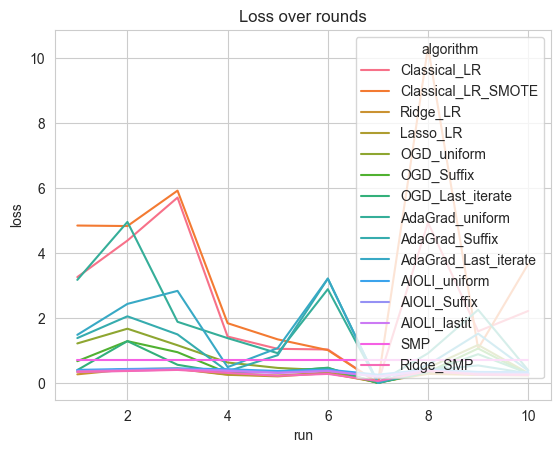

In [884]:
plot_results(high_dimensionality_unbalanced_result, n =50)

In [1151]:
# Sinusoidal
# sinusoidal_unbalanced = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3,
#     sim_balanced=False
# )
#
# sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
# print_results(sinusoidal_unbalanced_result)

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.398
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.356
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.484
Lasso LR was fit manua

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5632918914,0.0200435386
AIOLI_lastit,0.5781579460,0.0249661798
AIOLI_uniform,0.5472860110,0.0217334314
AdaGrad_Last_iterate,0.6340079466,0.0353428877
AdaGrad_Suffix,0.6053171569,0.0176767197
AdaGrad_uniform,0.6038636876,0.0141112831
Classical_LR,0.5574891492,0.0193289801
Classical_LR_SMOTE,0.6250320772,0.0258617753
Lasso_LR,0.5676805473,0.0176992476



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2661222000,26.7094429000,26.9755651000,1.8960936801
AIOLI_lastit,0.2661222000,27.1125672000,27.3786894000,2.3469189171
AIOLI_uniform,0.2661222000,24.9700291000,25.2361513000,1.4123081306
AdaGrad_Last_iterate,0.0015959000,0.0000148000,0.0016107000,0.0001785026
AdaGrad_Suffix,0.0015959000,0.0000209000,0.0016168000,0.0001785585
AdaGrad_uniform,0.0015959000,0.0000222000,0.0016181000,0.0001786618
Classical_LR,0.0026700000,0.0000218000,0.0026918000,0.0003059871
Classical_LR_SMOTE,0.0045705000,0.0000121000,0.0045826000,0.0020074334
Lasso_LR,0.0170266000,0.0000104000,0.0170370000,0.0028911397


Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1     65     62     68     80     77     64     76     66     80      71
-1     35     38     32     20     23     36     24     34     20      29
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1     66     67     70     75     78     67     77     65     81      75
-1     34     33     30     25     22     33     23     35     19      25


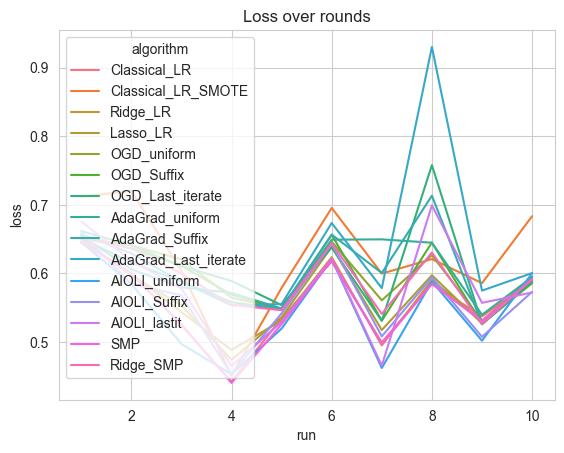

In [1152]:
# plot_results(sinusoidal_unbalanced_result, n = 100)

In [887]:
#Quadratic
quadratic_unbalanced = SimulationConfig(
    sim_setting = "quadratic",
    d = 3,
    sim_balanced= False
)

quadratic_unbalanced_result = run_simulation(quadratic_unbalanced)
print_results(quadratic_unbalanced_result)

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.876
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.88
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.872
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.884
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.884
Lasso LR was fit manually
Run 5 finished
100 (training) samples were g

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.1201348931,0.0176621415
AIOLI_lastit,0.1186001407,0.0167451347
AIOLI_uniform,0.1194863630,0.0170504974
AdaGrad_Last_iterate,0.1535286070,0.0262092977
AdaGrad_Suffix,0.1378878068,0.0220522664
AdaGrad_uniform,0.1383782164,0.0222197071
Classical_LR,0.2279782981,0.0792889810
Classical_LR_SMOTE,0.2547136716,0.0836874173
Lasso_LR,0.1147835573,0.0146656785



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3325836000,30.8169470000,31.1495306000,0.4276893468
AIOLI_lastit,0.3325836000,30.4369627000,30.7695463000,0.4019928707
AIOLI_uniform,0.3325836000,31.1409852000,31.4735688000,0.4644925233
AdaGrad_Last_iterate,0.0013140000,0.0000170000,0.0013310000,0.0002327467
AdaGrad_Suffix,0.0013140000,0.0000441000,0.0013581000,0.0002325299
AdaGrad_uniform,0.0013140000,0.0000271000,0.0013411000,0.0002326240
Classical_LR,0.0028911000,0.0000168000,0.0029079000,0.0002559514
Classical_LR_SMOTE,0.0036255000,0.0000100000,0.0036355000,0.0002471843
Lasso_LR,0.0226291000,0.0000086000,0.0226377000,0.0026617156


Train set
            run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1 100.0000000000     92     99     98     97     98     99     96     94   
 1            NaN      8      1      2      3      2      1      4      6   

    run_10  
-1      96  
 1       4  
Test set
    run_1  run_2  run_3  run_4          run_5  run_6  run_7  run_8  run_9  \
-1     95     98     97     96 100.0000000000     98     99     98     95   
 1      5      2      3      4            NaN      2      1      2      5   

    run_10  
-1      97  
 1       3  


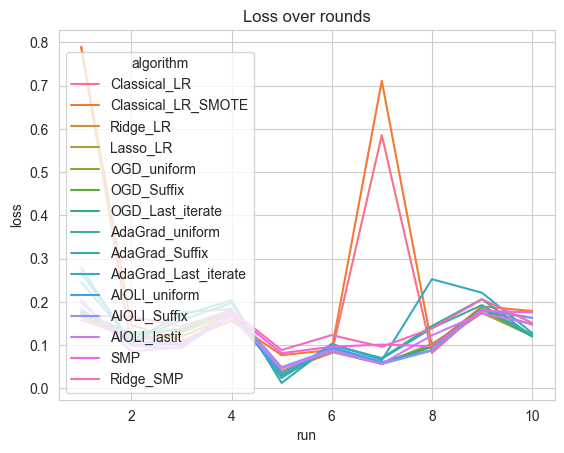

In [888]:
plot_results(quadratic_unbalanced_result)

In [889]:
# Sign
sign_unbalanced = SimulationConfig(
    sim_setting = "sign",
    n = 100,
    d = 3,
    sim_balanced = False
)

sign_unbalanced_result = run_simulation(sign_unbalanced)
print_results(sign_unbalanced_result)

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.98
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 6 finished
100 (training) sa

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0706693924,0.0090337555
AIOLI_lastit,0.0664280816,0.0086323792
AIOLI_uniform,0.0841250724,0.0092942622
AdaGrad_Last_iterate,0.0940602890,0.0180133709
AdaGrad_Suffix,0.1013030928,0.0184571612
AdaGrad_uniform,0.1012644093,0.0141288008
Classical_LR,0.1632169283,0.0974362682
Classical_LR_SMOTE,0.1395476636,0.0876451685
Lasso_LR,0.0696451332,0.0075835191



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2283150000,21.1103382000,21.3386532000,0.3391509841
AIOLI_lastit,0.2283150000,21.0378654000,21.2661804000,0.2561029280
AIOLI_uniform,0.2283150000,21.6315129000,21.8598279000,0.3462521079
AdaGrad_Last_iterate,0.0013615000,0.0000153000,0.0013768000,0.0002936758
AdaGrad_Suffix,0.0013615000,0.0000244000,0.0013859000,0.0002934623
AdaGrad_uniform,0.0013615000,0.0000263000,0.0013878000,0.0002932970
Classical_LR,0.0034054000,0.0000164000,0.0034218000,0.0002751628
Classical_LR_SMOTE,0.0032354000,0.0000107000,0.0032461000,0.0001595029
Lasso_LR,0.0201938000,0.0000099000,0.0202037000,0.0025867846


In [1128]:
# Hidden X
hidden_x_unbalanced = SimulationConfig(
    sim_setting = "hidden x",
    n = 100,
    d = 3,
    sim_balanced = False
)

hidden_x_unbalanced_result = run_simulation(hidden_x_unbalanced)
print_results(hidden_x_unbalanced_result)

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.895
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.919
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.868
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.911
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.933
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.903
Lasso LR was fit manually
Run 6 f

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.2883353469,0.0289309168
AIOLI_lastit,0.2884984580,0.0319705927
AIOLI_uniform,0.2778265334,0.0288528048
AdaGrad_Last_iterate,0.3058777705,0.0393190732
AdaGrad_Suffix,0.3028562973,0.0352971628
AdaGrad_uniform,0.3059855511,0.0401056038
Classical_LR,0.2807583174,0.0306641303
Classical_LR_SMOTE,0.3000412757,0.0331170412
Lasso_LR,0.2785171194,0.0309688794



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3037986000,26.9022988000,27.2060974000,0.5735226327
AIOLI_lastit,0.3037986000,28.9863528000,29.2901514000,1.5494571901
AIOLI_uniform,0.3037986000,26.8710269000,27.1748255000,0.6893841025
AdaGrad_Last_iterate,0.0011129000,0.0000116000,0.0011245000,0.0001227647
AdaGrad_Suffix,0.0011129000,0.0000181000,0.0011310000,0.0001225803
AdaGrad_uniform,0.0011129000,0.0000215000,0.0011344000,0.0001220932
Classical_LR,0.0030670000,0.0000370000,0.0031040000,0.0002218871
Classical_LR_SMOTE,0.0031369000,0.0000160000,0.0031529000,0.0002376167
Lasso_LR,0.0167005000,0.0000086000,0.0167091000,0.0023794291


In [1215]:
#Graph groups
settings_unbalanced_results = {
    "Well specified": well_specified_unbalanced_result,
    # "High Dimensional": high_dimensional_unbalanced_result,
    # "High Dimensionality": high_dimensionality_unbalanced_result,
    "Quadratic": quadratic_unbalanced_result,
    "Binomial X": binomial_unbalanced_result
}

settings_unbalanced_results2 = {
    # "Sinusoidal" : sinusoidal_unbalanced_result,
    "Sign" : sign_unbalanced_result,
    "Hidden X" : hidden_x_unbalanced_result
}

settings_unbalanced_results1 = {
    # "Well specified": well_specified_unbalanced_result,
    "High Dimensional": high_dimensional_unbalanced_result,
    "High Dimensionality": high_dimensionality_unbalanced_result,
    # "Quadratic": quadratic_unbalanced_result,
    # "Binomial X": binomial_unbalanced_result
}

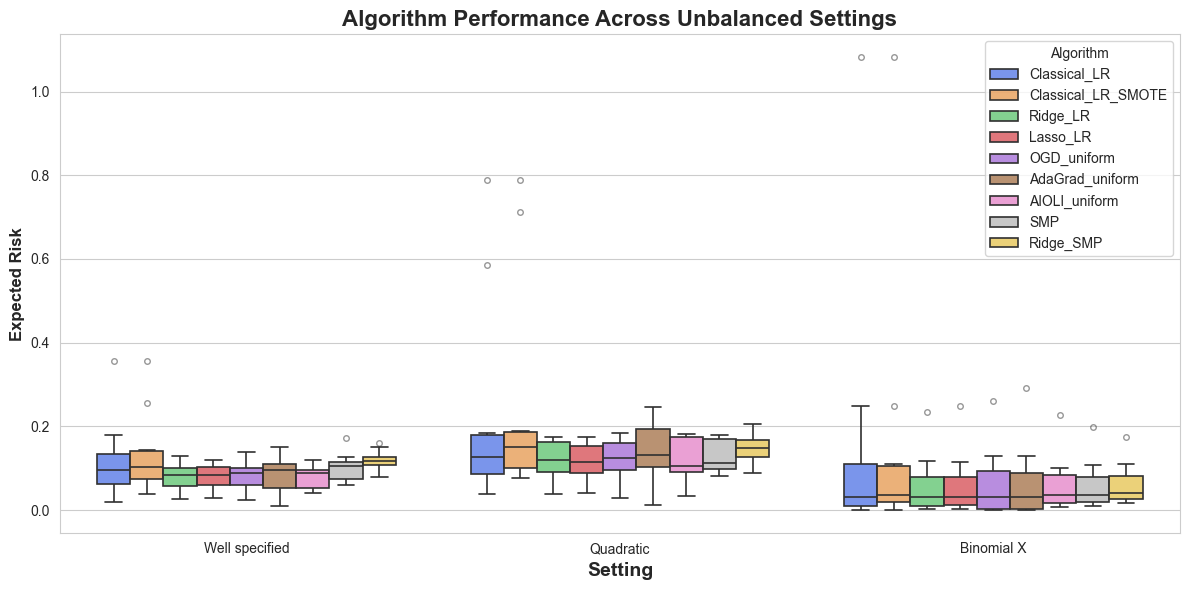

In [1216]:
compare_settings(
    settings_unbalanced_results,
    title = "Algorithm Performance Across Unbalanced Settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Lasso_LR","Ridge_LR","OGD_uniform","AIOLI_uniform","SMP","Ridge_SMP", "AdaGrad_uniform"]
)

In [1114]:
print_results(well_specified_unbalanced_result)

Total time: 0:15:31.855545

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0778745028,0.0096481768
AIOLI_lastit,0.0913966895,0.0150569310
AIOLI_uniform,0.0784823495,0.0086273263
AdaGrad_Last_iterate,0.1090602422,0.0264928703
AdaGrad_Suffix,0.0866160580,0.0127733833
AdaGrad_uniform,0.0849797623,0.0136303319
Classical_LR,0.1169532572,0.0305573171
Classical_LR_SMOTE,0.1356259599,0.0311252824
Lasso_LR,0.0806260077,0.0094500287



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3101330000,30.3562325000,30.6663655000,0.3908618333
AIOLI_lastit,0.3101330000,30.4364114000,30.7465444000,0.4238944872
AIOLI_uniform,0.3101330000,30.7835234000,31.0936564000,0.4567701692
AdaGrad_Last_iterate,0.0012421000,0.0000114000,0.0012535000,0.0001695412
AdaGrad_Suffix,0.0012421000,0.0000172000,0.0012593000,0.0001702331
AdaGrad_uniform,0.0012421000,0.0000188000,0.0012609000,0.0001703990
Classical_LR,0.0031945000,0.0000193000,0.0032138000,0.0001863398
Classical_LR_SMOTE,0.0032866000,0.0000126000,0.0032992000,0.0002909192
Lasso_LR,0.0171534000,0.0000110000,0.0171644000,0.0020439088


In [1133]:
print_results(quadratic_unbalanced_result)

Total time: 0:15:40.419800

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.1201348931,0.0176621415
AIOLI_lastit,0.1186001407,0.0167451347
AIOLI_uniform,0.1194863630,0.0170504974
AdaGrad_Last_iterate,0.1535286070,0.0262092977
AdaGrad_Suffix,0.1378878068,0.0220522664
AdaGrad_uniform,0.1383782164,0.0222197071
Classical_LR,0.2279782981,0.0792889810
Classical_LR_SMOTE,0.2547136716,0.0836874173
Lasso_LR,0.1147835573,0.0146656785



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3325836000,30.8169470000,31.1495306000,0.4276893468
AIOLI_lastit,0.3325836000,30.4369627000,30.7695463000,0.4019928707
AIOLI_uniform,0.3325836000,31.1409852000,31.4735688000,0.4644925233
AdaGrad_Last_iterate,0.0013140000,0.0000170000,0.0013310000,0.0002327467
AdaGrad_Suffix,0.0013140000,0.0000441000,0.0013581000,0.0002325299
AdaGrad_uniform,0.0013140000,0.0000271000,0.0013411000,0.0002326240
Classical_LR,0.0028911000,0.0000168000,0.0029079000,0.0002559514
Classical_LR_SMOTE,0.0036255000,0.0000100000,0.0036355000,0.0002471843
Lasso_LR,0.0226291000,0.0000086000,0.0226377000,0.0026617156


In [1134]:
print_results(binomial_unbalanced_result)

Total time: 0:04:28.237196

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0601180068,0.0238328641
AIOLI_lastit,0.0617171035,0.0247552342
AIOLI_uniform,0.0599822723,0.0215215287
AdaGrad_Last_iterate,0.0730466860,0.0311139052
AdaGrad_Suffix,0.0670897041,0.0301713142
AdaGrad_uniform,0.0660907958,0.0291035393
Classical_LR,0.1619030294,0.1051424864
Classical_LR_SMOTE,0.1655825936,0.1045460884
Lasso_LR,0.0610576599,0.0241844917



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0939936000,9.0559942000,9.1499878000,0.5020197662
AIOLI_lastit,0.0939936000,8.4650866000,8.5590802000,0.1286370612
AIOLI_uniform,0.0939936000,8.5152818000,8.6092754000,0.0776134898
AdaGrad_Last_iterate,0.0012011000,0.0000097000,0.0012108000,0.0002736655
AdaGrad_Suffix,0.0012011000,0.0000148000,0.0012159000,0.0002740937
AdaGrad_uniform,0.0012011000,0.0000155000,0.0012166000,0.0002739617
Classical_LR,0.0019570000,0.0000221000,0.0019791000,0.0004715651
Classical_LR_SMOTE,0.0014349000,0.0000140000,0.0014489000,0.0002069253
Lasso_LR,0.0014784000,0.0000125000,0.0014909000,0.0001750582


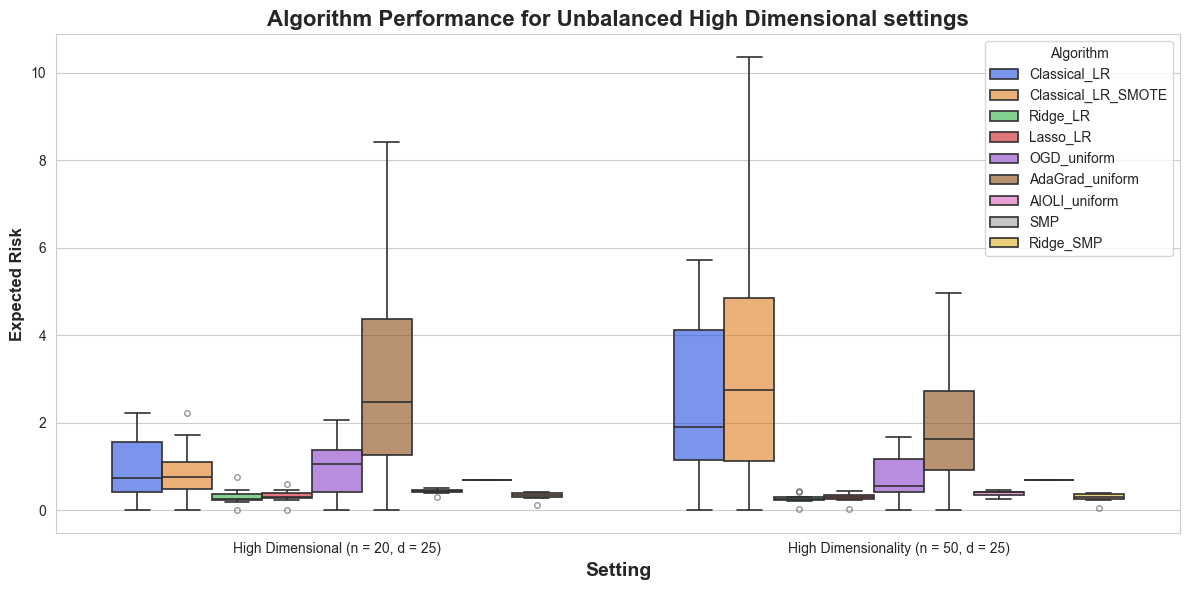

In [1218]:
compare_settings(
    settings_unbalanced_results1,
    title = "Algorithm Performance for Unbalanced High Dimensional settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

In [1117]:
print_results(high_dimensional_unbalanced_result)

Total time: 0:22:54.262320

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3875794382,0.0193950260
AIOLI_lastit,0.3758780229,0.0217508768
AIOLI_uniform,0.4286917149,0.0168416026
AdaGrad_Last_iterate,1.7896901657,0.8320043284
AdaGrad_Suffix,2.3812475105,0.8884940203
AdaGrad_uniform,3.0750628780,0.8397712388
Classical_LR,0.9491646781,0.2254649658
Classical_LR_SMOTE,0.8877084542,0.2082382857
Lasso_LR,0.3188703402,0.0498278233



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.5014864000,43.4803907000,43.9818771000,1.0621386149
AIOLI_lastit,0.5014864000,43.2150662000,43.7165526000,1.0015972401
AIOLI_uniform,0.5014864000,43.9965587000,44.4980451000,0.9249317804
AdaGrad_Last_iterate,0.0010065000,0.0000166000,0.0010231000,0.0001806678
AdaGrad_Suffix,0.0010065000,0.0000257000,0.0010322000,0.0001804609
AdaGrad_uniform,0.0010065000,0.0000268000,0.0010333000,0.0001804339
Classical_LR,0.0035725000,0.0000180000,0.0035905000,0.0004124287
Classical_LR_SMOTE,0.0052496000,0.0000093000,0.0052589000,0.0009035078
Lasso_LR,0.1520780000,0.0000084000,0.1520864000,0.0144889108


In [1118]:
print_results(high_dimensionality_unbalanced_result)

Total time: 1:19:23.936093

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3426943649,0.0220487457
AIOLI_lastit,0.3258013127,0.0224213329
AIOLI_uniform,0.3821415433,0.0186199939
AdaGrad_Last_iterate,1.3980023456,0.3511909800
AdaGrad_Suffix,1.0577960221,0.3141760454
AdaGrad_uniform,1.8760621018,0.4736502365
Classical_LR,2.5615144443,0.6048961895
Classical_LR_SMOTE,3.4876835744,0.9904816103
Lasso_LR,0.2901299499,0.0372188158



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,2.0663103000,155.3692288000,157.4355391000,4.5881651316
AIOLI_lastit,2.0663103000,155.3606052000,157.4269155000,4.2820649605
AIOLI_uniform,2.0663103000,156.8349087000,158.9012190000,5.0990699199
AdaGrad_Last_iterate,0.0034972000,0.0000144000,0.0035116000,0.0005924459
AdaGrad_Suffix,0.0034972000,0.0000260000,0.0035232000,0.0005955398
AdaGrad_uniform,0.0034972000,0.0000203000,0.0035175000,0.0005905709
Classical_LR,0.0051184000,0.0000183000,0.0051367000,0.0005116253
Classical_LR_SMOTE,0.0052611000,0.0000098000,0.0052709000,0.0003186430
Lasso_LR,0.1156537000,0.0000085000,0.1156622000,0.0070671936


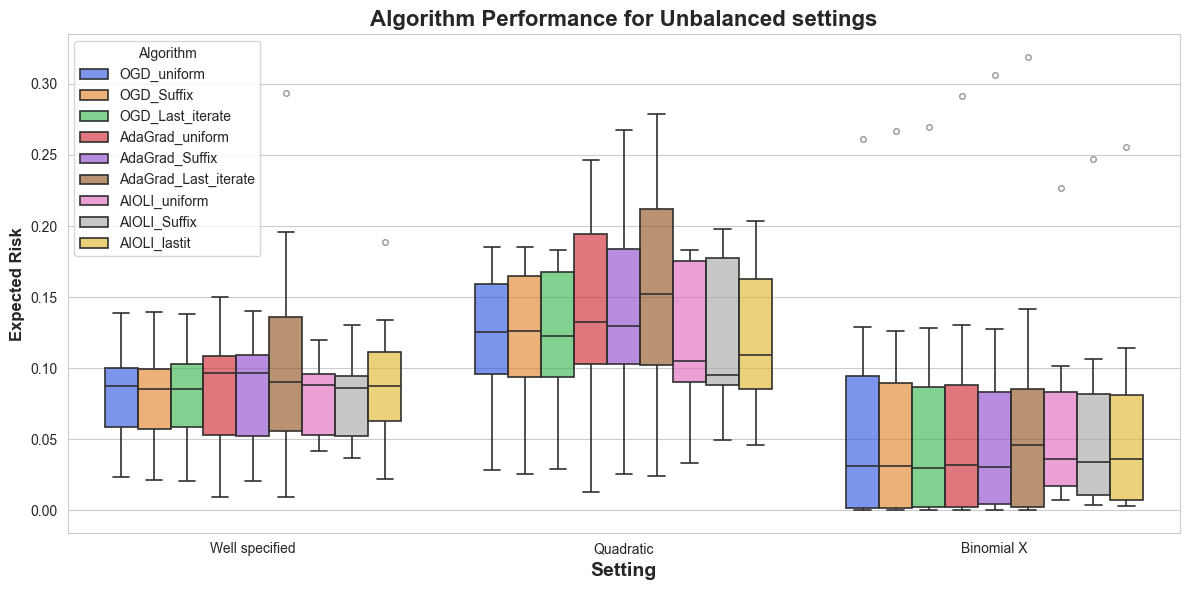

In [1221]:
# FOR AVERAGING STRATEGIES PART
compare_settings(
    settings_unbalanced_results,
    title = "Algorithm Performance for Unbalanced settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

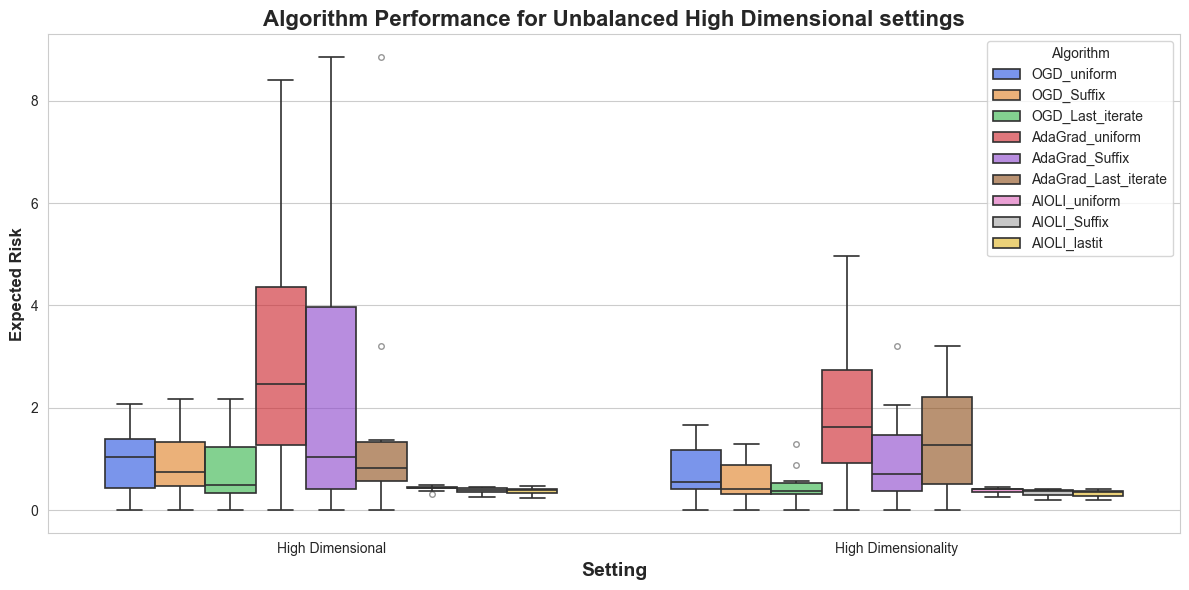

In [1222]:
# FOR AVERAGING STRATEGIES PART
compare_settings(
    settings_unbalanced_results1,
    title = "Algorithm Performance for Unbalanced High Dimensional settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

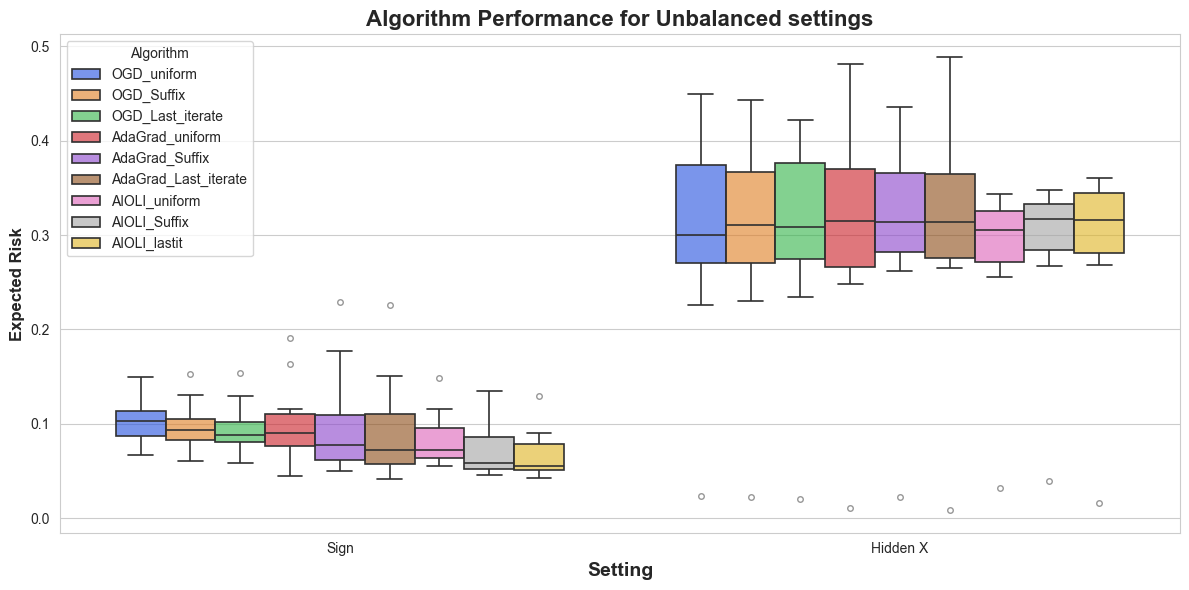

In [1223]:
# FOR AVERAGING STRATEGIES PART
compare_settings(
    settings_unbalanced_results2,
    title = "Algorithm Performance for Unbalanced settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

## High dimensional behaviour of LR

In [1014]:
def HD_run_simulation(cfg: SimulationConfig = None, B_hazan = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    minimize_method = cfg.minimize_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    X_hazan = cfg.X_hazan
    sim_betas = cfg.sim_betas

    test_set_results = []
    time_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             X_hazan = X_hazan,
                                                             betas = sim_betas,
                                                            B_hazan = B_hazan)

        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()


        def time_it(fn):
            """Runs fn(), returns (result, elapsed_seconds)."""
            t0 = datetime.datetime.now()
            result = fn()
            return result, (datetime.datetime.now() - t0).total_seconds()

        # ── Fit ──────────────────────────────────────────────────────────────

        classic_LR,    t_clr_fit        = time_it(lambda: classic_logistic_regression(data_x=x_train, data_y=y_train))
        ridge_LR,      t_ridge_fit      = time_it(lambda: ridge_logistic_regression(data_x=x_train, data_y=y_train))
        lasso_LR,      t_lasso_fit      = time_it(lambda: lasso_logistic_regression(data_x=x_train, data_y=y_train))
        smp,           t_smp_fit        = time_it(lambda: sample_minmax_predictor(x_train, y_train))



        loss_LR_test,       t_clr_loss       = time_it(lambda: log_loss(classic_LR["Batch_estimate"],       x_test, y_test))

        loss_LR_Ridge_test, t_ridge_loss     = time_it(lambda: log_loss(ridge_LR["Batch_estimate"],         x_test, y_test))
        loss_LR_Lasso_test, t_lasso_loss     = time_it(lambda: log_loss(lasso_LR["Batch_estimate"],         x_test, y_test))

        smp_result,       t_smp_loss      = time_it(lambda: smp.get_new_loss(x_test, y_test))

        # ── Collate results ───────────────────────────────────────────────────
        algorithms_test = {
            "Classical_LR":         {"loss": loss_LR_test,              "time_fit": t_clr_fit,       "time_loss": t_clr_loss},

            "Ridge_LR":             {"loss": loss_LR_Ridge_test,         "time_fit": t_ridge_fit,     "time_loss": t_ridge_loss},
            "Lasso_LR":             {"loss": loss_LR_Lasso_test,         "time_fit": t_lasso_fit,     "time_loss": t_lasso_loss},
            "SMP":                  {"loss": smp_result["loss"],         "time_fit": t_smp_fit,       "time_loss": t_smp_loss},
        }

        for name, metrics in algorithms_test.items():
            row = {"run": i + 1, "algorithm": name, **metrics}
            row["time_total"] = row["time_fit"] + row["time_loss"]
            test_set_results.append(row)

        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    total_time = (endtime - start_time).total_seconds()

    results_df = pd.DataFrame(test_set_results)

    return {
        "test_results":    results_df[["run", "algorithm", "loss"]],
        "time_results":    results_df[["run", "algorithm", "time_fit", "time_loss", "time_total"]],
        "y_counts_train":  pd.DataFrame(y_counts),
        "y_train_df":      pd.DataFrame(all_y_trains),
        "y_test_df":       pd.DataFrame(all_y_tests),
        "total_time":      total_time,
    }

In [1015]:
high_dimensional_n125 = SimulationConfig(
    sim_setting = "high dimensional",
    n = 125,
    d = 25
)
high_dimensional_n125_result = HD_run_simulation(high_dimensional_n125)
print_results(high_dimensional_n125_result)

125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.481
Lasso LR was fit manually
Run 1 finished
125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.489
Lasso LR was fit manually
Run 2 finished
125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 3 finished
125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.537
Lasso LR was fit manually
Run 4 finished
125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.546
Lasso LR was fit manually
Run 5 finished
125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) 

,Average_Loss,SE_Loss
algorithm,,
Classical_LR,376.9884763218,255.8471150579
Lasso_LR,0.4661476225,0.0193330360
Ridge_LR,0.4525486401,0.0176236093
SMP,0.4621730435,0.0149569706



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
Classical_LR,0.0261072000,0.0015573000,0.0276645000,0.0077597807
Lasso_LR,0.3483303000,0.0000315000,0.3483618000,0.0665937645
Ridge_LR,0.0062622000,0.0000358000,0.0062980000,0.0010629630
SMP,0.0000754000,33.7355078000,33.7355832000,5.6436526693


In [1016]:
high_dimensional_n150 = SimulationConfig(
    sim_setting = "high dimensional",
    n = 150,
    d = 25
)
high_dimensional_n150_result = HD_run_simulation(high_dimensional_n150)
print_results(high_dimensional_n150_result)

150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.488
Lasso LR was fit manually
Run 1 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492
Lasso LR was fit manually
Run 2 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 3 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.54
Lasso LR was fit manually
Run 4 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.54
Lasso LR was fit manually
Run 5 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of

,Average_Loss,SE_Loss
algorithm,,
Classical_LR,0.6300953444,0.0742103188
Lasso_LR,0.4473631263,0.0216021392
Ridge_LR,0.4379725395,0.0195018599
SMP,0.4336449988,0.0152884944



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
Classical_LR,0.0203067000,0.0000648000,0.0203715000,0.0025622944
Lasso_LR,0.2432187000,0.0000217000,0.2432404000,0.0275674613
Ridge_LR,0.0078574000,0.0000232000,0.0078806000,0.0019447342
SMP,0.0000039000,26.4431120000,26.4431159000,2.4978269858


In [1031]:
high_dimensional_n175 = SimulationConfig(
    sim_setting = "high dimensional",
    n = 175,
    d = 25
)
high_dimensional_n175_result = HD_run_simulation(high_dimensional_n175)
print_results(high_dimensional_n175_result)

175 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.477
Lasso LR was fit manually
Run 1 finished
175 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.498
Lasso LR was fit manually
Run 2 finished
175 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.498
Lasso LR was fit manually
Run 3 finished
175 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.535
Lasso LR was fit manually
Run 4 finished
175 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.52
Lasso LR was fit manually
Run 5 finished
175 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) o

,Average_Loss,SE_Loss
algorithm,,
Classical_LR,0.5126881824,0.0462458296
Lasso_LR,0.4330594862,0.0215517113
Ridge_LR,0.4271743617,0.0194923818
SMP,0.4216701043,0.0193295070



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
Classical_LR,0.0172795000,0.0000223000,0.0173018000,0.0035996672
Lasso_LR,0.2843022000,0.0000233000,0.2843255000,0.0772671408
Ridge_LR,0.0060674000,0.0000548000,0.0061222000,0.0009302258
SMP,0.0000030000,19.5360433000,19.5360463000,2.8349658128


## Changing n

In [893]:
# hazan_small_n = simulations_changing_n([10,20,60], hazan, filename = "hazan_small_n")

In [894]:
# hazan_small_n[1]

In [895]:
# plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_small_n[1])

In [896]:
# hazan_changing_n_new = simulations_changing_n([20,30], hazan, filename = "hazan_changing_n")

In [897]:
# plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n_new[1], title= "Algorithm performance vs Sample size in adversarial distribution of Hazan")

In [898]:
hazan_changing_n = simulations_changing_n([20,50,100,200,300], hazan, filename = "hazan_changing_n")


Running simulations for n = 20

20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.0600000000

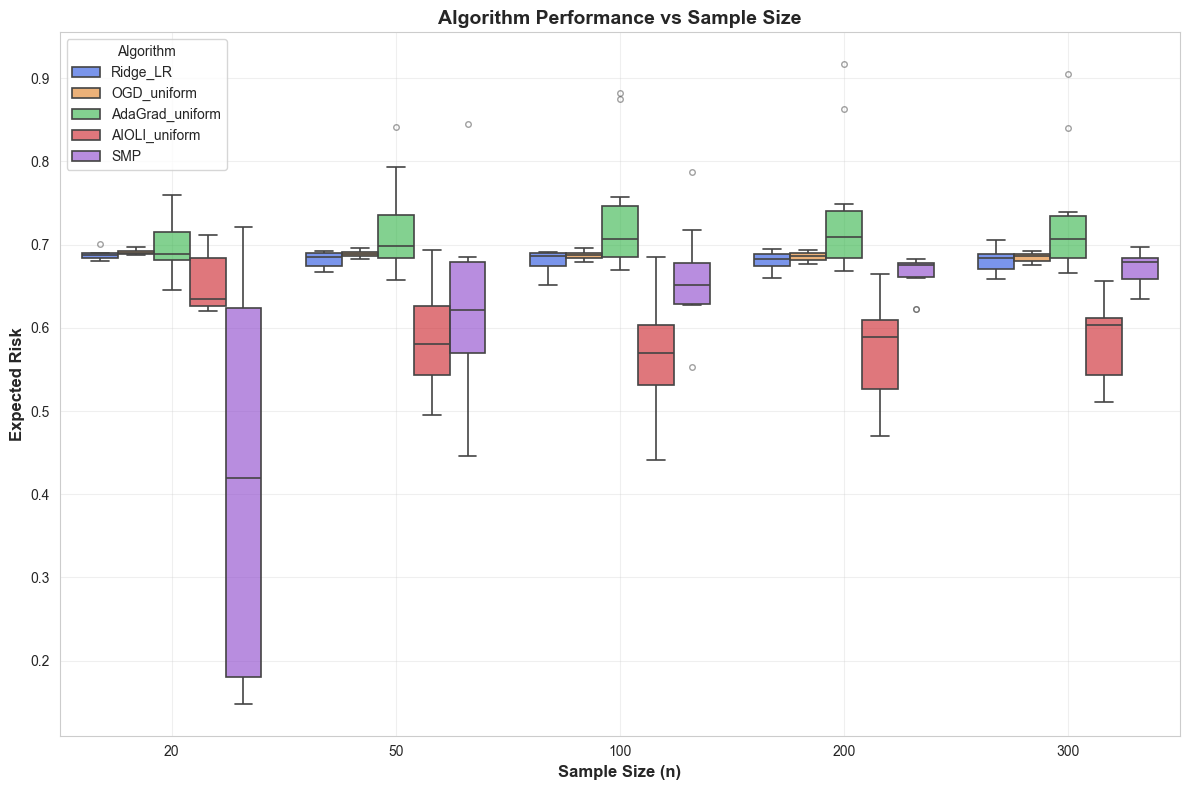

In [1224]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n[1])

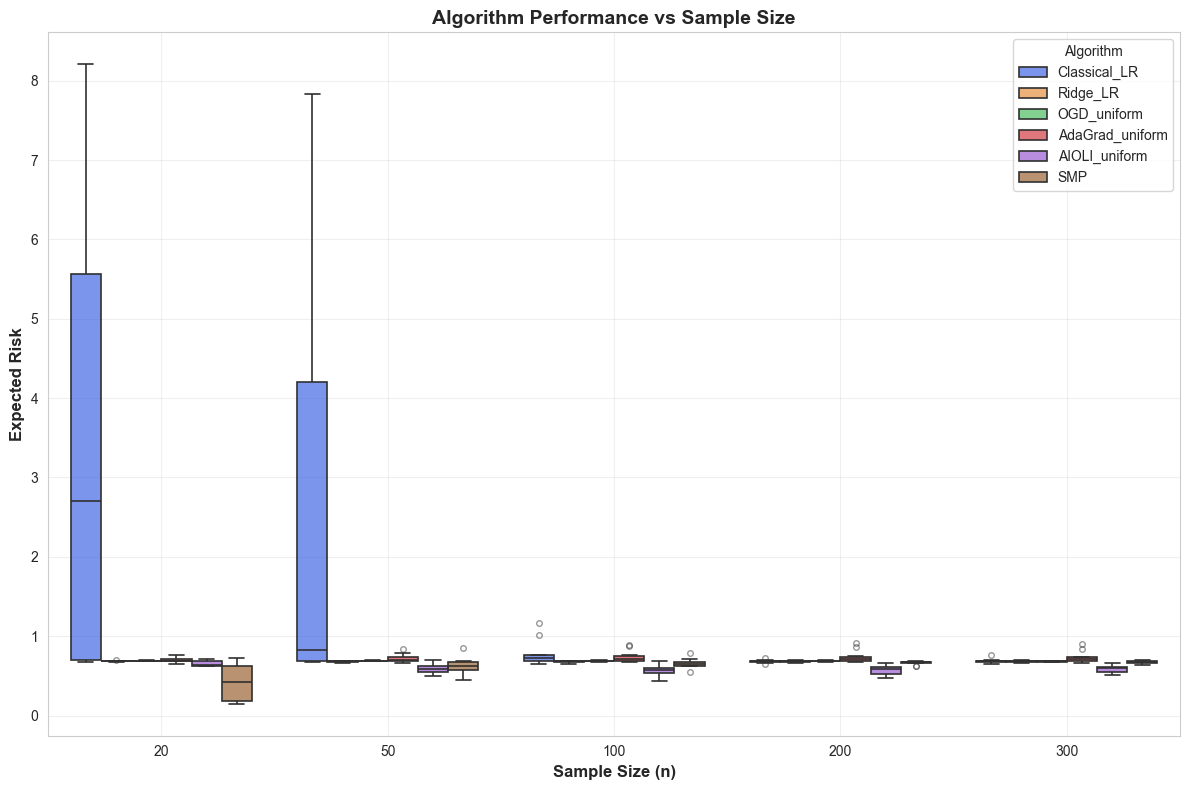

In [1225]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_changing_n[1])

In [1234]:
hazanLR = hazan_changing_n[1]
hazanLR[hazanLR["algorithm"] == "Classical_LR"]

,run,algorithm,loss,n
0,1,Classical_LR,0.6700566728,20
15,2,Classical_LR,4.6900754552,20
30,3,Classical_LR,5.8625932282,20
45,4,Classical_LR,8.2076287742,20
60,5,Classical_LR,4.6900754552,20
75,6,Classical_LR,7.0351110012,20
90,7,Classical_LR,0.7141111534,20
105,8,Classical_LR,0.7023394768,20
120,9,Classical_LR,0.7023394768,20
135,10,Classical_LR,0.7023394768,20


In [901]:
#high_dimensional_changing_n = simulations_changing_n([10,50,100], high_dimensional, filename = "high_dimensional_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.509
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.494
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.504
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.569
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.537
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the high dimension

In [902]:
# high_dimensional_changing_n

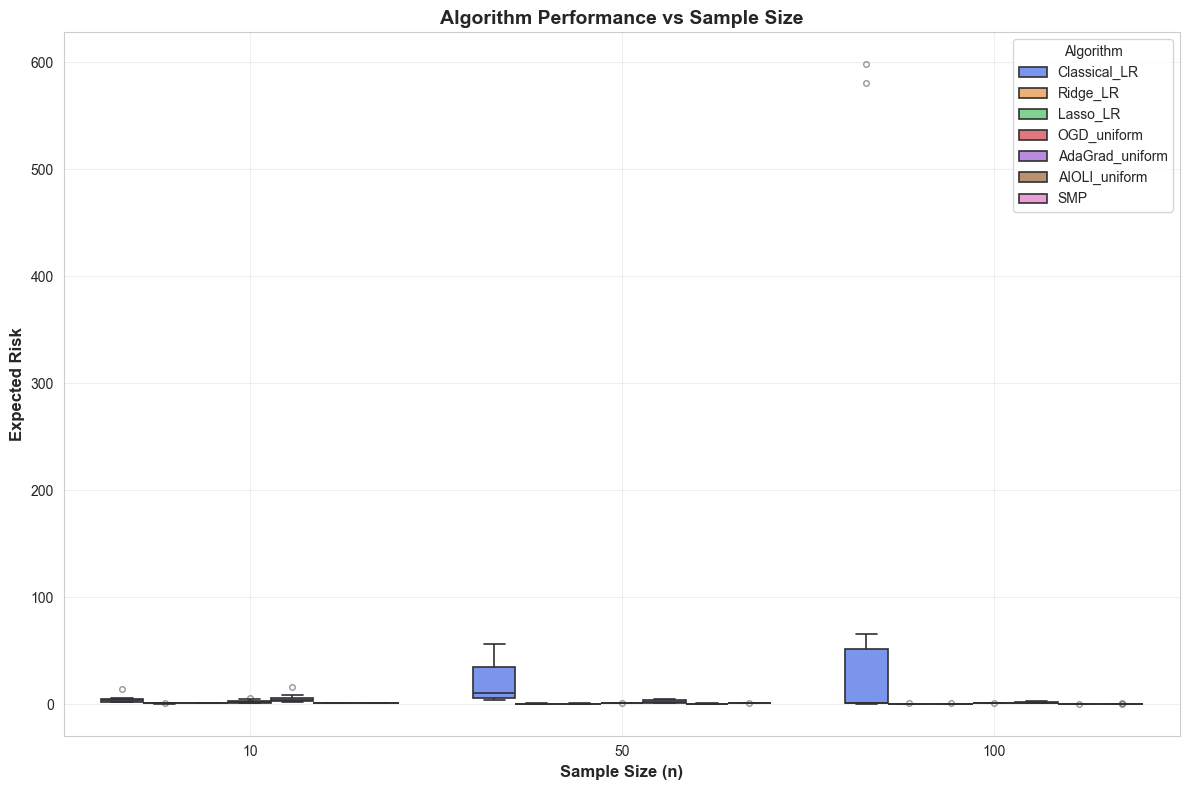

In [1235]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_changing_n[1])

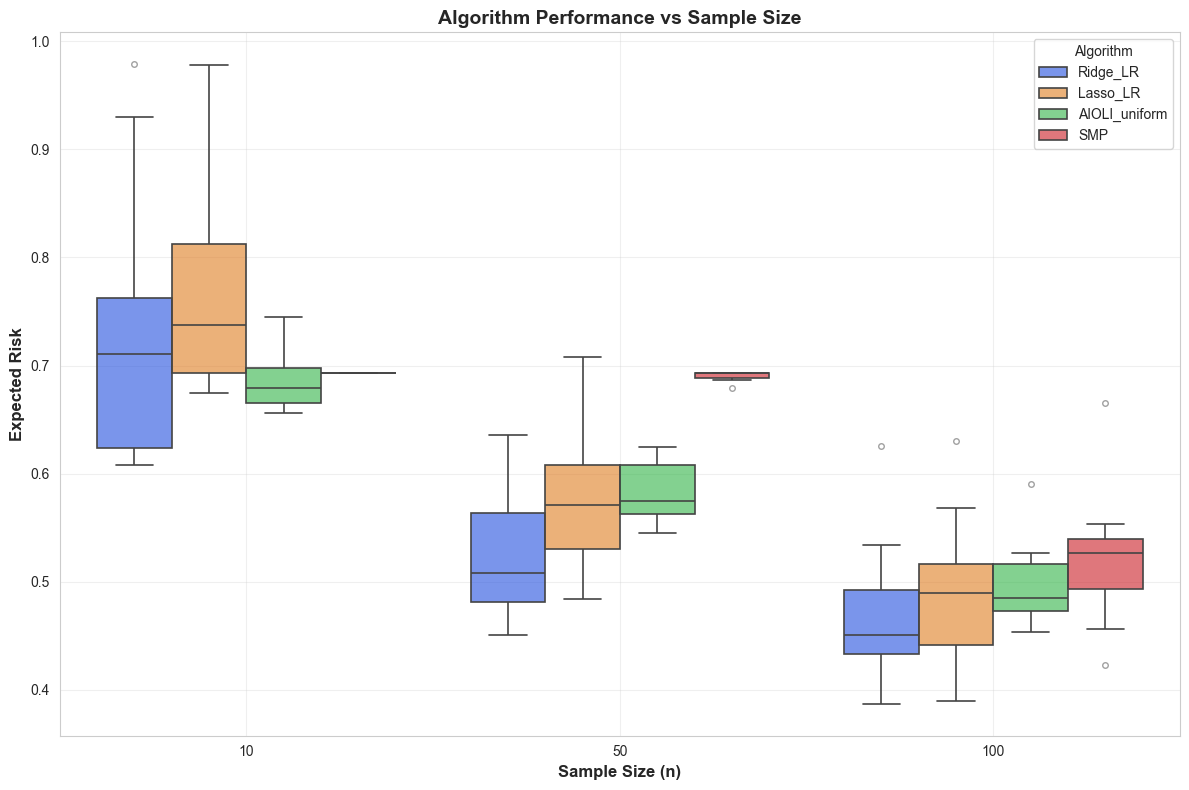

In [904]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_changing_n[1])

In [927]:
high_dimensional_changing_n[1].to_csv(f"high_dimensional_n10n50n100.csv")

In [930]:
high_dimensional_changing_n[1]

,run,algorithm,loss,n
0,1,Classical_LR,1.7857019499,10
1,1,Classical_LR_SMOTE,1.7857019499,10
2,1,Ridge_LR,0.6265762229,10
3,1,Lasso_LR,0.6931471806,10
4,1,OGD_uniform,2.2760607086,10
...,...,...,...,...
445,10,AIOLI_uniform,0.5211275353,100
446,10,AIOLI_Suffix,0.4969909499,100
447,10,AIOLI_lastit,0.5023943202,100
448,10,SMP,0.5172493559,100


In [1032]:
hd_n20 = high_dimensional_result["test_results"]
hd_n20["n"] = 20
hd_n75 = high_dimensionality_higher_n_result["test_results"]
hd_n75["n"] = 75
hd_n125 = high_dimensional_n125_result["test_results"]
hd_n125["n"] = 125
hd_n150 = high_dimensional_n150_result["test_results"]
hd_n150["n"] = 150
hd_n175 = high_dimensional_n175_result["test_results"]
hd_n175["n"] = 175
hd_all_n =  pd.concat([high_dimensional_changing_n[1], hd_n20,hd_n75, hd_n125,hd_n150,hd_n175], ignore_index=True)
hd_all_n = hd_all_n.sort_values("n")

In [925]:
high_dimensional_all_n = pd.read_csv("high_dimensional_changing_n_copy.csv")

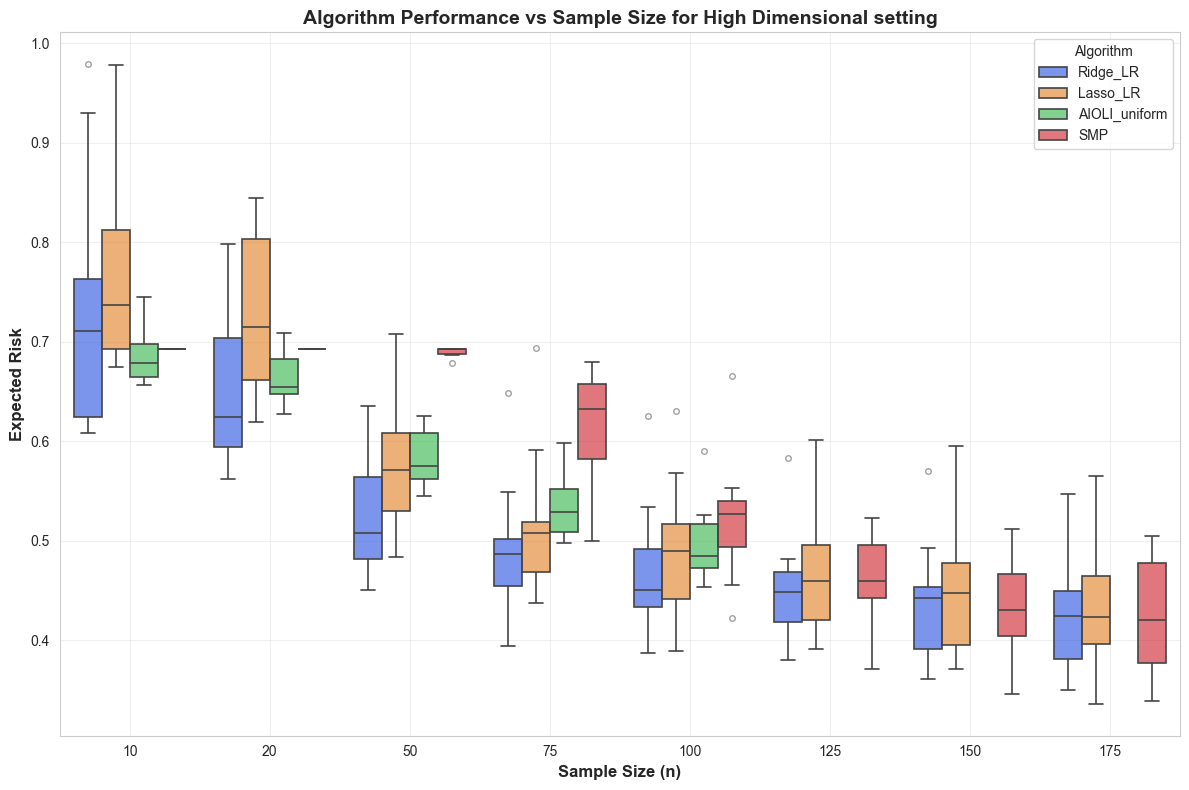

In [1236]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= hd_all_n, title = "Algorithm Performance vs Sample Size for High Dimensional setting")

In [965]:
hd_all_n.to_csv("hd_all_n.csv")

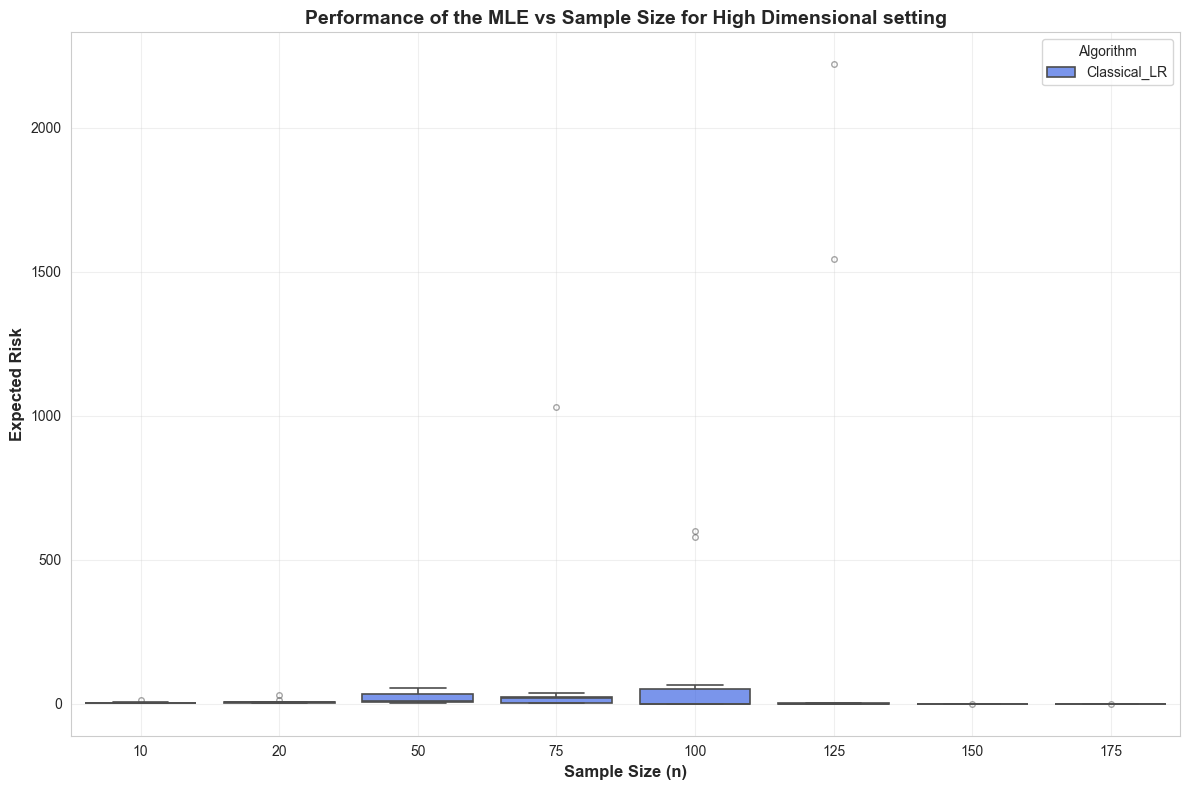

In [1237]:
plot_simulation_results(algorithms = ["Classical_LR"] ,raw_data= hd_all_n, title = "Performance of the MLE vs Sample Size for High Dimensional setting")

In [1033]:
HD_LR = hd_all_n[hd_all_n["algorithm"] == "Classical_LR"]

In [1238]:
summary_HD_LR = (
    HD_LR
    .groupby("n")["loss"]
    .agg(["mean", "median", "std", "min", "max",
         lambda x: x.quantile(0.25),
         lambda x: x.quantile(0.75)])
)
summary_HD_LR.columns = ["mean", "median", "std", "min", "max", "Q25","Q75"]

In [1239]:
summary_HD_LR

,mean,median,std,min,max,Q25,Q75
n,,,,,,,
10,4.4818618993,4.0755161958,3.5377993956,1.7857019499,13.7612630003,2.0793110336,4.6260814246
20,7.9199538214,5.0550292422,8.6594778117,2.4687117162,30.9293835625,3.4083708926,6.7087613332
50,20.8518652308,10.4794975616,19.2318685799,3.4613854834,55.8823801123,5.7320671066,34.3741033454
75,116.7747227992,18.9031160320,321.5122033507,1.3292814724,1031.1196737098,3.1714102287,24.5216476248
100,125.8570389311,0.9709309085,245.1627565386,0.5691197394,598.1620595519,0.8584412533,51.3600378268
125,376.9884763218,0.6448128488,809.0596163662,0.4140345735,2219.5237402756,0.5605907615,1.3719123382
150,0.6300953444,0.5587041150,0.2346736332,0.3975776248,1.2003012495,0.5119898346,0.6945303101
175,0.5126881824,0.4939572114,0.1462421538,0.3465088835,0.8529491476,0.4325978553,0.5646847900


In [1020]:
high_dimensional_n150_result["test_results"]

,run,algorithm,loss,n
0,1,Classical_LR,0.5107302579,150
1,1,Ridge_LR,0.3910824789,150
2,1,Lasso_LR,0.3743053546,150
3,1,SMP,0.3975805266,150
4,2,Classical_LR,0.7222649531,150
5,2,Ridge_LR,0.4419374669,150
6,2,Lasso_LR,0.4730561380,150
7,2,SMP,0.4396524354,150
8,3,Classical_LR,0.3975776248,150
9,3,Ridge_LR,0.3612923411,150


In [1011]:
a,b,c,d = generate_data("high dimensional", balanced = True, n =75,seed = 34)
print(sum(b == 1)/len(b))
print(sum(d == 1)/len(d))

75 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.477
0.4
0.53


In [1012]:
logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=1000)
lr_result = logreg.fit(a, b)
lr_result.coef_

array([[ 373.9684,   92.4395, -297.9105,    8.2098,  210.5669,  -66.7888,
        -102.7812, -150.8643,  357.3977,  -43.3996,  173.779 ,   23.2063,
        -223.2778,  171.794 ,  -97.9393,  121.6848, -263.7454,  337.177 ,
         317.3878,   43.9074,  -64.7696,  133.3352,  241.9932,    8.9487,
        -265.4524]])

In [1013]:
classic_logistic_regression(a,b)["Batch_estimate"]

array([ 373.9684,   92.4395, -297.9105,    8.2098,  210.5669,  -66.7888,
       -102.7812, -150.8643,  357.3977,  -43.3996,  173.779 ,   23.2063,
       -223.2778,  171.794 ,  -97.9393,  121.6848, -263.7454,  337.177 ,
        317.3878,   43.9074,  -64.7696,  133.3352,  241.9932,    8.9487,
       -265.4524])

array([[-1.5624, -1.6591, -1.4224, ..., -1.7314, -1.6827, -1.5979],
       [ 1.7801,  1.9194,  1.9346, ...,  2.5443,  1.9629,  2.2649],
       [ 0.8127,  1.5064,  0.2057, ...,  0.4394,  0.8136,  0.6265],
       ...,
       [ 2.2076,  2.3062,  2.428 , ...,  2.3877,  2.429 ,  2.4286],
       [ 1.7198,  1.4131,  1.5828, ...,  2.2086,  2.1545,  2.1165],
       [ 2.9878,  3.0254,  2.956 , ...,  2.6768,  3.4746,  3.2963]],
      shape=(25, 75))

In [971]:

def plot_xy_dimensions(X, y, figsize=(14, 4), title="Feature vs Label "):
    """
    X: numpy array of shape (n, d)
    y: numpy array of shape (n,1)
    """

    X = np.asarray(X)
    y = np.asarray(y)

    n, d = X.shape
    fig, axes = plt.subplots(1, d, figsize=figsize)

    # Convert labels to colors
    palette = {1: "steelblue", -1: "darkred"}

    for j in range(d):
        ax = axes[j]
        sns.scatterplot(
            x=X[:, j],
            y=y,
            hue=y,
            palette=palette,
            ax=ax,
            s=40,
            alpha=0.8,
            legend=(j == d - 1)  # only show legend on last subplot
        )
        ax.set_xlabel(f"X[:, {j}]")
        ax.set_ylabel("y")
        ax.set_title(f"Dimension {j}")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()


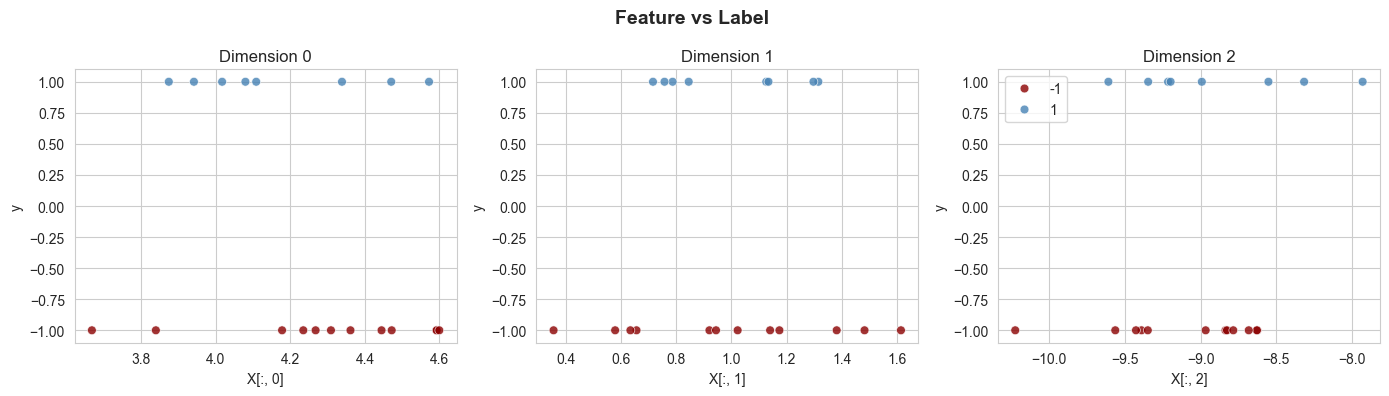

In [974]:
plot_xy_dimensions(a[:,3:6],b)

In [906]:
# high_dimensional_large_n = SimulationConfig(
#     sim_setting = "high dimensional",
#     n = 20,
#     d = 25,
#     runs = 10
# )

In [907]:
# high_dimensional_large_n = simulations_changing_n([150,200], high_dimensional_large_n, filename = "high_dimensional_large_n")

In [908]:
# plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_large_n[1])

In [909]:
# plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_large_n[1])

In [910]:
# well_specified_changing_n = simulations_changing_n([10,50,100], well_specified, filename = "well_specified_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.513
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable

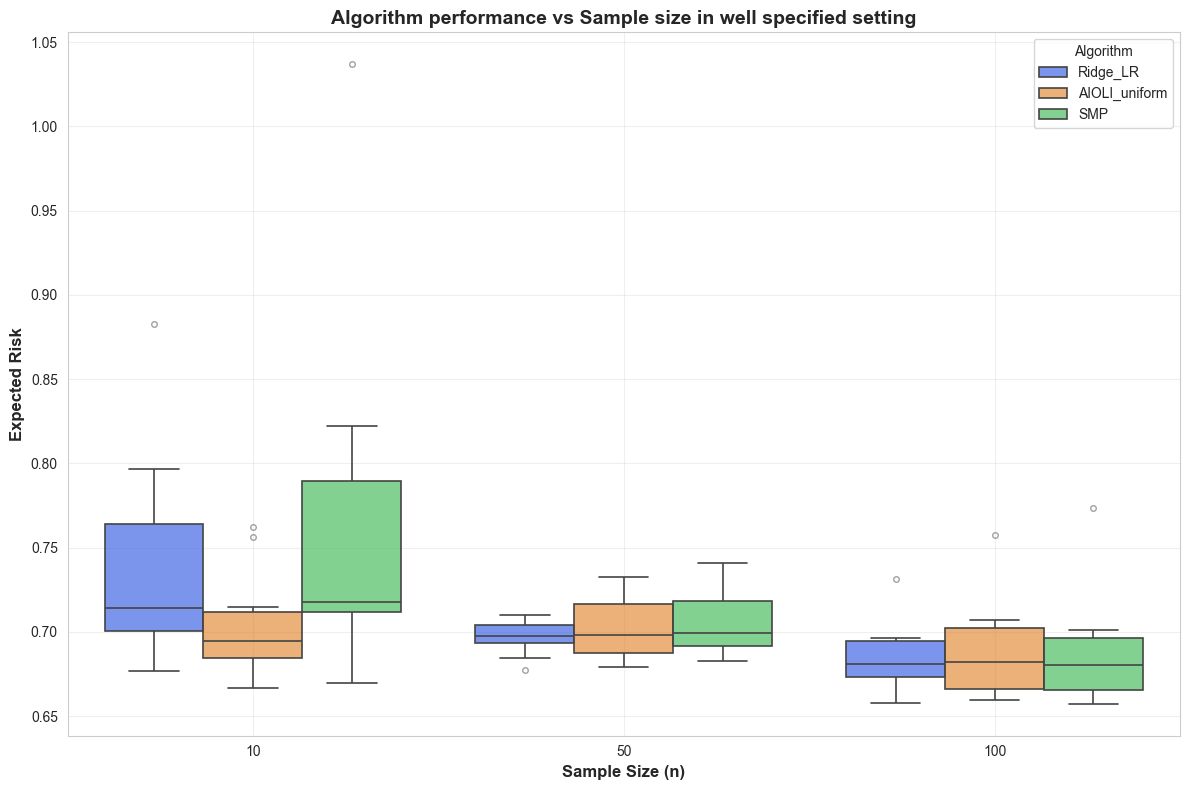

In [935]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR"] ,raw_data= well_specified_changing_n[1],  title= "Algorithm performance vs Sample size in well specified setting")

# Datasets

In [ ]:
# to push

In [289]:

# import kagglehub
# import os
#
# # Set cache to current directory
# os.environ['KAGGLEHUB_CACHE'] = os.getcwd()
#
# # Download latest version — returns the local path to the dataset folder
# path = kagglehub.dataset_download("ashrafkhan94/oil-spill")
# print("Dataset downloaded to:", path)
# print("Files:", os.listdir(path)[0])  # inspect actual filename(s)
# filename = os.listdir(path)[0]

Dataset downloaded to: C:\Users\marie\PycharmProjects\Thesis_Online-to-batch_Logistic-Regression\datasets\ashrafkhan94\oil-spill\versions\1
Files: oil-spill.csv


In [290]:
# csv_file = os.path.join(path, filename)  # adjust name based on os.listdir(path) output
# df = pd.read_csv(csv_file, header = None)

In [291]:
# df = df.drop(df.columns[0],axis=1) # Remove first column because its for analysis based on the image number and its not one of the predictive variables.

In [292]:
# df

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,12,92.42,364.42,135,97200.0,59.42,10.34,884.0,0.17,110.0,...,381.84,254.56,84.85,146.97,4.50,0,2593.50,65.85,6.39,0
933,11,98.82,248.64,159,89100.0,59.64,10.18,831.0,0.17,107.2,...,284.60,180.00,150.00,51.96,1.90,0,4361.25,65.70,6.53,0
934,14,25.14,428.86,24,113400.0,60.14,17.94,847.0,0.30,133.9,...,402.49,180.00,180.00,0.00,2.24,0,2153.05,65.91,6.12,0
935,10,96.00,451.30,68,81000.0,59.90,15.01,831.0,0.25,97.5,...,402.49,180.00,90.00,73.48,4.47,0,2421.43,65.97,6.32,0


In [293]:
# trialdata = generate_data("well specified")

500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499


In [294]:
# oil_x = df[df.columns[:-1]]

In [295]:
# oil_y = df[df.columns[-1]]
# oil_y.replace(0, -1, inplace=True)
# oil_y

0      1
1     -1
2      1
3      1
4     -1
      ..
932   -1
933   -1
934   -1
935   -1
936   -1
Name: 49, Length: 937, dtype: int64

In [296]:
# test_size = round(0.5*df.shape[0])
# oil_x_train = oil_x[test_size:]
# oil_y_train = oil_y[test_size:]
# oil_x_test = oil_x[:test_size]
# oil_y_test = oil_y[:test_size]

In [297]:
# def evaluate_on_data(data_x,data_y):
#
#     # Separate test and train
#     test_size = round(0.5*data_x.shape[0])
#     x_train = np.array(data_x[test_size:])
#     y_train = np.array(data_y[test_size:])
#     x_test = np.array(data_x[:test_size])
#     y_test = np.array(data_y[:test_size])
#
#     d = data_x.shape[1]
#
#     # Run algorithms
#     ## Get SMOTE dataset for unbalanced cases
#     sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
#     smote_x, smote_y = sm.apply_smote()
#
#     ogd = online_gd(data_y=y_train, data_x=x_train, B=default_B)
#     adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(5,d))
#     aioli_model = AIOLI()
#     ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=default_B/13)
#     classic_LR = classic_logistic_regression(data_x=x_train, data_y=y_train)
#     ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train)
#     lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train)
#     smp = sample_minmax_predictor(x_train, y_train)
#     ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
#     classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
#
#     # OTB estimates
#     # OGD
#     OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
#     OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
#     OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
#     # AdaGrad
#     adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
#     adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
#     adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
#
#     ############################## TEST RESULTS ##############################
#     # OGD
#     loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
#     loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
#     loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)
#
#     # Adagrad
#     loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
#     loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
#     loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)
#
#     # AIOLI
#     loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
#     loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
#     loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]
#
#     # Logistic Regression
#     loss_LR_test = log_loss(classic_LR["Batch_estimate"], x_test, y_test)
#     loss_LR_smote_test = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
#     loss_LR_Ridge_test = log_loss(ridge_LR["Batch_estimate"],   x_test, y_test)
#     loss_LR_Lasso_test = log_loss(lasso_LR["Batch_estimate"],   x_test, y_test)
#
#     # SMP
#     smp_result = smp.get_new_loss(x_test, y_test)
#     ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)
#
#     algorithms_test = {
#         "Classical_LR":  {"loss": loss_LR_test},
#         "Classical_LR_SMOTE":      {"loss": loss_LR_smote_test},
#         "Ridge_LR":      {"loss": loss_LR_Ridge_test},
#         "Lasso_LR":      {"loss": loss_LR_Lasso_test},
#         "OGD_uniform": {"loss": loss_OGD_uniform_test},
#         "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
#         "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
#         "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
#         "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
#         "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
#         "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
#         "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
#         "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
#         "SMP":      {"loss": smp_result["loss"]},
#         "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
#     }
#
#     test_set_results = []
#     for name, metrics in algorithms_test.items():
#          test_set_results.append({
#             "algorithm": name,
#             **metrics
#         })
#
#     return {
#             "test_results": pd.DataFrame(test_set_results)
#         }


In [298]:
# type(np.array(oil_x))

numpy.ndarray

In [299]:
# evaluate_on_data(oil_x,oil_y)

# Ignore from here on, it's simply code to test some functions/debugging

## AIOLI averaging outside sigmoid

In [ ]:
# class AIOLI:
#     def __init__(self):
#         self.first_sum  = []
#         self.etas_gradients = []
#         self.x0 = [] # Initializer for minimizing algorithm
#         self.reg_lambda = 0
#         self.train_size = 0
#         self.d = 0
#         self.n = 0
#
#     # Define function to minimize for AIOLI
#     @staticmethod # Because I dont use the self
#     def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
#         l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
#         # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
#         result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
#         return result
#
#     def new_point_loss(self,X,Y, OTB_method):
#         convergence_new = 0
#         beta_hat = np.zeros((self.train_size,self.d))
#         first_sum  = np.zeros(self.d)
#         etas_gradients = np.zeros((self.d,self.d))
#         for t in range(self.train_size):
#             # Minimize using data up until t-1
#             result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
#             beta_hat[t] = result.x
#             convergence_new += result.success
#             # Update minimization elements for next round
#             first_sum += self.first_sum[t]
#             etas_gradients += self.etas_gradients[t]
#
#         # Get OTB
#         big_beta = calculate_OTB(beta_hat, OTB_method)
#
#         # Suffer loss
#         loss_point = (1/self.n)*np.sum(np.logaddexp(0,-Y*np.inner(X,beta_hat)))
#
#         return loss_point
#
#     def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
#         start_time = datetime.datetime.now()
#         new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
#         end_time = datetime.datetime.now()
#         return{
#                 "runtime" : (end_time - start_time).total_seconds(),
#                 "loss" : sum(new_losses)
#             }
#
#
#     def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
#         """AIOLI
#         This is the function to run AIOLI.
#
#         Parameters
#         ---------
#         data_y : ndarray
#             Vector with outcome(y) values. Dimensions: n x 1
#         data_x: ndarray
#             Array with independent variables. Dimensions: n x d
#         B: float
#             Radius of the L2 ball constraint for the parameter vector beta
#         X: float
#             Radius of the L2 ball constraint for the feature vector x"""
#         # Record start time
#         start_time = datetime.datetime.now()
#
#         # Get data dimensions
#         self.n = data_x.shape[0]
#         n = self.n
#         self.d = data_x.shape[1]
#         d = self.d
#         self.x0 = np.zeros(d) # Initializer for minimizing algorithm
#         self.train_size = n
#         # Initialize vectors for storage
#         betas = np.zeros((n, d))
#         ys = np.zeros(n)
#         y_hats = np.zeros(n)
#         loss = np.zeros(n)
#         etas = np.zeros(n)
#         gradients = np.zeros((n, d))
#         self.reg_lambda = 1 / (B**2)
#
#         # Keep sums for loss functions
#         self.first_sum  = np.zeros((n, d))
#         self.etas_gradients = np.zeros((n,d,d))
#         first_sum  = np.zeros(d)
#         etas_gradients = np.zeros((d,d))
#
#         # Track convergence
#         convergence = 0
#         minimizer_gradient = 0
#
#         # Run Algorithm
#         for t in range(n):
#             # Get context vector
#             xt = data_x[t]
#
#             # Update beta parameter
#             # noinspection PyTypeChecker # This is to avoid the underlining which
#             if t == 0: # Initialize to 0 for first round
#                 betas[t] = np.zeros(d)
#             else:
#                 result = minimize(self.parameter_function_AIOLI,
#                                   np.zeros(d),
#                                   method = minimize_method,
#                                   args=(xt, self.reg_lambda,first_sum, etas_gradients),
#                                   options = {"maxiter":100000}
#                                   )
#                 betas[t] = result.x
#                 convergence += result.success
#                 minimizer_gradient += np.linalg.norm(result.jac)
#
#             # # Project beta onto set
#             # betas[t] = project_onto_l2_ball(beta_tilde,B)
#             # betas[t] = self.x0
#
#             # Generate prediction
#             y_hats[t] = np.inner(xt,betas[t])
#
#             # Observe true y from data
#             ys[t] = data_y[t]
#
#              # Compute gradient
#             gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))
#
#             # Estimate eta
#             etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)
#
#             # Suffer loss
#             loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))
#
#             # Compute elements for AIOLI loss function
#
#             fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
#             eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
#             self.first_sum[t] = fs
#             self.etas_gradients[t] = eg
#             first_sum += fs
#             etas_gradients += eg
#             # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
#
#             # Dynamic Hyperparameter tuning
#             if dynamic_B:
#                 B = max(B, np.linalg.norm(betas[t]))
#
#         # for loop ends
#
#         # Get Batch estimate
#         betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)
#
#         # Get Batch estimate loss
#         loss_OTB = log_loss(betas_OTB,data_x, data_y)
#
#         end_time = datetime.datetime.now()
#
#         return{
#             "runtime" : (end_time - start_time).total_seconds(),
#             "Total_Loss" : loss_OTB,
#             "Online_Loss" : sum(loss),
#             "Batch_estimate": betas_OTB,
#             "All_Betas": betas,
#             "convergence" : convergence,
#             "minimizer_gradient" : minimizer_gradient
#         }
#


## Tests

In [300]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [301]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [302]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [303]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [304]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [305]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [306]:
# np.log(1000)

## OTB conversion proof tests

In [307]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))